# Обработка данных и построение моделей

## Обработка данных

### Добавление цены

In [1]:
import pandas as pd

df_raw = pd.read_csv('/kaggle/input/datasets/paveleshmeev/buildings-info/resale_char_urban_macro_policy_full.csv')

df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/paveleshmeev/buildings-info/resale_char_urban_macro_policy_full.csv'

In [7]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

resale_dir = Path('/kaggle/input/datasets/paveleshmeev/sgp-resale-prices-90')
geo_path = Path('/kaggle/input/datasets/paveleshmeev/buildings-info/property_onemap_coordinates.csv')

resale_files = [
    resale_dir / 'resale_price_90_99.csv',
    resale_dir / 'resale_price_00_feb_12.csv',
    resale_dir / 'resale_price_mar_12_14.csv',
    resale_dir / 'resale_price_15_16.csv',
    resale_dir / 'resale_price_17.csv'
]

def clean_colname(col):
    col = str(col).strip().lower()
    col = col.replace(' ', '_').replace('-', '_').replace('/', '_')
    col = re.sub(r'__+', '_', col)
    return col

def normalize_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).upper().strip()
    x = re.sub(r'[,./#()\-]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x if x else pd.NA

def build_address_query(block, street_name):
    block = normalize_text(block)
    street_name = normalize_text(street_name)
    if pd.isna(block) or pd.isna(street_name):
        return pd.NA
    return f'{block} {street_name}'

def pick_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

resale_parts = []

for file_path in resale_files:
    df = pd.read_csv(file_path)
    df.columns = [clean_colname(c) for c in df.columns]

    required_cols = {'month', 'block', 'street_name'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'{file_path.name}: missing columns {missing_cols}')

    df['source_file'] = file_path.name
    resale_parts.append(df)

resale_raw = pd.concat(resale_parts, ignore_index=True, sort=False)

resale_raw['month'] = resale_raw['month'].astype(str).str.strip()
resale_raw['transaction_date'] = pd.to_datetime(
    resale_raw['month'] + '-01',
    format='%Y-%m-%d',
    errors='coerce'
)

resale_raw['block'] = resale_raw['block'].map(normalize_text)
resale_raw['street_name'] = resale_raw['street_name'].map(normalize_text)
resale_raw['address_query'] = [
    build_address_query(block, street_name)
    for block, street_name in zip(resale_raw['block'], resale_raw['street_name'])
]
resale_raw['address_key'] = resale_raw['address_query'].map(normalize_text)

resale_raw.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,source_file,remaining_lease,transaction_date,address_query,address_key
0,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1
1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1
2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1
3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1
4,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,resale_price_90_99.csv,NaN,1990-01-01,216 ANG MO KIO AVE 1,216 ANG MO KIO AVE 1


In [8]:
geo_df = pd.read_csv(geo_path)
geo_df.columns = [clean_colname(c) for c in geo_df.columns]

if 'address_query' not in geo_df.columns:
    raise ValueError('property_onemap_coordinates.csv must contain address_query')

geo_df['address_key'] = geo_df['address_query'].map(normalize_text)

lat_col = pick_existing_col(geo_df, ['onemap_latitude', 'latitude', 'lat'])
lon_col = pick_existing_col(geo_df, ['onemap_longitude', 'longitude', 'lon', 'lng'])
x_col = pick_existing_col(geo_df, ['onemap_x', 'x'])
y_col = pick_existing_col(geo_df, ['onemap_y', 'y'])

if lat_col is None or lon_col is None:
    raise ValueError('Could not find latitude/longitude columns in property_onemap_coordinates.csv')

geo_keep_cols = ['address_key', lat_col, lon_col]
if x_col is not None:
    geo_keep_cols.append(x_col)
if y_col is not None:
    geo_keep_cols.append(y_col)

geo_base = geo_df[geo_keep_cols].copy()

for col in geo_keep_cols[1:]:
    geo_base[col] = pd.to_numeric(geo_base[col], errors='coerce')

geo_base = (
    geo_base
    .sort_values(by=[lat_col, lon_col], na_position='last')
    .drop_duplicates(subset='address_key', keep='first')
    .rename(columns={
        lat_col: 'latitude',
        lon_col: 'longitude',
        x_col: 'x' if x_col is not None else None,
        y_col: 'y' if y_col is not None else None
    })
)

geo_base.columns = [c for c in geo_base.columns]

geo_base.head()

,address_key,latitude,longitude,x,y
7156,43 TELOK BLANGAH RISE,1.270380,103.823236,26877.883338,28097.635137
6966,42 TELOK BLANGAH RISE,1.270919,103.822685,26816.607833,28157.256981
7349,44 TELOK BLANGAH DR,1.271409,103.810888,25503.596925,28211.460856
106,101 BT PURMEI RD,1.271463,103.825684,27150.279785,28217.392685
6739,41 TELOK BLANGAH RISE,1.271472,103.822992,26850.743701,28218.431512


In [9]:
resale_base_v0 = resale_raw.merge(
    geo_base,
    on='address_key',
    how='left'
)

resale_base_v0.insert(0, 'resale_id', np.arange(1, len(resale_base_v0) + 1))

In [15]:
resale_base_v0.head()

,resale_id,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,source_file,remaining_lease,transaction_date,address_query,address_key,latitude,longitude,x,y
0,1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,NaN,NaN,NaN,NaN
1,2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,NaN,NaN,NaN,NaN
2,3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,NaN,NaN,NaN,NaN
3,4,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,resale_price_90_99.csv,NaN,1990-01-01,309 ANG MO KIO AVE 1,309 ANG MO KIO AVE 1,NaN,NaN,NaN,NaN
4,5,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,resale_price_90_99.csv,NaN,1990-01-01,216 ANG MO KIO AVE 1,216 ANG MO KIO AVE 1,1.366197,103.841505,28911.05224,38692.616791


In [51]:
resale_base_v0.shape

(974836, 20)

In [16]:
df_raw_prices = df_raw.merge(
    resale_base_v0[['resale_id', 'storey_range', 'resale_price']],
    on='resale_id',
    how='left',
    validate='1:1'
)

df_raw_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 89 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   resale_id                            964340 non-null  int64  
 1   transaction_date                     964340 non-null  object 
 2   month_x                              964340 non-null  object 
 3   address_query                        964340 non-null  object 
 4   latitude                             964340 non-null  float64
 5   longitude                            964340 non-null  float64
 6   x                                    964340 non-null  float64
 7   y                                    964340 non-null  float64
 8   address_key                          964340 non-null  object 
 9   max_floor_lvl                        958710 non-null  float64
 10  year_completed                       958710 non-null  float64
 11  residential  

In [17]:
missing_price = int(df_raw_prices['resale_price'].isna().sum())
matched_price = int(df_raw_prices['resale_price'].notna().sum())

print(f'Rows in final_df: {len(df_raw_prices):,}')
print(f'Rows matched with resale_price: {matched_price:,}')
print(f'Rows with missing resale_price after merge: {missing_price:,}')

Rows in final_df: 964,340
Rows matched with resale_price: 964,340
Rows with missing resale_price after merge: 0


In [18]:
df_raw_prices[df_raw_prices['resale_id'] == 1]

,resale_id,transaction_date,month_x,address_query,latitude,longitude,x,y,address_key,max_floor_lvl,...,resident_population,resident_unemployment_rate,ulc_index_sa,per_capita_gdp_real,resident_households_hdb,household_net_worth,steel_rebar_price,term_spread_10y_2y,storey_range,resale_price
0,1,1990-01-01,1990-01-01,309 ANG MO KIO AVE 1,1.377017,103.834733,28157.453087,39889.005702,309 ANG MO KIO AVE 1,NaN,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,10 TO 12,9000.0


In [19]:
df_raw_prices[df_raw_prices['resale_id'] == 2]

,resale_id,transaction_date,month_x,address_query,latitude,longitude,x,y,address_key,max_floor_lvl,...,resident_population,resident_unemployment_rate,ulc_index_sa,per_capita_gdp_real,resident_households_hdb,household_net_worth,steel_rebar_price,term_spread_10y_2y,storey_range,resale_price
956,2,1990-01-01,1990-01-01,309 ANG MO KIO AVE 1,1.377017,103.834733,28157.453087,39889.005702,309 ANG MO KIO AVE 1,NaN,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,04 TO 06,6000.0


In [20]:
df_raw_prices[df_raw_prices['resale_id'] == 3]

,resale_id,transaction_date,month_x,address_query,latitude,longitude,x,y,address_key,max_floor_lvl,...,resident_population,resident_unemployment_rate,ulc_index_sa,per_capita_gdp_real,resident_households_hdb,household_net_worth,steel_rebar_price,term_spread_10y_2y,storey_range,resale_price
955,3,1990-01-01,1990-01-01,309 ANG MO KIO AVE 1,1.377017,103.834733,28157.453087,39889.005702,309 ANG MO KIO AVE 1,NaN,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,10 TO 12,8000.0


In [21]:
import numpy as np
import pandas as pd

storey_bounds = df_raw_prices['storey_range'].astype(str).str.extract(
    r'^\s*(\d+)\s*TO\s*(\d+)\s*$'
)

storey_bounds.columns = ['storey_low', 'storey_high']
storey_bounds = storey_bounds.apply(pd.to_numeric, errors='coerce')

storey_mean = (storey_bounds['storey_low'] + storey_bounds['storey_high']) / 2

df_raw_prices['floor_mean'] = np.floor(storey_mean + 0.5).astype('Int64')

df_raw_prices[['storey_range', 'floor_mean']].head(10)

,storey_range,floor_mean
0,10 TO 12,11
1,13 TO 15,14
2,04 TO 06,5
3,13 TO 15,14
4,01 TO 03,2
5,10 TO 12,11
6,07 TO 09,8
7,01 TO 03,2
8,07 TO 09,8
9,22 TO 24,23


In [24]:
out_path = Path('/kaggle/working/resale_char_urban_macro_policy_price_full.csv')

df_raw_prices.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /kaggle/working/resale_char_urban_macro_policy_price_full.csv


In [22]:
df_raw_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 90 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   resale_id                            964340 non-null  int64  
 1   transaction_date                     964340 non-null  object 
 2   month_x                              964340 non-null  object 
 3   address_query                        964340 non-null  object 
 4   latitude                             964340 non-null  float64
 5   longitude                            964340 non-null  float64
 6   x                                    964340 non-null  float64
 7   y                                    964340 non-null  float64
 8   address_key                          964340 non-null  object 
 9   max_floor_lvl                        958710 non-null  float64
 10  year_completed                       958710 non-null  float64
 11  residential  

### Работа с переменными

#### Назначение нужного типа данных

In [26]:
date_cols = ['transaction_date', 'month_date']

for col in date_cols:
    df_raw_prices[col] = pd.to_datetime(df_raw_prices[col], errors='coerce')

df_raw_prices[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_date  964340 non-null  datetime64[ns]
 1   month_date        964340 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 14.7 MB


In [28]:
sum(df_raw_prices['transaction_date'] == df_raw_prices['month_date']) == df_raw_prices.shape[0]

True

#### Удаление переменных, с помощью которых строились merge-ы

In [53]:
import pandas as pd

df_wo_merging_feats = df_raw_prices.copy()

drop_cols = [
    'address_query',
    'address_key',
    'month_x',
    'month_y',
    'month',
    'month_date',
    'storey_range',
    'latitude',
    'longitude'
]

drop_cols = [col for col in drop_cols if col in df_wo_merging_feats.columns]

df_wo_merging_feats = df_wo_merging_feats.drop(columns=drop_cols)

In [54]:
df_wo_merging_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            964340 non-null  int64         
 1   transaction_date                     964340 non-null  datetime64[ns]
 2   x                                    964340 non-null  float64       
 3   y                                    964340 non-null  float64       
 4   max_floor_lvl                        958710 non-null  float64       
 5   year_completed                       958710 non-null  float64       
 6   residential                          958710 non-null  object        
 7   commercial                           958710 non-null  object        
 8   market_hawker                        958710 non-null  object        
 9   miscellaneous                        958710 non-null  object        
 

#### Работа с переменными из [HDB Property Information](https://data.gov.sg/datasets?topics=housing&resultId=d_17f5382f26140b1fdae0ba2ef6239d2f)

In [55]:
# Перевод в численные значения бинарных переменных

binary_cols = [
    'residential',
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

for col in binary_cols:
    df_wo_merging_feats[col] = (
        df_wo_merging_feats[col]
        .astype('string')
        .str.strip()
        .str.upper()
        .map({'Y': 1, 'N': 0})
        .astype('Int8')
    )

df_wo_merging_feats[binary_cols].info()
df_wo_merging_feats[binary_cols].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   residential          958710 non-null  Int8 
 1   commercial           958710 non-null  Int8 
 2   market_hawker        958710 non-null  Int8 
 3   miscellaneous        958710 non-null  Int8 
 4   multistorey_carpark  958710 non-null  Int8 
 5   precinct_pavilion    958710 non-null  Int8 
dtypes: Int8(6)
memory usage: 11.0 MB


,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion
0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,1,0,0,1,0,0
2,1,1,0,0,0,0
3,1,0,0,0,0,0
4,1,0,0,0,0,0


In [56]:
df_wo_merging_prop_feats = df_wo_merging_feats.copy()

In [57]:
# Удаление колонок _sold и _rental, так как нет прямой связи с транзакциями по времени

sold_rental_cols = [
    col for col in df_wo_merging_prop_feats.columns
    if col.endswith('_sold') or col.endswith('_rental')
]

print('Будут удалены колонки:')
print(sold_rental_cols)
print(f'Всего: {len(sold_rental_cols)}')

df_wo_merging_prop_feats = df_wo_merging_prop_feats.drop(columns=sold_rental_cols)

df_wo_merging_prop_feats.info()

Будут удалены колонки:
['1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental']
Всего: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964340 entries, 0 to 964339
Data columns (total 69 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            964340 non-null  int64         
 1   transaction_date                     964340 non-null  datetime64[ns]
 2   x                                    964340 non-null  float64       
 3   y                                    964340 non-null  float64       
 4   max_floor_lvl                        958710 non-null  float64       
 5   year_completed                       958710 non-null  float64       
 6   residential                          958710 non-null  Int8      

In [37]:
df_wo_merging_prop_feats[df_wo_merging_prop_feats['total_dwelling_units'] == 0]

,resale_id,x,y,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,...,resident_population,resident_unemployment_rate,ulc_index_sa,per_capita_gdp_real,resident_households_hdb,household_net_worth,steel_rebar_price,term_spread_10y_2y,resale_price,floor_mean
289,925,14389.346097,36845.190034,1.0,2017.0,0,0,0,0,0,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,51000.0,17
290,926,14389.346097,36845.190034,1.0,2017.0,0,0,0,0,0,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,45000.0,8
1095,631,35236.250533,33272.732559,6.0,2009.0,0,0,0,1,1,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,19000.0,2
1096,632,35236.250533,33272.732559,6.0,2009.0,0,0,0,1,1,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,14000.0,8
1097,633,35236.250533,33272.732559,6.0,2009.0,0,0,0,1,1,...,2735868.0,NaN,73.1,31996.0,562400.0,NaN,NaN,NaN,18900.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496674,505774,26666.336646,29995.521498,5.0,2018.0,0,0,0,0,1,...,3525894.0,3.6,86.2,60711.0,875700.0,771774.7,742.00,0.16,185000.0,11
496691,505775,26666.336646,29995.521498,5.0,2018.0,0,0,0,0,1,...,3525894.0,3.6,86.2,60711.0,875700.0,771774.7,742.00,0.16,165000.0,2
503036,512220,26666.336646,29995.521498,5.0,2018.0,0,0,0,0,1,...,3583082.0,3.4,88.1,63488.0,894100.0,803127.4,752.49,0.17,175000.0,11
505109,514397,26666.336646,29995.521498,5.0,2018.0,0,0,0,0,1,...,3583082.0,3.4,88.1,63488.0,894100.0,803127.4,767.29,0.17,170000.0,2


In [75]:
# Убираем нежилые здания с total_dwelling_units == 0

df_residential_wo_merging_prop_feats = df_wo_merging_prop_feats.copy()

rows_before = len(df_residential_wo_merging_prop_feats)

df_residential_wo_merging_prop_feats = df_residential_wo_merging_prop_feats[
    df_residential_wo_merging_prop_feats['total_dwelling_units'].ne(0)
].copy()

rows_after = len(df_residential_wo_merging_prop_feats)
rows_removed = rows_before - rows_after

print(f'Rows before: {rows_before:,}')
print(f'Rows after: {rows_after:,}')
print(f'Rows removed (total_dwelling_units == 0): {rows_removed:,}')

df_residential_wo_merging_prop_feats['total_dwelling_units'].describe()

Rows before: 964,340
Rows after: 963,022
Rows removed (total_dwelling_units == 0): 1,318


count    957392.000000
mean        125.254408
std          59.444303
min           2.000000
25%          90.000000
50%         112.000000
75%         144.000000
max         584.000000
Name: total_dwelling_units, dtype: float64

In [76]:
df_residential_wo_merging_prop_feats[df_residential_wo_merging_prop_feats['residential'] == 0]

,resale_id,transaction_date,x,y,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,...,resident_population,resident_unemployment_rate,ulc_index_sa,per_capita_gdp_real,resident_households_hdb,household_net_worth,steel_rebar_price,term_spread_10y_2y,resale_price,floor_mean


In [77]:
# Убираем уже константный residential

df_residential_wo_merging_prop_feats = df_residential_wo_merging_prop_feats.drop(columns=['residential'])

In [49]:
# Проверка на удаление оставшихся видов помещений

check_flags = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

print('1) Value counts for flags')
for col in check_flags:
    print(f'--- {col} ---')
    print(df_residential_wo_merging_prop_feats[col].value_counts(dropna=False))
    print()

print('2) Summary by each flag')
for col in check_flags:
    print(f'=== {col} ===')
    print(
        df_residential_wo_merging_prop_feats.groupby(col, dropna=False).agg(
            n_rows=('resale_price', 'size'),
            n_price_nonnull=('resale_price', lambda s: s.notna().sum()),
            n_tdw_nonnull=('total_dwelling_units', lambda s: s.notna().sum()),
            n_tdw_zero=('total_dwelling_units', lambda s: (s == 0).sum()),
            n_tdw_gt0=('total_dwelling_units', lambda s: (s > 0).sum()),
            mean_tdw=('total_dwelling_units', 'mean'),
            median_tdw=('total_dwelling_units', 'median'),
            mean_price=('resale_price', 'mean'),
            median_price=('resale_price', 'median')
        )
    )
    print()

print('3) Crosstab between flags')
for col1 in check_flags:
    for col2 in check_flags:
        if col1 < col2:
            print(f'=== {col1} x {col2} ===')
            print(pd.crosstab(
                df_residential_wo_merging_prop_feats[col1],
                df_residential_wo_merging_prop_feats[col2],
                dropna=False
            ))
            print()

print('4) Sample rows where at least one flag == 1')
mask_any = df_residential_wo_merging_prop_feats[check_flags].fillna(0).eq(1).any(axis=1)

sample_cols = [
    'resale_id',
    'residential',
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',
    'total_dwelling_units',
    'resale_price',
    'max_floor_lvl',
    'year_completed',
    'bldg_contract_town',
    'x',
    'y'
]

print('Rows with any flag == 1:', int(mask_any.sum()))
display(df_residential_wo_merging_prop_feats.loc[mask_any, sample_cols].head(40))

print('5) Sample rows where commercial == 1 or market_hawker == 1')
mask_comm = (
    df_residential_wo_merging_prop_feats['commercial'].fillna(0).eq(1) |
    df_residential_wo_merging_prop_feats['market_hawker'].fillna(0).eq(1)
)
print('Rows with commercial==1 or market_hawker==1:', int(mask_comm.sum()))
display(df_residential_wo_merging_prop_feats.loc[mask_comm, sample_cols].head(40))

1) Value counts for flags
--- commercial ---
commercial
0       754212
1       203180
<NA>      5630
Name: count, dtype: Int64

--- market_hawker ---
market_hawker
0       957276
<NA>      5630
1          116
Name: count, dtype: Int64

--- miscellaneous ---
miscellaneous
0       650544
1       306848
<NA>      5630
Name: count, dtype: Int64

--- multistorey_carpark ---
multistorey_carpark
0       957199
<NA>      5630
1          193
Name: count, dtype: Int64

--- precinct_pavilion ---
precinct_pavilion
0       956805
<NA>      5630
1          587
Name: count, dtype: Int64

2) Summary by each flag
=== commercial ===
            n_rows  n_price_nonnull  n_tdw_nonnull  n_tdw_zero  n_tdw_gt0  \
commercial                                                                  
0           754212           754212         754212           0     754212   
1           203180           203180         203180           0     203180   
<NA>          5630             5630              0           0       

,resale_id,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,total_dwelling_units,resale_price,max_floor_lvl,year_completed,bldg_contract_town,x,y
1,1000,1,0,0,1,0,0,285.0,44500.0,13.0,1973.0,KWN,31900.318130,33550.764905
2,1018,1,1,0,0,0,0,76.0,75100.0,20.0,1973.0,KWN,30639.384530,33979.709906
6,1015,1,1,0,0,0,0,76.0,74900.0,20.0,1972.0,KWN,29914.123868,33468.508511
9,1020,1,1,0,0,0,0,96.0,81000.0,25.0,1973.0,KWN,30280.932119,33630.541019
12,1009,1,0,0,1,0,0,131.0,77000.0,12.0,1964.0,KWN,33665.812361,31391.170236
13,1008,1,1,0,0,0,0,88.0,58000.0,8.0,1978.0,KWN,29945.332550,33047.045513
14,1007,1,0,0,1,0,0,142.0,52000.0,13.0,1978.0,KWN,29874.149184,32805.746725
17,1004,1,1,0,0,0,0,273.0,42000.0,16.0,1974.0,KWN,32266.092699,33079.310669
18,1003,1,1,0,0,0,0,387.0,45700.0,18.0,1974.0,KWN,32064.848897,33800.487756
19,1011,1,1,0,0,0,0,228.0,31400.0,12.0,1970.0,KWN,31706.462198,33834.349821


5) Sample rows where commercial == 1 or market_hawker == 1
Rows with commercial==1 or market_hawker==1: 203180


,resale_id,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,total_dwelling_units,resale_price,max_floor_lvl,year_completed,bldg_contract_town,x,y
2,1018,1,1,0,0,0,0,76.0,75100.0,20.0,1973.0,KWN,30639.384530,33979.709906
6,1015,1,1,0,0,0,0,76.0,74900.0,20.0,1972.0,KWN,29914.123868,33468.508511
9,1020,1,1,0,0,0,0,96.0,81000.0,25.0,1973.0,KWN,30280.932119,33630.541019
13,1008,1,1,0,0,0,0,88.0,58000.0,8.0,1978.0,KWN,29945.332550,33047.045513
17,1004,1,1,0,0,0,0,273.0,42000.0,16.0,1974.0,KWN,32266.092699,33079.310669
18,1003,1,1,0,0,0,0,387.0,45700.0,18.0,1974.0,KWN,32064.848897,33800.487756
19,1011,1,1,0,0,0,0,228.0,31400.0,12.0,1970.0,KWN,31706.462198,33834.349821
20,1002,1,1,0,0,0,0,387.0,45000.0,18.0,1974.0,KWN,32064.848897,33800.487756
21,1021,1,1,0,0,0,0,96.0,75000.0,25.0,1973.0,KWN,30280.932119,33630.541019
24,996,1,1,0,0,0,0,281.0,45000.0,16.0,1973.0,KWN,32184.013343,32947.461274


#### Работа с переменными из [Resale Flat Prices](https://data.gov.sg/datasets?topics=housing&resultId=189)

In [78]:
# Добавление оставшейся информации из Resale Flat Prices

import numpy as np
import pandas as pd

df_residential_wo_merging_prop_feats_upd = df_residential_wo_merging_prop_feats.copy()

cols_from_resale_base = [
    'resale_id',
    'town',
    'flat_type',
    'floor_area_sqm',
    'flat_model',
    'lease_commence_date'
]

missing_cols = [col for col in cols_from_resale_base if col not in resale_base_v0.columns]
if missing_cols:
    raise ValueError(f'Missing columns in resale_base_v0: {missing_cols}')

if 'transaction_date' not in df_residential_wo_merging_prop_feats_upd.columns:
    raise ValueError('Column transaction_date is missing in df_residential_wo_merging_prop_feats')

if not pd.api.types.is_datetime64_any_dtype(df_residential_wo_merging_prop_feats_upd['transaction_date']):
    df_residential_wo_merging_prop_feats_upd['transaction_date'] = pd.to_datetime(df_residential_wo_merging_prop_feats_upd['transaction_date'], errors='coerce')

resale_info = resale_base_v0[cols_from_resale_base].copy()

resale_info['lease_commence_date'] = pd.to_numeric(
    resale_info['lease_commence_date'],
    errors='coerce'
).astype('Int64')

resale_info['floor_area_sqm'] = pd.to_numeric(
    resale_info['floor_area_sqm'],
    errors='coerce'
)

if resale_info['resale_id'].duplicated().any():
    dup_cnt = int(resale_info['resale_id'].duplicated().sum())
    raise ValueError(f'resale_base_v0 has duplicated resale_id values: {dup_cnt}')

if df_residential_wo_merging_prop_feats_upd['resale_id'].duplicated().any():
    dup_cnt = int(df_residential_wo_merging_prop_feats_upd['resale_id'].duplicated().sum())
    raise ValueError(f'df_residential_wo_merging_prop_feats has duplicated resale_id values: {dup_cnt}')

cols_to_replace_if_exist = [
    'town',
    'flat_type',
    'floor_area_sqm',
    'flat_model',
    'lease_commence_date',
    'remaining_lease_full_years'
]

existing_cols = [col for col in cols_to_replace_if_exist if col in df_residential_wo_merging_prop_feats_upd.columns]
if existing_cols:
    df_residential_wo_merging_prop_feats_upd = df_residential_wo_merging_prop_feats_upd.drop(columns=existing_cols)

df_residential_wo_merging_prop_feats_upd = df_residential_wo_merging_prop_feats_upd.merge(
    resale_info,
    on='resale_id',
    how='left',
    validate='1:1'
)

sale_year = df_residential_wo_merging_prop_feats_upd['transaction_date'].dt.year.astype('Int64')
lease_start_year = df_residential_wo_merging_prop_feats_upd['lease_commence_date']

remaining_full_years = lease_start_year + 98 - sale_year

df_residential_wo_merging_prop_feats_upd['remaining_lease_full_years'] = (
    remaining_full_years
    .where(remaining_full_years.isna() | (remaining_full_years >= 0), 0)
    .astype('Int64')
)

print(
    df_residential_wo_merging_prop_feats_upd[
        [
            'resale_id',
            'town',
            'flat_type',
            'floor_area_sqm',
            'flat_model',
            'lease_commence_date',
            'transaction_date',
            'remaining_lease_full_years'
        ]
    ].head(10)
)

print()
print('Missing town:', int(df_residential_wo_merging_prop_feats_upd['town'].isna().sum()))
print('Missing flat_type:', int(df_residential_wo_merging_prop_feats_upd['flat_type'].isna().sum()))
print('Missing floor_area_sqm:', int(df_residential_wo_merging_prop_feats_upd['floor_area_sqm'].isna().sum()))
print('Missing flat_model:', int(df_residential_wo_merging_prop_feats_upd['flat_model'].isna().sum()))
print('Missing lease_commence_date:', int(df_residential_wo_merging_prop_feats_upd['lease_commence_date'].isna().sum()))
print('Missing remaining_lease_full_years:', int(df_residential_wo_merging_prop_feats_upd['remaining_lease_full_years'].isna().sum()))

   resale_id             town flat_type  floor_area_sqm flat_model  \
0          1       ANG MO KIO    1 ROOM            31.0   IMPROVED   
1       1000  KALLANG/WHAMPOA    3 ROOM            65.0   IMPROVED   
2       1018  KALLANG/WHAMPOA    4 ROOM            91.0   IMPROVED   
3        998  KALLANG/WHAMPOA    3 ROOM            65.0   IMPROVED   
4       1017  KALLANG/WHAMPOA    4 ROOM            91.0   IMPROVED   
5       1016  KALLANG/WHAMPOA    4 ROOM            91.0   IMPROVED   
6       1015  KALLANG/WHAMPOA    4 ROOM            84.0   IMPROVED   
7       1014  KALLANG/WHAMPOA    3 ROOM            83.0    TERRACE   
8       1013  KALLANG/WHAMPOA    3 ROOM            56.0   STANDARD   
9       1020  KALLANG/WHAMPOA    4 ROOM            91.0   IMPROVED   

   lease_commence_date transaction_date  remaining_lease_full_years  
0                 1977       1990-01-01                          85  
1                 1981       1990-01-01                          89  
2                 1

In [79]:
df_residential_wo_merging_prop_feats_upd['flat_type'].unique()

array(['1 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', '2 ROOM',
       'MULTI GENERATION', 'MULTI-GENERATION'], dtype=object)

In [93]:
# Заменяем MULTI GENERATION на MULTI-GENERATION

df_residential_wo_merging_prop_feats_upd['flat_type'] = (
    df_residential_wo_merging_prop_feats_upd['flat_type']
    .astype('string')
    .str.strip()
    .replace({'MULTI GENERATION': 'MULTI-GENERATION'})
)

df_residential_wo_merging_prop_feats_upd['flat_type'].value_counts(dropna=False)

flat_type
4 ROOM              371903
3 ROOM              298352
5 ROOM              206423
EXECUTIVE            72557
2 ROOM               12371
1 ROOM                 866
MULTI-GENERATION       550
Name: count, dtype: Int64

In [94]:
df_residential_wo_merging_prop_feats_upd[ \
    df_residential_wo_merging_prop_feats_upd['flat_type'] == 'MULTI GENERATION'
]

,resale_id,transaction_date,x,y,max_floor_lvl,year_completed,commercial,market_hawker,miscellaneous,multistorey_carpark,...,term_spread_10y_2y,resale_price,floor_mean,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,remaining_lease_full_years,log_resale_price


In [3]:
import re

df_residential_wo_merging_prop_feats_upd['flat_model'] = (
    df_residential_wo_merging_prop_feats_upd['flat_model']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'\s*-\s*', '-', regex=True)
    .str.upper()
)

df_residential_wo_merging_prop_feats_upd['flat_model'].value_counts(dropna=False)

flat_model
MODEL A                   284069
IMPROVED                  247527
NEW GENERATION            190767
SIMPLIFIED                 59342
PREMIUM APARTMENT          51500
STANDARD                   41172
APARTMENT                  36941
MAISONETTE                 30790
MODEL A2                   10650
DBSS                        3933
MODEL A-MAISONETTE          2150
ADJOINED FLAT               1288
TERRACE                      712
MULTI GENERATION             550
TYPE S1                      507
2-ROOM                       447
TYPE S2                      244
PREMIUM APARTMENT LOFT       136
IMPROVED-MAISONETTE          131
PREMIUM MAISONETTE            92
3GEN                          74
Name: count, dtype: Int64

In [81]:
df_residential_wo_merging_prop_feats_upd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963022 entries, 0 to 963021
Data columns (total 74 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            963022 non-null  int64         
 1   transaction_date                     963022 non-null  datetime64[ns]
 2   x                                    963022 non-null  float64       
 3   y                                    963022 non-null  float64       
 4   max_floor_lvl                        957392 non-null  float64       
 5   year_completed                       957392 non-null  float64       
 6   commercial                           957392 non-null  Int8          
 7   market_hawker                        957392 non-null  Int8          
 8   miscellaneous                        957392 non-null  Int8          
 9   multistorey_carpark                  957392 non-null  Int8          
 

In [102]:
out_path = Path('/kaggle/working/df_full_feats_prep_v2.csv')

df_residential_wo_merging_prop_feats_upd.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /kaggle/working/df_full_feats_prep_v2.csv


### Работа с выбросами

In [83]:
if (df_residential_wo_merging_prop_feats_upd['resale_price'] <= 0).any():
    raise ValueError('В колонке resale_price есть значения <= 0. Для np.log нужны только положительные значения.')

df_residential_wo_merging_prop_feats_upd['log_resale_price'] = np.log(df_residential_wo_merging_prop_feats_upd['resale_price'])

df_residential_wo_merging_prop_feats_upd[['resale_price', 'log_resale_price']].head()

,resale_price,log_resale_price
0,9000.0,9.104980
1,44500.0,10.703244
2,75100.0,11.226576
3,42000.0,10.645425
4,90000.0,11.407565


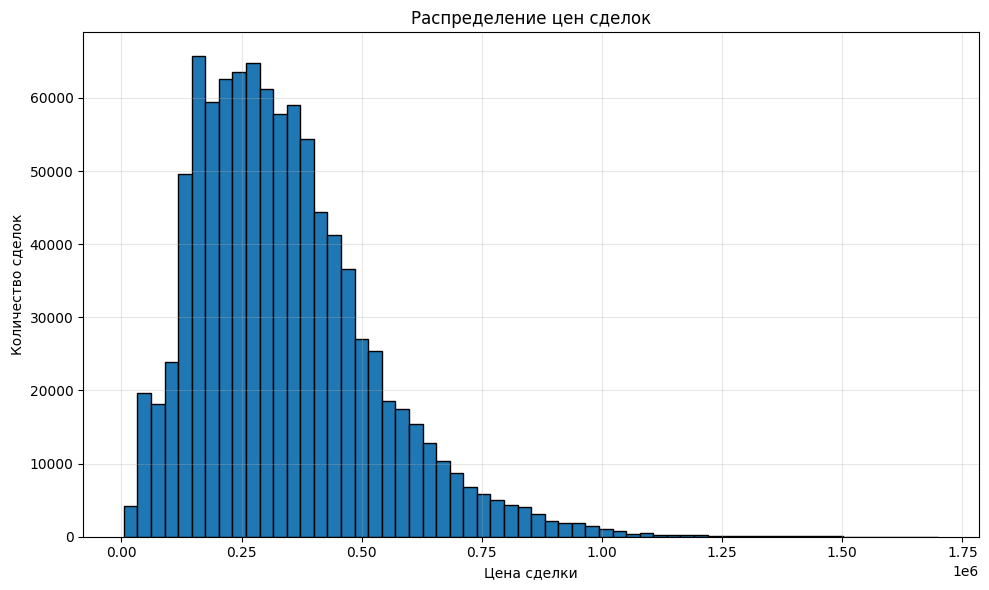

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_residential_wo_merging_prop_feats_upd['resale_price'].dropna(), bins=60, edgecolor='black')

plt.title('Распределение цен сделок')
plt.xlabel('Цена сделки')
plt.ylabel('Количество сделок')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

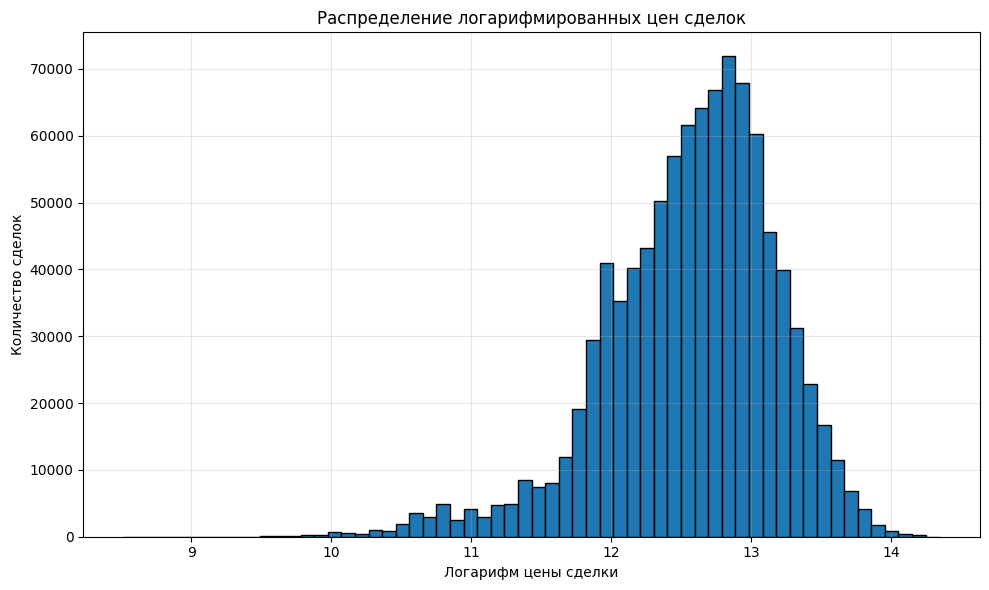

In [87]:
plt.figure(figsize=(10, 6))
plt.hist(df_residential_wo_merging_prop_feats_upd['log_resale_price'].dropna(), bins=60, edgecolor='black')

plt.title('Распределение логарифмированных цен сделок')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Количество сделок')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

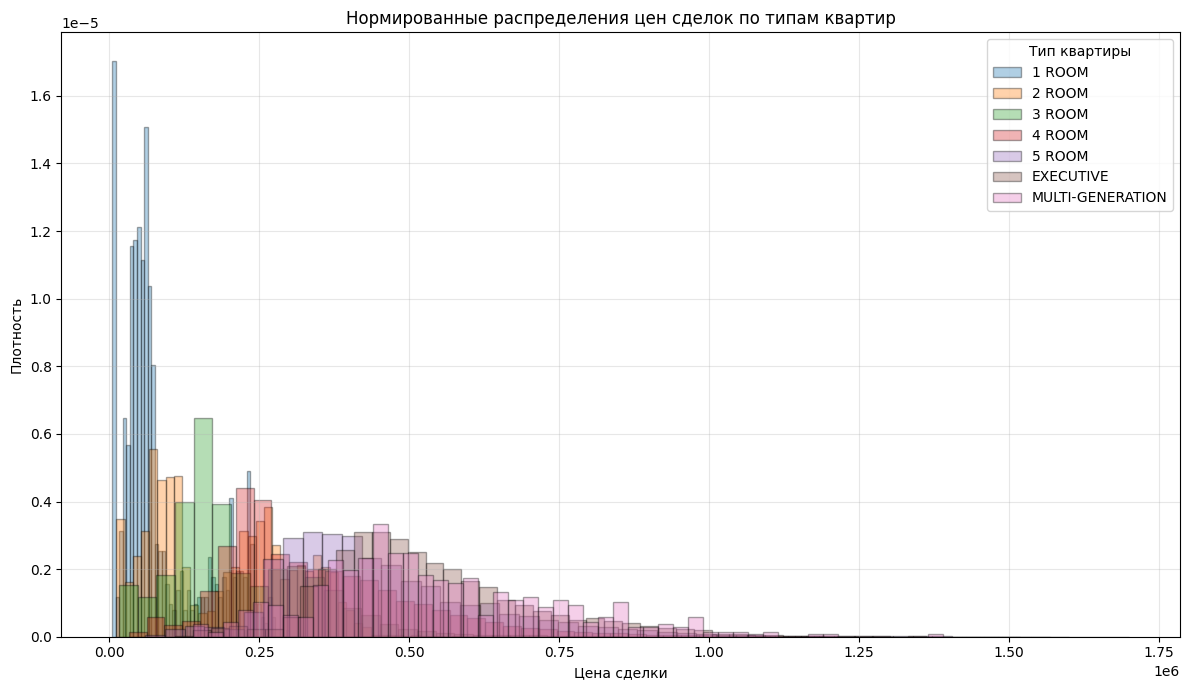

In [96]:
import matplotlib.pyplot as plt

flat_types = sorted(df_residential_wo_merging_prop_feats_upd['flat_type'].dropna().astype(str).unique())

plt.figure(figsize=(12, 7))

for flat_type in flat_types:
    vals = df_residential_wo_merging_prop_feats_upd.loc[df_residential_wo_merging_prop_feats_upd['flat_type'] == flat_type, 'resale_price'].dropna()
    plt.hist(
        vals,
        bins=50,
        alpha=0.35,
        label=flat_type,
        edgecolor='black',
        density=True
    )

plt.title('Нормированные распределения цен сделок по типам квартир')
plt.xlabel('Цена сделки')
plt.ylabel('Плотность')
plt.legend(title='Тип квартиры')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

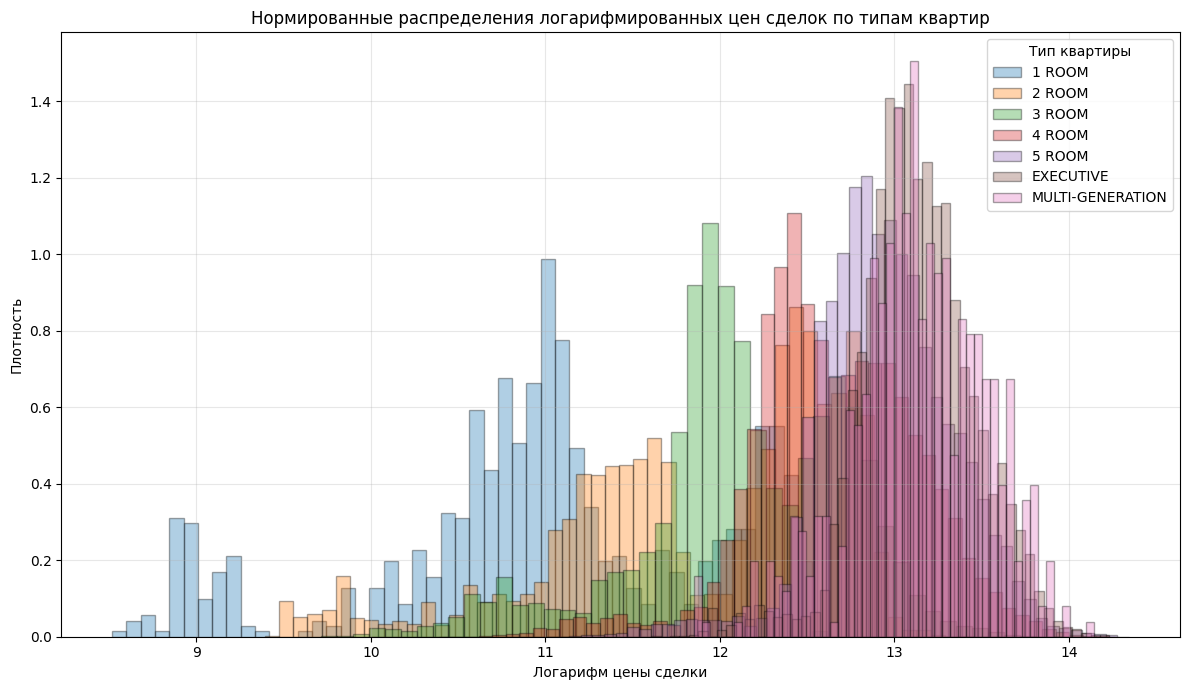

In [97]:
import numpy as np
import matplotlib.pyplot as plt

if 'log_resale_price' not in df_residential_wo_merging_prop_feats_upd.columns:
    if (df_residential_wo_merging_prop_feats_upd['resale_price'] <= 0).any():
        raise ValueError('В колонке resale_price есть значения <= 0. Для np.log нужны только положительные значения.')
    df_residential_wo_merging_prop_feats_upd['log_resale_price'] = np.log(df_residential_wo_merging_prop_feats_upd['resale_price'])

flat_types = sorted(df_residential_wo_merging_prop_feats_upd['flat_type'].dropna().astype(str).unique())

plt.figure(figsize=(12, 7))

for flat_type in flat_types:
    vals = df_residential_wo_merging_prop_feats_upd.loc[df_residential_wo_merging_prop_feats_upd['flat_type'] == flat_type, 'log_resale_price'].dropna()
    plt.hist(
        vals,
        bins=50,
        alpha=0.35,
        label=flat_type,
        edgecolor='black',
        density=True
    )

plt.title('Нормированные распределения логарифмированных цен сделок по типам квартир')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Плотность')
plt.legend(title='Тип квартиры')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

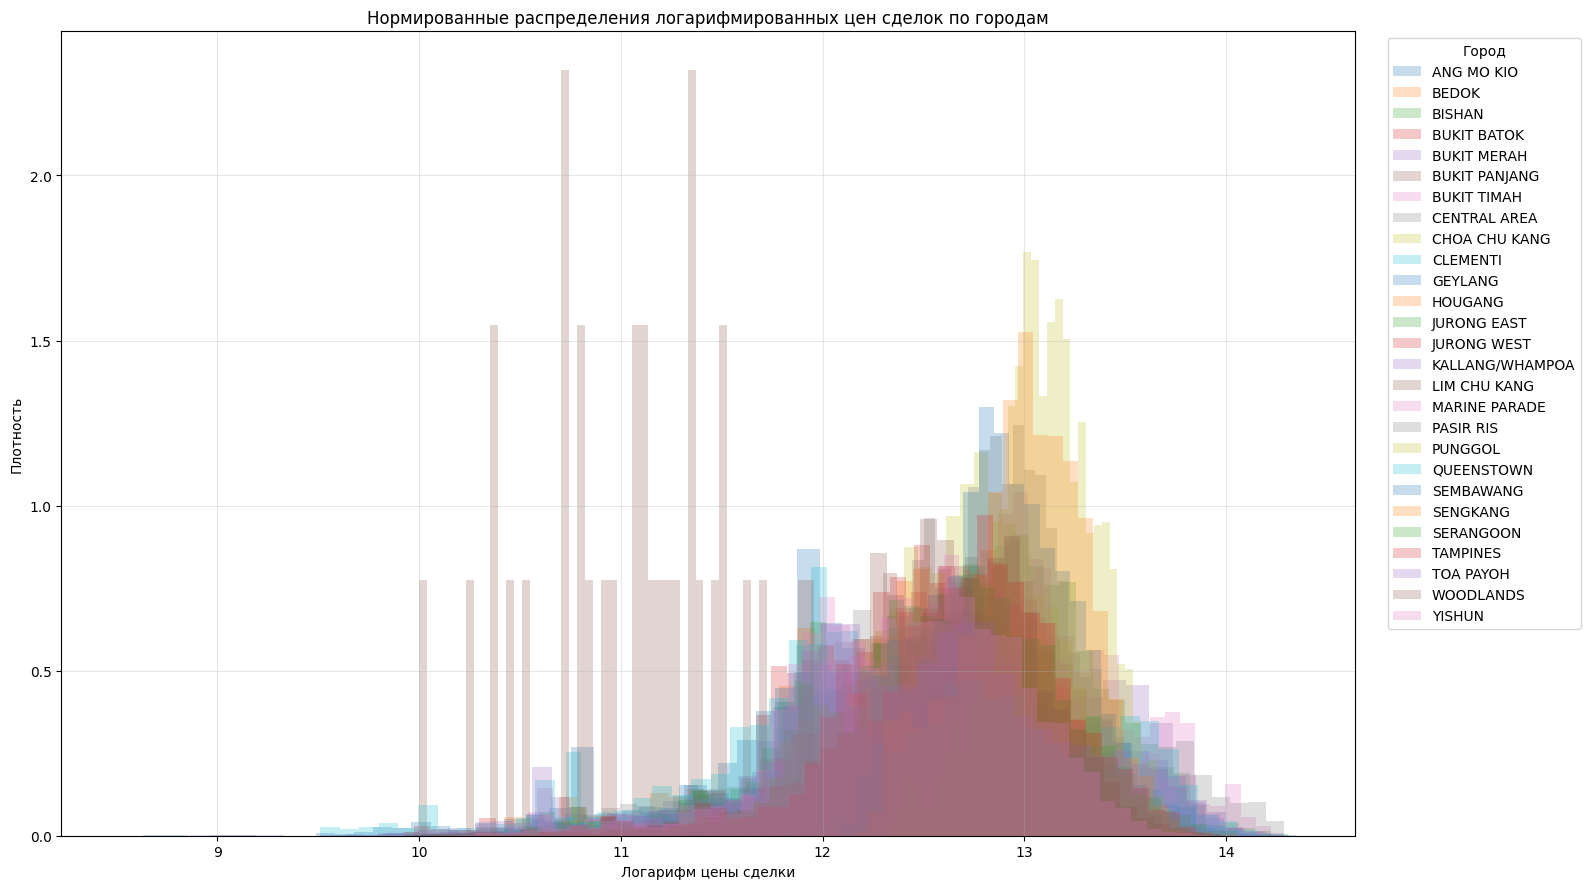

In [98]:
import matplotlib.pyplot as plt

towns = sorted(
    df_residential_wo_merging_prop_feats_upd['town']
    .dropna()
    .astype(str)
    .unique()
)

plt.figure(figsize=(16, 9))

for town in towns:
    vals = df_residential_wo_merging_prop_feats_upd.loc[
        df_residential_wo_merging_prop_feats_upd['town'] == town,
        'log_resale_price'
    ].dropna()

    if len(vals) == 0:
        continue

    plt.hist(
        vals,
        bins=50,
        density=True,
        alpha=0.25,
        label=town
    )

plt.title('Нормированные распределения логарифмированных цен сделок по городам')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Плотность')
plt.grid(alpha=0.3)
plt.legend(title='Город', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

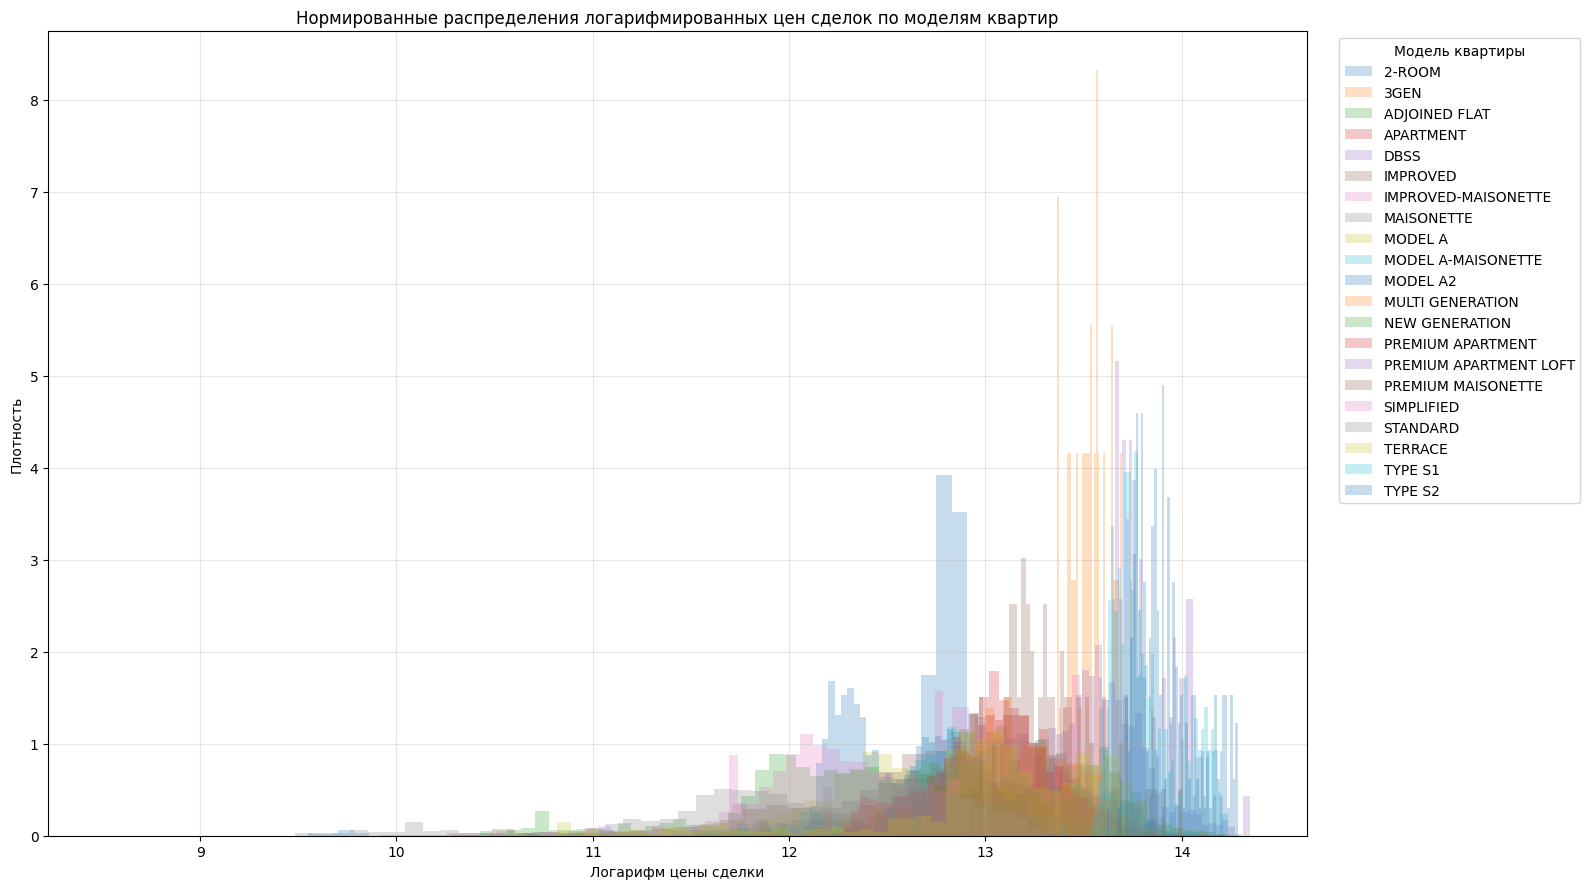

In [103]:
import matplotlib.pyplot as plt

flat_models = sorted(
    df_residential_wo_merging_prop_feats_upd['flat_model']
    .dropna()
    .astype(str)
    .unique()
)

plt.figure(figsize=(16, 9))

for flat_model in flat_models:
    vals = df_residential_wo_merging_prop_feats_upd.loc[
        df_residential_wo_merging_prop_feats_upd['flat_model'] == flat_model,
        'log_resale_price'
    ].dropna()

    if len(vals) == 0:
        continue

    plt.hist(
        vals,
        bins=50,
        density=True,
        alpha=0.25,
        label=flat_model
    )

plt.title('Нормированные распределения логарифмированных цен сделок по моделям квартир')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Плотность')
plt.grid(alpha=0.3)
plt.legend(title='Модель квартиры', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [100]:
df_residential_wo_merging_prop_feats_upd['flat_model'].unique()

array(['IMPROVED', 'TERRACE', 'STANDARD', 'NEW GENERATION', 'MODEL A',
       'MAISONETTE', 'MODEL A-MAISONETTE', 'APARTMENT', 'SIMPLIFIED',
       '2-ROOM', 'IMPROVED-MAISONETTE', 'MULTI GENERATION',
       'PREMIUM APARTMENT', 'Standard', 'Improved', 'New Generation',
       'Model A', 'Apartment', 'Adjoined flat', 'Maisonette',
       'Simplified', 'Model A-Maisonette', 'Multi Generation',
       'Premium Apartment', 'Terrace', 'Improved-Maisonette',
       'Premium Maisonette', '2-room', 'Model A2', 'DBSS', 'Type S1',
       'Type S2', 'Premium Apartment Loft', '3Gen'], dtype=object)

In [104]:
import numpy as np

sale_year = df_residential_wo_merging_prop_feats_upd['transaction_date'].dt.year

min_year = int(sale_year.min())
max_year = int(sale_year.max())

start_year = (min_year // 5) * 5
end_year = ((max_year // 5) + 1) * 5

bins = np.arange(start_year, end_year + 1, 5)
labels = [f'{bins[i]}–{bins[i + 1] - 1}' for i in range(len(bins) - 1)]

df_residential_wo_merging_prop_feats_upd['year_5y_group'] = pd.cut(
    sale_year,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df_residential_wo_merging_prop_feats_upd['year_5y_group'].value_counts(dropna=False).sort_index()

year_5y_group
1990–1994     80940
1995–1999    197819
2000–2004    164868
2005–2009    141254
2010–2014    112355
2015–2019    101409
2020–2024    132726
2025–2029     31651
Name: count, dtype: int64

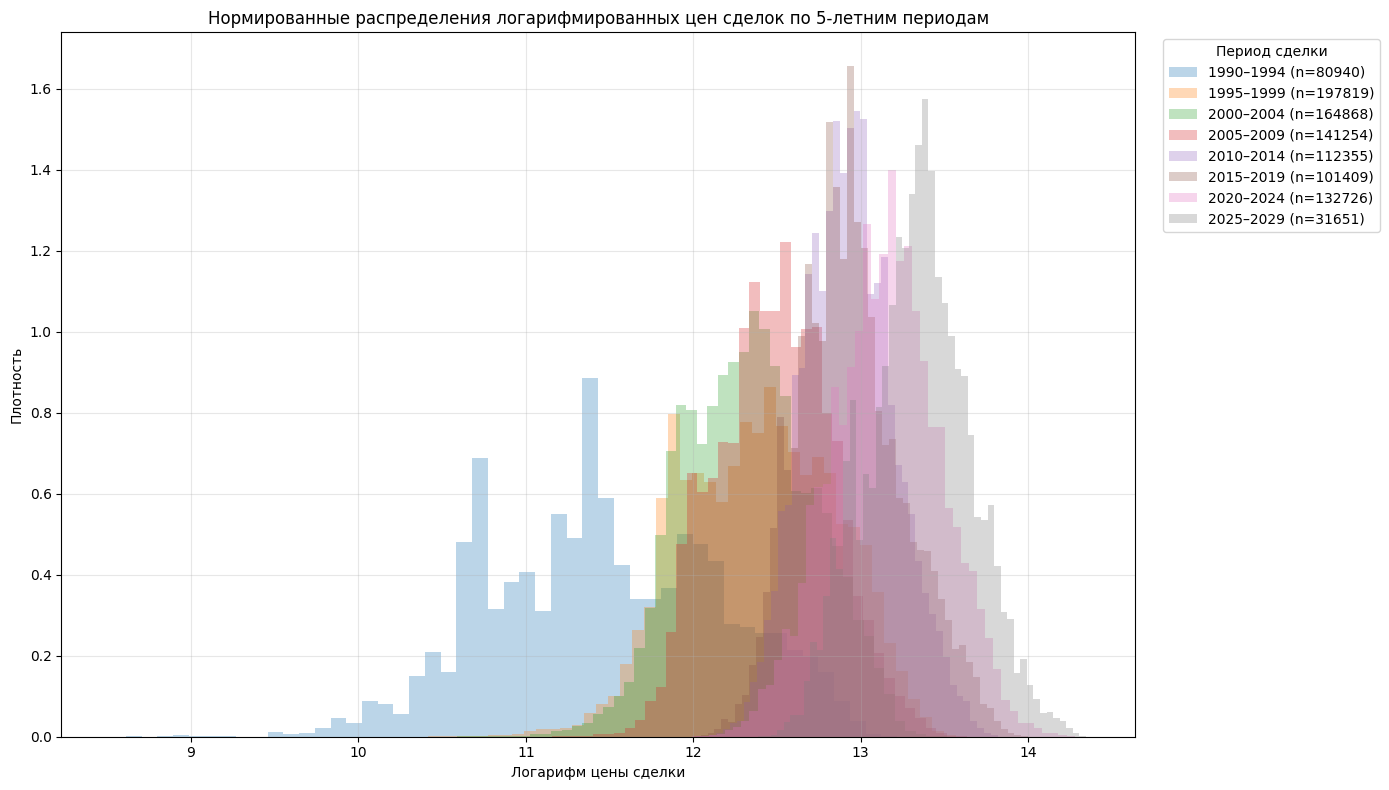

In [105]:
import matplotlib.pyplot as plt

year_groups = [
    group for group in labels
    if group in df_residential_wo_merging_prop_feats_upd['year_5y_group'].astype('string').unique()
]

plt.figure(figsize=(14, 8))

for group in year_groups:
    vals = df_residential_wo_merging_prop_feats_upd.loc[
        df_residential_wo_merging_prop_feats_upd['year_5y_group'].astype('string') == group,
        'log_resale_price'
    ].dropna()

    if len(vals) == 0:
        continue

    plt.hist(
        vals,
        bins=50,
        density=True,
        alpha=0.3,
        label=f'{group} (n={len(vals)})'
    )

plt.title('Нормированные распределения логарифмированных цен сделок по 5-летним периодам')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Плотность')
plt.grid(alpha=0.3)
plt.legend(title='Период сделки', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [106]:
import numpy as np
import pandas as pd

lease_years = df_residential_wo_merging_prop_feats_upd['remaining_lease_full_years']

min_lease = int(lease_years.min())
max_lease = int(lease_years.max())

start_lease = (min_lease // 5) * 5
end_lease = ((max_lease // 5) + 1) * 5

bins = np.arange(start_lease, end_lease + 1, 5)
labels = [f'{bins[i]}–{bins[i + 1] - 1}' for i in range(len(bins) - 1)]

df_residential_wo_merging_prop_feats_upd['remaining_lease_5y_group'] = pd.cut(
    lease_years,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df_residential_wo_merging_prop_feats_upd['remaining_lease_5y_group'].value_counts(dropna=False).sort_index()

remaining_lease_5y_group
35–39          42
40–44        1700
45–49        6081
50–54       16436
55–59       32928
60–64       55006
65–69       70995
70–74      100103
75–79      132589
80–84      151996
85–89      173500
90–94      211565
95–99       10077
100–104         4
Name: count, dtype: int64

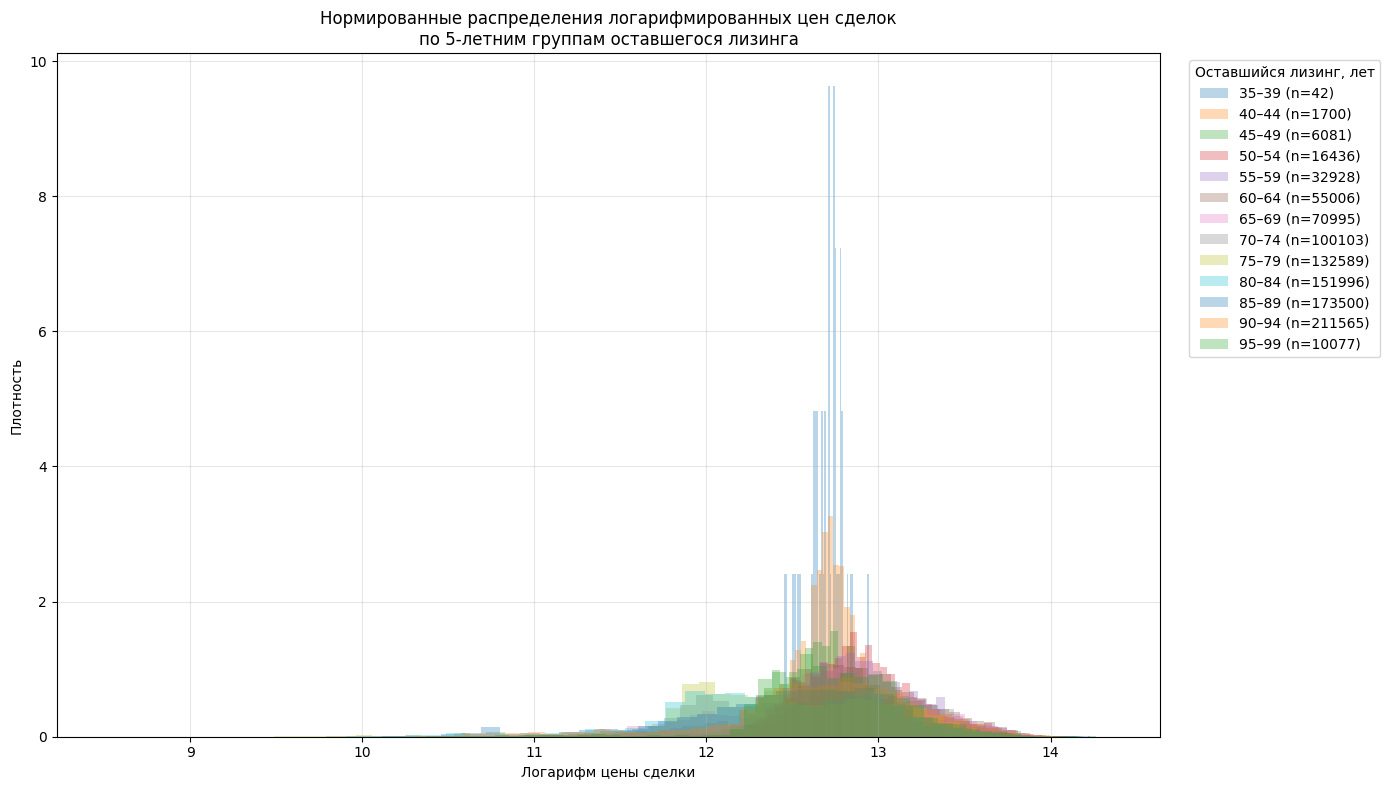

In [108]:
import matplotlib.pyplot as plt

lease_groups = [
    group for group in labels
    if group in df_residential_wo_merging_prop_feats_upd['remaining_lease_5y_group'].astype('string').unique()
]

plt.figure(figsize=(14, 8))

for group in lease_groups[:len(lease_groups) - 1]:
    vals = df_residential_wo_merging_prop_feats_upd.loc[
        df_residential_wo_merging_prop_feats_upd['remaining_lease_5y_group'].astype('string') == group,
        'log_resale_price'
    ].dropna()

    if len(vals) == 0:
        continue

    plt.hist(
        vals,
        bins=50,
        density=True,
        alpha=0.3,
        label=f'{group} (n={len(vals)})'
    )

plt.title('Нормированные распределения логарифмированных цен сделок\nпо 5-летним группам оставшегося лизинга')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Плотность')
plt.grid(alpha=0.3)
plt.legend(title='Оставшийся лизинг, лет', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

df_residential_wo_merging_prop_feats_upd = pd.read_csv('/kaggle/input/datasets/paveleshmeev/buildings-info/df_full_feats_prep.csv')

In [5]:
df_residential_wo_merging_prop_feats_upd['transaction_date'] = pd.to_datetime(df_residential_wo_merging_prop_feats_upd['transaction_date'], errors='coerce')

In [6]:
import numpy as np
import pandas as pd

df_iqr_clean = df_residential_wo_merging_prop_feats_upd.copy()

sale_year = df_iqr_clean['transaction_date'].dt.year

min_year = int(sale_year.min())
max_year = int(sale_year.max())

start_year = (min_year // 5) * 5
end_year = ((max_year // 5) + 1) * 5

bins = np.arange(start_year, end_year + 1, 5)
labels = [f'{bins[i]}–{bins[i + 1] - 1}' for i in range(len(bins) - 1)]

df_iqr_clean['year_5y_group'] = pd.cut(
    sale_year,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df_iqr_clean['year_5y_group'].value_counts(dropna=False).sort_index()

year_5y_group
1990–1994     80940
1995–1999    197819
2000–2004    164868
2005–2009    141254
2010–2014    112355
2015–2019    101409
2020–2024    132726
2025–2029     31651
Name: count, dtype: int64

In [7]:
group_cols = ['flat_type', 'town', 'year_5y_group']
target_col = 'log_resale_price'
min_group_size = 20

group_size = df_iqr_clean.groupby(group_cols)[target_col].transform('size')

q1 = df_iqr_clean.groupby(group_cols)[target_col].transform(lambda s: s.quantile(0.25))
q3 = df_iqr_clean.groupby(group_cols)[target_col].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_iqr_clean['group_size'] = group_size
df_iqr_clean['q1_iqr'] = q1
df_iqr_clean['q3_iqr'] = q3
df_iqr_clean['iqr'] = iqr
df_iqr_clean['lower_bound_iqr'] = lower_bound
df_iqr_clean['upper_bound_iqr'] = upper_bound

/tmp/ipykernel_55/989507604.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_size = df_iqr_clean.groupby(group_cols)[target_col].transform('size')
/tmp/ipykernel_55/989507604.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q1 = df_iqr_clean.groupby(group_cols)[target_col].transform(lambda s: s.quantile(0.25))
/tmp/ipykernel_55/989507604.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q3 = df_iqr_clean.gr

In [8]:
enough_obs_mask = df_iqr_clean['group_size'] >= min_group_size

non_outlier_mask = (
    df_iqr_clean[target_col].ge(df_iqr_clean['lower_bound_iqr']) &
    df_iqr_clean[target_col].le(df_iqr_clean['upper_bound_iqr'])
)

keep_mask = (
    df_iqr_clean[target_col].notna() &
    (
        (~enough_obs_mask) |
        non_outlier_mask
    )
)

df_no_outliers = df_iqr_clean.loc[keep_mask].copy()
df_outliers_only = df_iqr_clean.loc[~keep_mask].copy()

In [9]:
rows_before = len(df_iqr_clean)
rows_after = len(df_no_outliers)
rows_removed = rows_before - rows_after

print(f'Наблюдений до очистки: {rows_before:,}')
print(f'Наблюдений после очистки: {rows_after:,}')
print(f'Удалено как выбросов: {rows_removed:,}')
print(f'Доля удалённых наблюдений: {rows_removed / rows_before:.2%}')

print()
print('Число групп с размером меньше порога min_group_size:')
print((df_iqr_clean['group_size'] < min_group_size).sum())

Наблюдений до очистки: 963,022
Наблюдений после очистки: 953,872
Удалено как выбросов: 9,150
Доля удалённых наблюдений: 0.95%

Число групп с размером меньше порога min_group_size:
641


In [10]:
service_cols = [
    'year_5y_group',
    'group_size',
    'q1_iqr',
    'q3_iqr',
    'iqr',
    'lower_bound_iqr',
    'upper_bound_iqr'
]

df_no_outliers_final = df_no_outliers.drop(columns=service_cols)
df_no_outliers_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953872 entries, 0 to 963021
Data columns (total 75 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            953872 non-null  int64         
 1   transaction_date                     953872 non-null  datetime64[ns]
 2   x                                    953872 non-null  float64       
 3   y                                    953872 non-null  float64       
 4   max_floor_lvl                        948408 non-null  float64       
 5   year_completed                       948408 non-null  float64       
 6   commercial                           948408 non-null  float64       
 7   market_hawker                        948408 non-null  float64       
 8   miscellaneous                        948408 non-null  float64       
 9   multistorey_carpark                  948408 non-null  float64       
 10  p

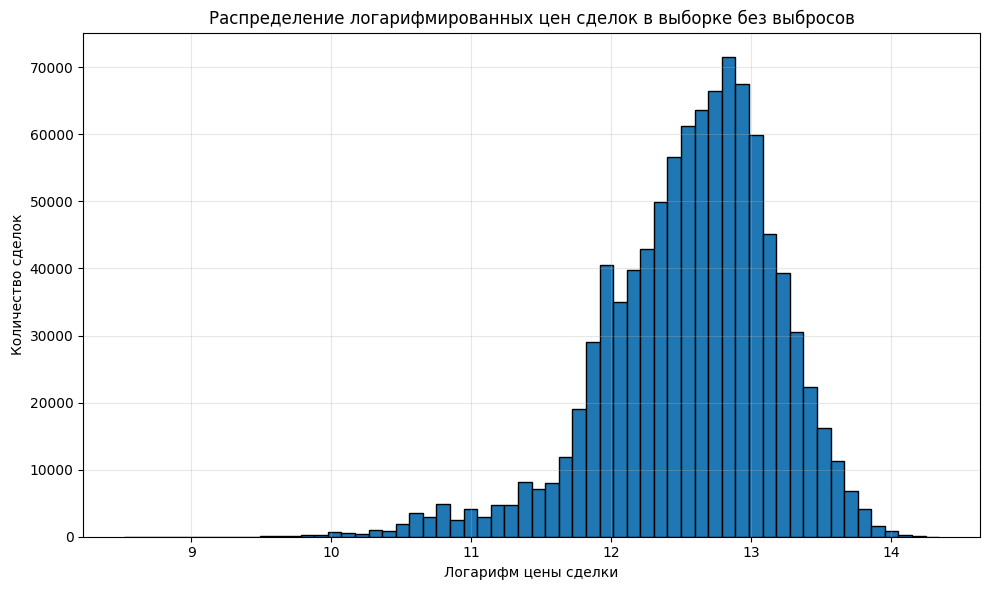

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_no_outliers_final['log_resale_price'].dropna(), bins=60, edgecolor='black')

plt.title('Распределение логарифмированных цен сделок в выборке без выбросов')
plt.xlabel('Логарифм цены сделки')
plt.ylabel('Количество сделок')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path

out_path = Path('/kaggle/working/df_full_feats_prep_no_outliers.csv')

df_no_outliers_final.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /kaggle/working/df_full_feats_prep_no_outliers.csv


## Построение выборок для обучения и тестирования моделей

### Выброс параметров и наблюдений

In [2]:
import pandas as pd

df_no_outliers_final = pd.read_csv('/kaggle/input/datasets/paveleshmeev/buildings-info/df_full_feats_prep_no_outliers.csv')

df_no_outliers_final['transaction_date'] = pd.to_datetime(df_no_outliers_final['transaction_date'], errors='coerce')

In [5]:
df_no_outliers_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953872 entries, 0 to 953871
Data columns (total 75 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            953872 non-null  int64         
 1   transaction_date                     953872 non-null  datetime64[ns]
 2   x                                    953872 non-null  float64       
 3   y                                    953872 non-null  float64       
 4   max_floor_lvl                        948408 non-null  float64       
 5   year_completed                       948408 non-null  float64       
 6   commercial                           948408 non-null  float64       
 7   market_hawker                        948408 non-null  float64       
 8   miscellaneous                        948408 non-null  float64       
 9   multistorey_carpark                  948408 non-null  float64       
 

In [3]:
import pandas as pd
import numpy as np

df_common_sample = df_no_outliers_final.copy()

cols_to_drop = [
    'compounded_sora_3m',
    'cpf_oa_calculated_rate_no_floor',
    'sgs_10y_yield',
    'steel_rebar_price',
    'term_spread_10y_2y'
]

cols_to_drop = [col for col in cols_to_drop if col in df_common_sample.columns]

df_common_sample = df_common_sample.drop(columns=cols_to_drop)

print('Удалены колонки:')
print(cols_to_drop)
print()

print('Размер до удаления пропусков:', df_common_sample.shape)

df_common_sample = df_common_sample.dropna(axis=0, how='any').copy()

print('Размер после удаления пропусков:', df_common_sample.shape)
print('Удалено строк:', len(df_no_outliers_final) - len(df_common_sample))
print('Доля сохранённых строк:', f'{len(df_common_sample) / len(df_no_outliers_final):.2%}')

Удалены колонки:
['compounded_sora_3m', 'cpf_oa_calculated_rate_no_floor', 'sgs_10y_yield', 'steel_rebar_price', 'term_spread_10y_2y']

Размер до удаления пропусков: (953872, 70)
Размер после удаления пропусков: (862189, 70)
Удалено строк: 91683
Доля сохранённых строк: 90.39%


In [4]:
na_counts = df_common_sample.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

print('Число колонок с пропусками после очистки:', len(na_counts))
print(na_counts.head(20))

Число колонок с пропусками после очистки: 0
Series([], dtype: int64)


In [5]:
date_col = 'transaction_date'

print('Исходная выборка:')
print('  min date:', df_no_outliers_final[date_col].min())
print('  max date:', df_no_outliers_final[date_col].max())
print('  n rows  :', len(df_no_outliers_final))
print()

print('Итоговая выборка:')
print('  min date:', df_common_sample[date_col].min())
print('  max date:', df_common_sample[date_col].max())
print('  n rows  :', len(df_common_sample))

Исходная выборка:
  min date: 1990-01-01 00:00:00
  max date: 2026-04-01 00:00:00
  n rows  : 953872

Итоговая выборка:
  min date: 1995-01-01 00:00:00
  max date: 2025-12-01 00:00:00
  n rows  : 862189


In [6]:
orig_months = (
    df_no_outliers_final[date_col]
    .dt.to_period('M')
    .sort_values()
)

common_months = (
    df_common_sample[date_col]
    .dt.to_period('M')
    .sort_values()
)

orig_month_range = pd.period_range(orig_months.min(), orig_months.max(), freq='M')
common_month_range = pd.period_range(common_months.min(), common_months.max(), freq='M')

missing_months_in_common_range = common_month_range.difference(common_months.unique())

print('Число месяцев в исходном диапазоне итоговой выборки:', len(common_month_range))
print('Число реально присутствующих месяцев в итоговой выборке:', common_months.nunique())
print('Число пропущенных месяцев внутри диапазона итоговой выборки:', len(missing_months_in_common_range))
print()

print('Первые 20 пропущенных месяцев:')
print(missing_months_in_common_range[:20])

Число месяцев в исходном диапазоне итоговой выборки: 372
Число реально присутствующих месяцев в итоговой выборке: 372
Число пропущенных месяцев внутри диапазона итоговой выборки: 0

Первые 20 пропущенных месяцев:
PeriodIndex([], dtype='period[M]')


In [7]:
orig_year_counts = (
    df_no_outliers_final[date_col]
    .dt.year
    .value_counts()
    .sort_index()
    .rename('n_orig')
)

common_year_counts = (
    df_common_sample[date_col]
    .dt.year
    .value_counts()
    .sort_index()
    .rename('n_common')
)

year_compare = pd.concat([orig_year_counts, common_year_counts], axis=1).fillna(0)
year_compare['n_orig'] = year_compare['n_orig'].astype(int)
year_compare['n_common'] = year_compare['n_common'].astype(int)
year_compare['retention_rate'] = year_compare['n_common'] / year_compare['n_orig']

print(year_compare)

                  n_orig  n_common  retention_rate
transaction_date                                  
1990               11777         0        0.000000
1991               12267         0        0.000000
1992               13863         0        0.000000
1993               17395         0        0.000000
1994               25506         0        0.000000
1995               25103     24830        0.989125
1996               33619     33237        0.988637
1997               30680     30353        0.989342
1998               49895     49500        0.992083
1999               56404     55800        0.989292
2000               33905     33661        0.992803
2001               37265     37043        0.994043
2002               35084     34867        0.993815
2003               28285     28100        0.993459
2004               28180     27943        0.991590
2005               29672     29458        0.992788
2006               27147     26986        0.994069
2007               26814     26

In [8]:
orig_month_counts = (
    df_no_outliers_final.assign(month=df_no_outliers_final[date_col].dt.to_period('M'))
    .groupby('month')
    .size()
    .rename('n_orig')
)

common_month_counts = (
    df_common_sample.assign(month=df_common_sample[date_col].dt.to_period('M'))
    .groupby('month')
    .size()
    .rename('n_common')
)

month_compare = pd.concat([orig_month_counts, common_month_counts], axis=1).fillna(0)
month_compare['n_orig'] = month_compare['n_orig'].astype(int)
month_compare['n_common'] = month_compare['n_common'].astype(int)
month_compare['retention_rate'] = month_compare['n_common'] / month_compare['n_orig']

print(month_compare.head(24))
print()
print(month_compare.tail(24))

         n_orig  n_common  retention_rate
month                                    
1990-01    1420         0             0.0
1990-02     876         0             0.0
1990-03    1093         0             0.0
1990-04     975         0             0.0
1990-05     709         0             0.0
1990-06     768         0             0.0
1990-07    1325         0             0.0
1990-08    1029         0             0.0
1990-09     824         0             0.0
1990-10     759         0             0.0
1990-11    1028         0             0.0
1990-12     971         0             0.0
1991-01    1205         0             0.0
1991-02     772         0             0.0
1991-03     814         0             0.0
1991-04     876         0             0.0
1991-05     893         0             0.0
1991-06     795         0             0.0
1991-07    1199         0             0.0
1991-08    1117         0             0.0
1991-09    1153         0             0.0
1991-10    1135         0         

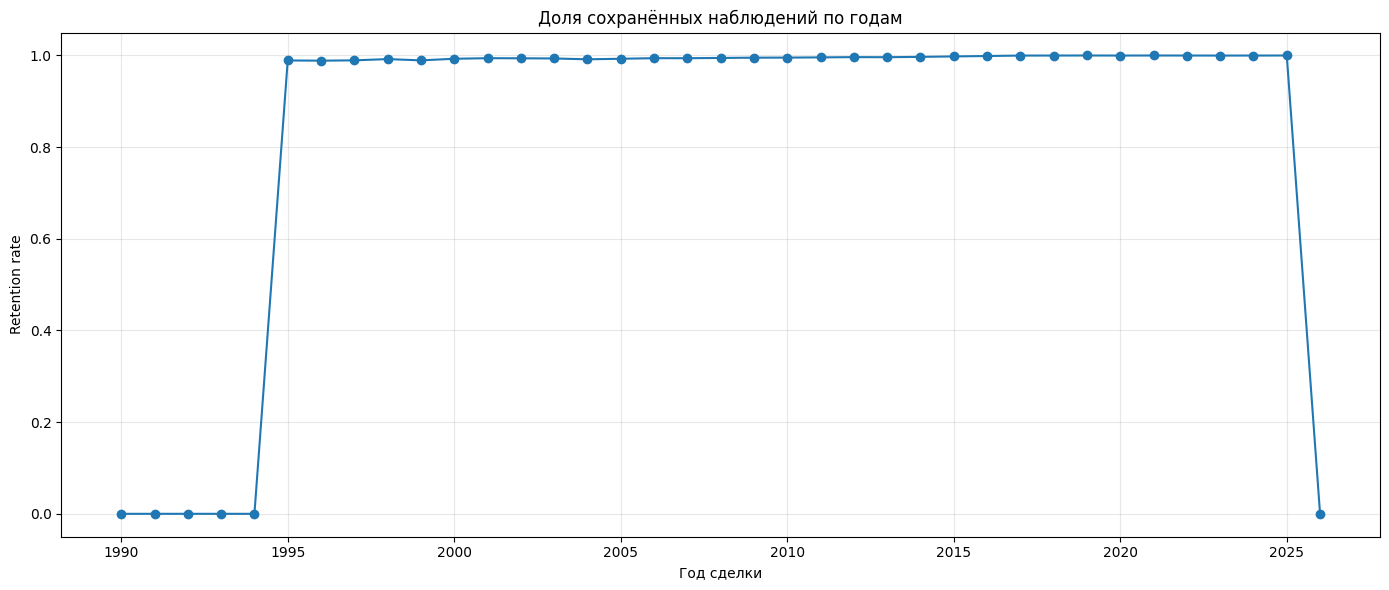

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(year_compare.index, year_compare['retention_rate'], marker='o')
plt.title('Доля сохранённых наблюдений по годам')
plt.xlabel('Год сделки')
plt.ylabel('Retention rate')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
ltv_std_cols = ['ltv_first_std', 'ltv_second_std', 'ltv_third_plus_std']
ltv_long_cols = ['ltv_first_long', 'ltv_second_long', 'ltv_third_plus_long']

df_common_sample['ltv_std_mean'] = df_common_sample[ltv_std_cols].mean(axis=1)
df_common_sample['ltv_long_mean'] = df_common_sample[ltv_long_cols].mean(axis=1)

df_common_sample['flat_type_norm'] = (
    df_common_sample['flat_type']
    .astype('string')
    .str.strip()
    .str.upper()
)

df_common_sample['flat_type_norm'] = df_common_sample['flat_type_norm'].replace({
    'MULTI GENERATION': 'MULTI-GENERATION'
})

flat_type_to_hdb_ltv_col = {
    '1 ROOM': 'hdb_ltv_1room',
    '2 ROOM': 'hdb_ltv_2room',
    '3 ROOM': 'hdb_ltv_3room',
    '4 ROOM': 'hdb_ltv_4room',
    '5 ROOM': 'hdb_ltv_5room',
    'EXECUTIVE': 'hdb_ltv_exec',
    'MULTI-GENERATION': 'hdb_ltv_others'
}

flat_type_ltv_col = df_common_sample['flat_type_norm'].map(flat_type_to_hdb_ltv_col)

df_common_sample['hdb_ltv_by_flat_type'] = [
    row[col] if pd.notna(col) else pd.NA
    for (_, row), col in zip(df_common_sample.iterrows(), flat_type_ltv_col)
]

unknown_flat_types = (
    df_common_sample.loc[flat_type_ltv_col.isna(), 'flat_type_norm']
    .dropna()
    .unique()
    .tolist()
)

print('Нераспознанные значения flat_type:', unknown_flat_types)

Нераспознанные значения flat_type: []


In [10]:
from pathlib import Path

out_path = Path('/kaggle/working/df_common_sample_complete_case.csv')
df_common_sample.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /kaggle/working/df_common_sample_complete_case.csv


In [1]:
import pandas as pd

df_common_sample = pd.read_csv('/kaggle/input/datasets/paveleshmeev/sgp-resale-prices-90/df_common_sample_complete_case.csv')

df_common_sample.head()

,resale_id,transaction_date,x,y,max_floor_lvl,year_completed,commercial,market_hawker,miscellaneous,multistorey_carpark,...,household_net_worth,resale_price,floor_mean,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,remaining_lease_full_years,log_resale_price
0,85762,1995-01-01,24111.492688,30993.386185,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,54000.0,2,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.896739
1,85763,1995-01-01,24094.806524,31073.554178,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,42000.0,5,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.645425
2,85764,1995-01-01,24094.806524,31073.554178,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,40000.0,11,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.596635
3,85773,1995-01-01,22581.776154,32150.973599,14.0,1975.0,0.0,0.0,0.0,0.0,...,423213.9,126000.0,11,QUEENSTOWN,3 ROOM,73.0,IMPROVED,1976,79,11.744037
4,85749,1995-01-01,23968.094605,31179.678814,10.0,1963.0,0.0,0.0,0.0,0.0,...,423213.9,45000.0,11,QUEENSTOWN,2 ROOM,46.0,STANDARD,1983,86,10.714418


### Разделение на train, test, val

In [22]:
import pandas as pd
import numpy as np

df_common_sample = df_common_sample.copy()

if not pd.api.types.is_datetime64_any_dtype(df_common_sample['transaction_date']):
    df_common_sample['transaction_date'] = pd.to_datetime(
        df_common_sample['transaction_date'],
        errors='coerce'
    )

df_common_sample = df_common_sample.sort_values('transaction_date').reset_index(drop=True)
df_common_sample['sale_year'] = df_common_sample['transaction_date'].dt.year

print('Диапазон дат:')
print(df_common_sample['transaction_date'].min(), '->', df_common_sample['transaction_date'].max())
print()
print('Число наблюдений по годам:')
print(df_common_sample['sale_year'].value_counts().sort_index())

Диапазон дат:
1995-01-01 00:00:00 -> 2025-12-01 00:00:00

Число наблюдений по годам:
sale_year
1995    24830
1996    33237
1997    30353
1998    49500
1999    55800
2000    33661
2001    37043
2002    34867
2003    28100
2004    27943
2005    29458
2006    26986
2007    26653
2008    26945
2009    30174
2010    33951
2011    22076
2012    23024
2013    15882
2014    15941
2015    17601
2016    19139
2017    20248
2018    21203
2019    21462
2020    22812
2021    28984
2022    26614
2023    25565
2024    27443
2025    24694
Name: count, dtype: int64


In [23]:
year_counts = (
    df_common_sample['sale_year']
    .value_counts()
    .sort_index()
    .rename('n_obs')
    .to_frame()
)

total_n = len(df_common_sample)
max_year = int(df_common_sample['sale_year'].max())

candidates = []

for test_years in [2]:
    test_start_year = max_year - test_years + 1
    val_year = test_start_year - 1

    train_mask = df_common_sample['sale_year'] < val_year
    val_mask = df_common_sample['sale_year'] == val_year
    test_mask = df_common_sample['sale_year'] >= test_start_year

    train_n = int(train_mask.sum())
    val_n = int(val_mask.sum())
    test_n = int(test_mask.sum())

    if min(train_n, val_n, test_n) == 0:
        continue

    train_share = train_n / total_n
    val_share = val_n / total_n
    test_share = test_n / total_n

    in_target_range = (0.20 <= test_share <= 0.30)
    score = abs(val_share - 0.10) + abs(test_share - 0.25)

    candidates.append({
        'test_years': test_years,
        'val_year': val_year,
        'test_start_year': test_start_year,
        'train_n': train_n,
        'val_n': val_n,
        'test_n': test_n,
        'train_share': train_share,
        'val_share': val_share,
        'test_share': test_share,
        'in_target_range': in_target_range,
        'score': score
    })

candidates_df = pd.DataFrame(candidates)

if candidates_df.empty:
    raise ValueError('Не удалось сформировать допустимые кандидаты для split.')

print('Кандидаты:')
print(candidates_df)

if candidates_df['in_target_range'].any():
    best_split = (
        candidates_df[candidates_df['in_target_range']]
        .sort_values(['score', 'test_years'])
        .iloc[0]
    )
else:
    best_split = (
        candidates_df
        .sort_values(['score', 'test_years'])
        .iloc[0]
    )

print()
print('Выбранный вариант:')
print(best_split)

Кандидаты:
   test_years  val_year  test_start_year  train_n  val_n  test_n  train_share  \
0           2      2023             2024   784487  25565   52137     0.909878   

   val_share  test_share  in_target_range     score  
0   0.029651    0.060471            False  0.259878  

Выбранный вариант:
test_years                2
val_year               2023
test_start_year        2024
train_n              784487
val_n                 25565
test_n                52137
train_share        0.909878
val_share          0.029651
test_share         0.060471
in_target_range       False
score              0.259878
Name: 0, dtype: object


In [24]:
val_year = int(best_split['val_year'])
test_start_year = int(best_split['test_start_year'])

train_mask = df_common_sample['sale_year'] < val_year
val_mask = df_common_sample['sale_year'] == val_year
test_mask = df_common_sample['sale_year'] >= test_start_year

df_train = df_common_sample.loc[train_mask].copy()
df_val = df_common_sample.loc[val_mask].copy()
df_test = df_common_sample.loc[test_mask].copy()

print(f'Validation year: {val_year}')
print(f'Test starts from: {test_start_year}')
print()

print('Размеры выборок:')
print(f'train: {len(df_train):,} ({len(df_train) / total_n:.2%})')
print(f'val:   {len(df_val):,} ({len(df_val) / total_n:.2%})')
print(f'test:  {len(df_test):,} ({len(df_test) / total_n:.2%})')

Validation year: 2023
Test starts from: 2024

Размеры выборок:
train: 784,487 (90.99%)
val:   25,565 (2.97%)
test:  52,137 (6.05%)


In [25]:
def split_summary(df, name):
    print(name)
    print('  min date:', df['transaction_date'].min())
    print('  max date:', df['transaction_date'].max())
    print('  n rows  :', len(df))
    print()

split_summary(df_train, 'TRAIN')
split_summary(df_val, 'VALIDATION')
split_summary(df_test, 'TEST')

TRAIN
  min date: 1995-01-01 00:00:00
  max date: 2022-12-01 00:00:00
  n rows  : 784487

VALIDATION
  min date: 2023-01-01 00:00:00
  max date: 2023-12-01 00:00:00
  n rows  : 25565

TEST
  min date: 2024-01-01 00:00:00
  max date: 2025-12-01 00:00:00
  n rows  : 52137



In [ ]:
# from pathlib import Path

# train_path = Path('/kaggle/working/df_train_recent_split.csv')
# val_path = Path('/kaggle/working/df_val_recent_split.csv')
# test_path = Path('/kaggle/working/df_test_recent_split.csv')

# df_train.to_csv(train_path, index=False)
# df_val.to_csv(val_path, index=False)
# df_test.to_csv(test_path, index=False)

# print(f'Saved: {train_path}')
# print(f'Saved: {val_path}')
# print(f'Saved: {test_path}')

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df_common_sample = df_common_sample.copy()

if not pd.api.types.is_datetime64_any_dtype(df_common_sample['transaction_date']):
    df_common_sample['transaction_date'] = pd.to_datetime(
        df_common_sample['transaction_date'],
        errors='coerce'
    )

df_common_sample['sale_year'] = df_common_sample['transaction_date'].dt.year

print(df_common_sample[['transaction_date', 'sale_year']].head())
print()
print(df_common_sample['sale_year'].value_counts().sort_index())

      transaction_date  sale_year
80808       1995-01-01       1995
80809       1995-01-01       1995
80810       1995-01-01       1995
80812       1995-01-01       1995
80813       1995-01-01       1995

sale_year
1995    24830
1996    33237
1997    30353
1998    49500
1999    55800
2000    33661
2001    37043
2002    34867
2003    28100
2004    27943
2005    29458
2006    26986
2007    26653
2008    26945
2009    30174
2010    33951
2011    22076
2012    23024
2013    15882
2014    15941
2015    17601
2016    19139
2017    20248
2018    21203
2019    21462
2020    22812
2021    28984
2022    26614
2023    25565
2024    27443
2025    24694
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df_common_sample = df_common_sample.copy()

if not pd.api.types.is_datetime64_any_dtype(df_common_sample['transaction_date']):
    df_common_sample['transaction_date'] = pd.to_datetime(
        df_common_sample['transaction_date'],
        errors='coerce'
    )

df_common_sample['sale_year'] = df_common_sample['transaction_date'].dt.year

print(df_common_sample[['transaction_date', 'sale_year']].head())
print()
print(df_common_sample['sale_year'].value_counts().sort_index())

  transaction_date  sale_year
0       1995-01-01       1995
1       1995-01-01       1995
2       1995-01-01       1995
3       1995-01-01       1995
4       1995-01-01       1995

sale_year
1995    24830
1996    33237
1997    30353
1998    49500
1999    55800
2000    33661
2001    37043
2002    34867
2003    28100
2004    27943
2005    29458
2006    26986
2007    26653
2008    26945
2009    30174
2010    33951
2011    22076
2012    23024
2013    15882
2014    15941
2015    17601
2016    19139
2017    20248
2018    21203
2019    21462
2020    22812
2021    28984
2022    26614
2023    25565
2024    27443
2025    24694
Name: count, dtype: int64


In [12]:
random_state = 42

df_train, df_temp = train_test_split(
    df_common_sample,
    test_size=0.30,
    random_state=random_state,
    shuffle=True,
    stratify=df_common_sample['sale_year']
)

print('train:', df_train.shape)
print('temp: ', df_temp.shape)

train: (603532, 75)
temp:  (258657, 75)


In [4]:
random_state = 42

df_train, df_temp = train_test_split(
    df_common_sample,
    test_size=0.30,
    random_state=random_state,
    shuffle=True,
    stratify=df_common_sample['sale_year']
)

print('train:', df_train.shape)
print('temp: ', df_temp.shape)

train: (603532, 71)
temp:  (258657, 71)


In [13]:
df_val, df_test = train_test_split(
    df_temp,
    test_size=2/3,
    random_state=random_state,
    shuffle=True,
    stratify=df_temp['sale_year']
)

print('train:', df_train.shape, f'({len(df_train) / len(df_common_sample):.2%})')
print('val:  ', df_val.shape,   f'({len(df_val) / len(df_common_sample):.2%})')
print('test: ', df_test.shape,  f'({len(df_test) / len(df_common_sample):.2%})')

train: (603532, 75) (70.00%)
val:   (86219, 75) (10.00%)
test:  (172438, 75) (20.00%)


In [5]:
df_val, df_test = train_test_split(
    df_temp,
    test_size=2/3,
    random_state=random_state,
    shuffle=True,
    stratify=df_temp['sale_year']
)

print('train:', df_train.shape, f'({len(df_train) / len(df_common_sample):.2%})')
print('val:  ', df_val.shape,   f'({len(df_val) / len(df_common_sample):.2%})')
print('test: ', df_test.shape,  f'({len(df_test) / len(df_common_sample):.2%})')

train: (603532, 71) (70.00%)
val:   (86219, 71) (10.00%)
test:  (172438, 71) (20.00%)


In [14]:
train_year_dist = (
    df_train['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('train_share')
)

val_year_dist = (
    df_val['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('val_share')
)

test_year_dist = (
    df_test['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('test_share')
)

year_dist_compare = pd.concat(
    [train_year_dist, val_year_dist, test_year_dist],
    axis=1
).fillna(0)

display(year_dist_compare)

,train_share,val_share,test_share
sale_year,,,
1995,0.028799,0.028799,0.028799
1996,0.038550,0.038553,0.038547
1997,0.035204,0.035201,0.035207
1998,0.057412,0.057412,0.057412
1999,0.064719,0.064719,0.064719
2000,0.039042,0.039040,0.039040
2001,0.042964,0.042960,0.042966
2002,0.040440,0.040444,0.040438
2003,0.032591,0.032591,0.032591


In [6]:
train_year_dist = (
    df_train['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('train_share')
)

val_year_dist = (
    df_val['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('val_share')
)

test_year_dist = (
    df_test['sale_year']
    .value_counts(normalize=True)
    .sort_index()
    .rename('test_share')
)

year_dist_compare = pd.concat(
    [train_year_dist, val_year_dist, test_year_dist],
    axis=1
).fillna(0)

display(year_dist_compare)

,train_share,val_share,test_share
sale_year,,,
1995,0.028799,0.028799,0.028799
1996,0.038550,0.038553,0.038547
1997,0.035204,0.035201,0.035207
1998,0.057412,0.057412,0.057412
1999,0.064719,0.064719,0.064719
2000,0.039042,0.039040,0.039040
2001,0.042964,0.042960,0.042966
2002,0.040440,0.040444,0.040438
2003,0.032591,0.032591,0.032591


In [15]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

## Построение моделей

## 1. Эконометрические

## 1.1 Базовая log-hedonic OLS

$\ln{price_t} = \beta X + I(t)$

In [68]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603532 entries, 0 to 603531
Data columns (total 71 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            603532 non-null  int64         
 1   transaction_date                     603532 non-null  datetime64[ns]
 2   x                                    603532 non-null  float64       
 3   y                                    603532 non-null  float64       
 4   max_floor_lvl                        603532 non-null  float64       
 5   year_completed                       603532 non-null  float64       
 6   commercial                           603532 non-null  float64       
 7   market_hawker                        603532 non-null  float64       
 8   miscellaneous                        603532 non-null  float64       
 9   multistorey_carpark                  603532 non-null  float64       
 

In [36]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.graphics.gofplots import qqplot

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

for df_ in [df_train, df_val, df_test]:
    if not pd.api.types.is_datetime64_any_dtype(df_['transaction_date']):
        df_['transaction_date'] = pd.to_datetime(df_['transaction_date'], errors='coerce')

    df_['transaction_year'] = df_['transaction_date'].dt.to_period('Y').astype(str)

In [83]:
target_col = 'log_resale_price'

numeric_features = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    'flat_type',
    'town'
]

model_cols = (
    [target_col, 'transaction_year']
    + numeric_features
    + binary_building_features
    + categorical_features
)

train_hedonic = df_train[model_cols].dropna().copy()
val_hedonic = df_val[model_cols].dropna().copy()
train_hedonic = pd.concat([train_hedonic, val_hedonic], ignore_index=True)

test_hedonic = df_test[model_cols].dropna().copy()

print('train:', train_hedonic.shape)
print('val:  ', val_hedonic.shape)
print('test: ', test_hedonic.shape)

train: (689751, 14)
val:   (86219, 14)
test:  (172438, 14)


In [84]:
print('Описательные статистики числовых признаков:')
display(train_hedonic[numeric_features + binary_building_features].describe().T)

print('Корреляции числовых признаков:')
display(train_hedonic[numeric_features + binary_building_features].corr())

X_vif = train_hedonic[numeric_features + binary_building_features].copy()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

display(vif_df)

Описательные статистики числовых признаков:


,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,689751.0,96.800476,25.311815,31.0,73.0,95.0,114.0,243.0
remaining_lease_full_years,689751.0,79.145640,11.272369,39.0,72.0,81.0,88.0,100.0
floor_mean,689751.0,7.787484,4.927071,2.0,5.0,8.0,11.0,50.0
max_floor_lvl,689751.0,14.115111,5.257484,2.0,12.0,13.0,16.0,50.0
total_dwelling_units,689751.0,124.202609,58.568684,2.0,90.0,112.0,144.0,584.0
commercial,689751.0,0.209709,0.407101,0.0,0.0,0.0,0.0,1.0
market_hawker,689751.0,0.000110,0.010496,0.0,0.0,0.0,0.0,1.0
miscellaneous,689751.0,0.317981,0.465693,0.0,0.0,0.0,1.0,1.0
multistorey_carpark,689751.0,0.000223,0.014941,0.0,0.0,0.0,0.0,1.0
precinct_pavilion,689751.0,0.000639,0.025278,0.0,0.0,0.0,0.0,1.0


Корреляции числовых признаков:


,floor_area_sqm,remaining_lease_full_years,floor_mean,max_floor_lvl,total_dwelling_units,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion
floor_area_sqm,1.000000,0.329417,0.034502,0.104005,-0.470868,-0.122288,-0.016474,-0.084082,0.002867,-0.015628
remaining_lease_full_years,0.329417,1.000000,0.091891,0.184168,-0.228160,-0.116428,-0.005662,-0.055642,0.007055,0.028762
floor_mean,0.034502,0.091891,1.000000,0.521460,0.178776,-0.053991,-0.001902,-0.021499,0.004347,0.017924
max_floor_lvl,0.104005,0.184168,0.521460,1.000000,0.319321,-0.118339,-0.010213,-0.042802,-0.000733,0.029556
total_dwelling_units,-0.470868,-0.228160,0.178776,0.319321,1.000000,0.047651,0.000501,0.217963,-0.016852,0.027532
commercial,-0.122288,-0.116428,-0.053991,-0.118339,0.047651,1.000000,0.020378,-0.105326,-0.000547,-0.013029
market_hawker,-0.016474,-0.005662,-0.001902,-0.010213,0.000501,0.020378,1.000000,-0.007168,-0.000157,-0.000266
miscellaneous,-0.084082,-0.055642,-0.021499,-0.042802,0.217963,-0.105326,-0.007168,1.000000,-0.010204,0.019554
multistorey_carpark,0.002867,0.007055,0.004347,-0.000733,-0.016852,-0.000547,-0.000157,-0.010204,1.000000,-0.000378
precinct_pavilion,-0.015628,0.028762,0.017924,0.029556,0.027532,-0.013029,-0.000266,0.019554,-0.000378,1.000000


,variable,vif
0,const,81.219179
1,floor_area_sqm,1.479517
2,remaining_lease_full_years,1.192129
3,floor_mean,1.374378
4,max_floor_lvl,1.704520
5,total_dwelling_units,1.711491
6,commercial,1.051198
7,market_hawker,1.000736
8,miscellaneous,1.089785
9,multistorey_carpark,1.000443


In [85]:
formula_hedonic_time_dummy = """
log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
C(flat_type) +
C(town) +
C(transaction_year)
"""
print(formula_hedonic_time_dummy)


log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
C(flat_type) +
C(town) +
C(transaction_year)



In [86]:
hedonic_model = smf.ols(formula=formula_hedonic_time_dummy, data=train_hedonic)
hedonic_res = hedonic_model.fit()

print(hedonic_res.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 1.308e+05
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:39:35   Log-Likelihood:             4.3547e+05
No. Observations:              689751   AIC:                        -8.708e+05
Df Residuals:                  689679   BIC:                        -8.700e+05
Df Model:                          71                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [87]:
hedonic_res_hc3 = hedonic_res.get_robustcov_results(cov_type='HC3')

print(hedonic_res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 1.351e+05
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:40:21   Log-Likelihood:             4.3547e+05
No. Observations:              689751   AIC:                        -8.708e+05
Df Residuals:                  689679   BIC:                        -8.700e+05
Df Model:                          71                                         
Covariance Type:                  HC3                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [88]:
bp_test = het_breuschpagan(hedonic_res.resid, hedonic_res.model.exog)

bp_results = pd.Series(
    bp_test,
    index=['LM stat', 'LM p-value', 'F stat', 'F p-value']
)

print('Breusch-Pagan test:')
display(bp_results)

Breusch-Pagan test:


LM stat       112047.027993
LM p-value         0.000000
F stat          1884.011900
F p-value          0.000000
dtype: float64

In [89]:
reset_res = linear_reset(hedonic_res, power=2, use_f=True)

print('RESET test:')
print(reset_res)

RESET test:
<F test: F=69239.58054258648, p=0.0, df_denom=6.9e+05, df_num=1>


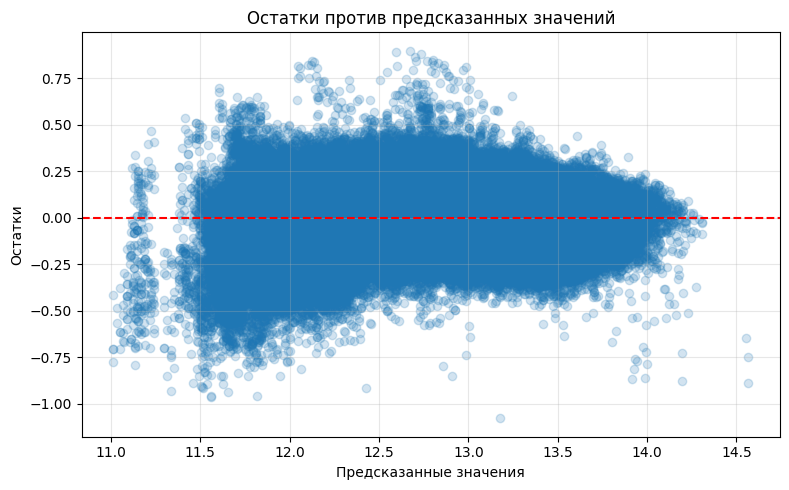

<Figure size 800x500 with 0 Axes>

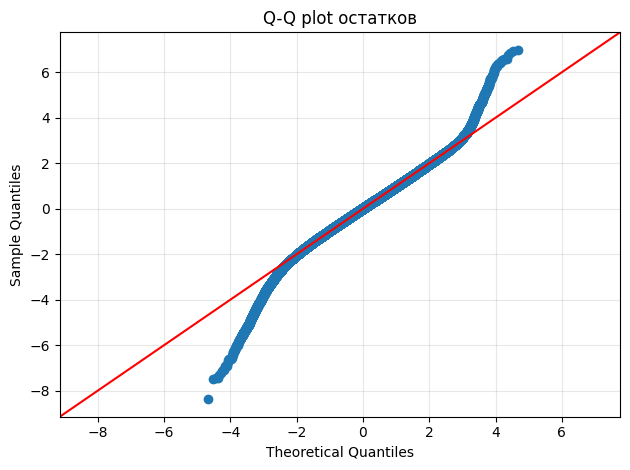

In [90]:
plt.figure(figsize=(8, 5))
plt.scatter(hedonic_res.fittedvalues, hedonic_res.resid, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки против предсказанных значений')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
qqplot(hedonic_res.resid, line='45', fit=True)
plt.title('Q-Q plot остатков')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
train_pred = hedonic_res.predict(train_hedonic)
test_pred = hedonic_res.predict(test_hedonic)

In [92]:
base_ols_v0_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae': [
        mean_absolute_error(train_hedonic[target_col], train_pred),
        mean_absolute_error(test_hedonic[target_col], test_pred)
    ],
    'rmse': [
        root_mean_squared_error(train_hedonic[target_col], train_pred),
        root_mean_squared_error(test_hedonic[target_col], test_pred)
    ],
    'r2': [
        r2_score(train_hedonic[target_col], train_pred),
        r2_score(test_hedonic[target_col], test_pred)
    ]
})

display(base_ols_v0_metrics_df)

,sample,mae,rmse,r2
0,train,0.100643,0.128699,0.930851
1,test,0.100406,0.128366,0.930969


In [93]:
train_pred_price = np.exp(train_pred)
test_pred_price = np.exp(test_pred)

base_ols_v0_price_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae_price': [
        mean_absolute_error(np.exp(train_hedonic[target_col]), train_pred_price),
        mean_absolute_error(np.exp(test_hedonic[target_col]), test_pred_price)
    ],
    'rmse_price': [
        root_mean_squared_error(np.exp(train_hedonic[target_col]), train_pred_price),
        root_mean_squared_error(np.exp(test_hedonic[target_col]), test_pred_price)
    ],
    'r2_price_level': [
        r2_score(np.exp(train_hedonic[target_col]), train_pred_price),
        r2_score(np.exp(test_hedonic[target_col]), test_pred_price)
    ]
})

display(base_ols_v0_price_metrics_df)

,sample,mae_price,rmse_price,r2_price_level
0,train,34991.742798,48496.555360,0.923972
1,test,34876.440426,48238.613091,0.924194


## 1.2 Log-hedonic OLS + location

In [97]:
target_col = 'log_resale_price'

numeric_features_base = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    'flat_type',
    'town'
]

location_numeric_features = [
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km'
]

model_cols = (
    [target_col, 'transaction_year']
    + numeric_features_base
    + binary_building_features
    + location_numeric_features
    + categorical_features
)

train_loc = df_train[model_cols].dropna().copy()
val_loc = df_val[model_cols].dropna().copy()
train_loc = pd.concat([train_loc, val_loc], ignore_index=True)

test_loc = df_test[model_cols].dropna().copy()

print('train:', train_loc.shape)
print('val:  ', val_loc.shape)
print('test: ', test_loc.shape)

train: (689751, 27)
val:   (86219, 27)
test:  (172438, 27)


In [98]:
all_numeric_features = (
    numeric_features_base
    + binary_building_features
    + location_numeric_features
)

X_vif = train_loc[all_numeric_features].copy()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

display(vif_df.sort_values('vif', ascending=False))

,variable,vif
0,const,163.372614
13,dist_to_raffles_place_m,3.578667
23,hawker_centre_count_1km,2.766791
20,dist_nearest_hospital_m,2.023520
17,secondary_school_count_1km,1.938951
4,max_floor_lvl,1.888208
22,dist_nearest_hawker_centre_m,1.793807
5,total_dwelling_units,1.776418
15,primary_school_count_1km,1.768646
16,dist_nearest_secondary_school_m,1.720878


In [99]:
formula_hedonic_loc = """
log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
C(flat_type) +
C(town) +
C(transaction_year)
"""

print(formula_hedonic_loc)


log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
C(flat_type) +
C(town) +
C(transaction_year)



In [100]:
hedonic_loc_model = smf.ols(formula=formula_hedonic_loc, data=train_loc)
hedonic_loc_res = hedonic_loc_model.fit()

print(hedonic_loc_res.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.240e+05
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:24:16   Log-Likelihood:             4.7254e+05
No. Observations:              689751   AIC:                        -9.449e+05
Df Residuals:                  689666   BIC:                        -9.439e+05
Df Model:                          84                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [101]:
hedonic_loc_res_hc3 = hedonic_loc_res.get_robustcov_results(cov_type='HC3')

print(hedonic_loc_res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.341e+05
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:24:35   Log-Likelihood:             4.7254e+05
No. Observations:              689751   AIC:                        -9.449e+05
Df Residuals:                  689666   BIC:                        -9.439e+05
Df Model:                          84                                         
Covariance Type:                  HC3                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [102]:
bp_test = het_breuschpagan(hedonic_loc_res.resid, hedonic_loc_res.model.exog)

bp_results = pd.Series(
    bp_test,
    index=['LM stat', 'LM p-value', 'F stat', 'F p-value']
)

print('Breusch-Pagan test:')
display(bp_results)

Breusch-Pagan test:


LM stat       131251.954368
LM p-value         0.000000
F stat          1929.491517
F p-value          0.000000
dtype: float64

In [103]:
reset_res = linear_reset(hedonic_loc_res, power=2, use_f=True)

print('RESET test:')
print(reset_res)

RESET test:
<F test: F=70595.2391003148, p=0.0, df_denom=6.9e+05, df_num=1>


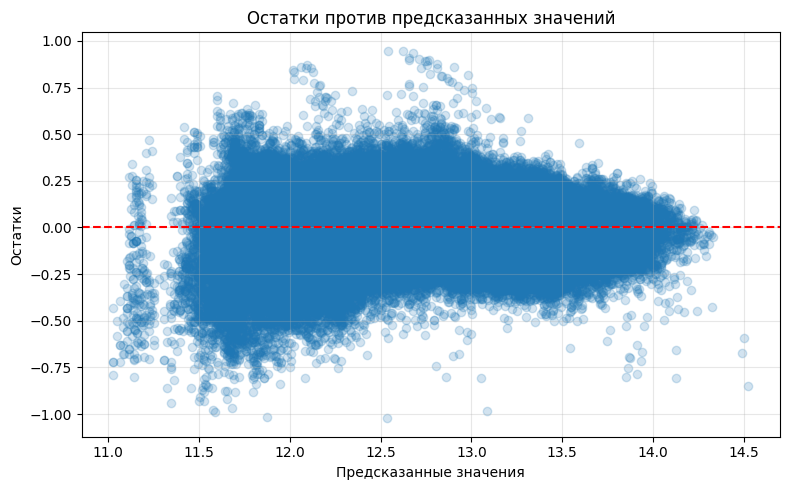

<Figure size 800x500 with 0 Axes>

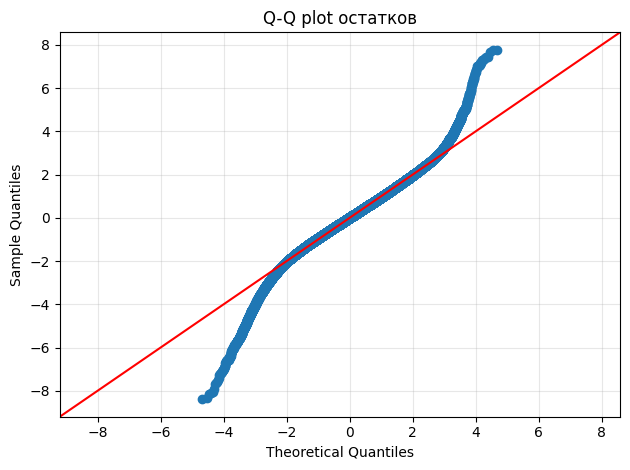

In [104]:
plt.figure(figsize=(8, 5))
plt.scatter(hedonic_loc_res.fittedvalues, hedonic_loc_res.resid, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки против предсказанных значений')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
qqplot(hedonic_loc_res.resid, line='45', fit=True)
plt.title('Q-Q plot остатков')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
train_pred = hedonic_loc_res.predict(train_loc)
test_pred = hedonic_loc_res.predict(test_loc)

In [106]:
loc_ols_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae': [
        mean_absolute_error(train_loc[target_col], train_pred),
        mean_absolute_error(test_loc[target_col], test_pred)
    ],
    'rmse': [
        root_mean_squared_error(train_loc[target_col], train_pred),
        root_mean_squared_error(test_loc[target_col], test_pred)
    ],
    'r2': [
        r2_score(train_loc[target_col], train_pred),
        r2_score(test_loc[target_col], test_pred)
    ]
})

display(loc_ols_metrics_df)

,sample,mae,rmse,r2
0,train,0.094519,0.121965,0.937898
1,test,0.094338,0.121606,0.938049


In [107]:
train_pred_price = np.exp(train_pred)
test_pred_price = np.exp(test_pred)

loc_ols_price_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae_price': [
        mean_absolute_error(np.exp(train_loc[target_col]), train_pred_price),
        mean_absolute_error(np.exp(test_loc[target_col]), test_pred_price)
    ],
    'rmse_price': [
        root_mean_squared_error(np.exp(train_loc[target_col]), train_pred_price),
        root_mean_squared_error(np.exp(test_loc[target_col]), test_pred_price)
    ],
    'r2_price_level': [
        r2_score(np.exp(train_loc[target_col]), train_pred_price),
        r2_score(np.exp(test_loc[target_col]), test_pred_price)
    ]
})

display(loc_ols_price_metrics_df)

,sample,mae_price,rmse_price,r2_price_level
0,train,32312.376369,44492.942306,0.936007
1,test,32220.196754,44273.808058,0.936143


In [108]:
loc_ols_price_metrics_df

,sample,mae_price,rmse_price,r2_price_level
0,train,32312.376369,44492.942306,0.936007
1,test,32220.196754,44273.808058,0.936143


## 1.3 Log-hedonic OLS + location + macro-params

In [121]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603532 entries, 0 to 603531
Data columns (total 75 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   resale_id                            603532 non-null  int64         
 1   transaction_date                     603532 non-null  datetime64[ns]
 2   x                                    603532 non-null  float64       
 3   y                                    603532 non-null  float64       
 4   max_floor_lvl                        603532 non-null  float64       
 5   year_completed                       603532 non-null  float64       
 6   commercial                           603532 non-null  float64       
 7   market_hawker                        603532 non-null  float64       
 8   miscellaneous                        603532 non-null  float64       
 9   multistorey_carpark                  603532 non-null  float64       
 

In [32]:
target_col = 'log_resale_price'

numeric_features_base = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    'flat_type',
    'town'
]

location_numeric_features = [
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km'
]

financial_features = [
    'bank_hdb_max_tenure_years',
    'bank_hdb_msr',
    'hdb_housing_loan_max_tenure_years',
    'hdb_housing_msr',
    'ltv_std_mean',
    'ltv_long_mean',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type'
]

macro_features = [
    'cpi_all_items',
    'sgs_2y_yield',
    'real_gdp_sa',
    'resident_population',
    'resident_unemployment_rate',
    'ulc_index_sa',
    'per_capita_gdp_real',
    'resident_households_hdb',
    'household_net_worth'
]

model_cols = (
    [target_col]
    + numeric_features_base
    + binary_building_features
    + categorical_features
    + location_numeric_features
    + financial_features
    + macro_features
)

missing_cols = [col for col in model_cols if col not in df_train.columns]
if missing_cols:
    raise ValueError(f'В данных отсутствуют колонки: {missing_cols}')

print('Всего переменных в полной модели:', len(model_cols))

Всего переменных в полной модели: 43


In [33]:
train_full_ols = df_train[model_cols].dropna().copy()
val_full_ols = df_val[model_cols].dropna().copy()
train_full_ols = pd.concat([train_full_ols, val_full_ols], ignore_index=True)

test_full_ols = df_test[model_cols].dropna().copy()

print('train:', train_full_ols.shape)
print('val:  ', val_full_ols.shape)
print('test: ', test_full_ols.shape)

train: (689751, 43)
val:   (86219, 43)
test:  (172438, 43)


In [37]:
all_numeric_features = (
    numeric_features_base
    + binary_building_features
    + location_numeric_features
    + financial_features
    + macro_features
)

diag_sample_n = min(150_000, len(train_full_ols))
train_vif_sample = train_full_ols[all_numeric_features].sample(
    n=diag_sample_n,
    random_state=42
).copy()

X_vif = sm.add_constant(train_vif_sample)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('vif', ascending=False).reset_index(drop=True)

print('VIF по полной числовой части модели:')
display(vif_df)

VIF по полной числовой части модели:


,variable,vif
0,const,15485.731255
1,resident_population,525.175482
2,real_gdp_sa,478.228492
3,resident_households_hdb,418.187711
4,ltv_long_mean,274.741682
5,hdb_housing_msr,258.785102
6,cpi_all_items,217.069502
7,household_net_worth,200.140457
8,bank_hdb_msr,170.062305
9,per_capita_gdp_real,162.754891


In [38]:
target_col = 'log_resale_price'

numeric_features_base = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    #'flat_type',
    'town'
]

location_numeric_features = [
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km'
]

financial_features = [
    # 'bank_hdb_max_tenure_years',
    # 'bank_hdb_msr',
    'hdb_housing_loan_max_tenure_years',
    'hdb_housing_msr',
    #'ltv_std_mean',
    # 'ltv_long_mean',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type'
]

macro_features = [
    'cpi_all_items',
    'sgs_2y_yield',
    'real_gdp_sa',
    #'resident_population',
    'resident_unemployment_rate',
    #'ulc_index_sa',
    #'per_capita_gdp_real',
    #'resident_households_hdb',
    #'household_net_worth'
]

model_cols = (
    [target_col]
    + numeric_features_base
    + binary_building_features
    + categorical_features
    + location_numeric_features
    + financial_features
    + macro_features
)

missing_cols = [col for col in model_cols if col not in df_train.columns]
if missing_cols:
    raise ValueError(f'В данных отсутствуют колонки: {missing_cols}')

print('Всего переменных в полной модели:', len(model_cols))

train_full_ols = df_train[model_cols].dropna().copy()
val_full_ols = df_val[model_cols].dropna().copy()
train_full_ols = pd.concat([train_full_ols, val_full_ols], ignore_index=True)

test_full_ols = df_test[model_cols].dropna().copy()

print('train:', train_full_ols.shape)
print('val:  ', val_full_ols.shape)
print('test: ', test_full_ols.shape)

all_numeric_features = (
    numeric_features_base
    + binary_building_features
    + location_numeric_features
    + financial_features
    + macro_features
)

diag_sample_n = min(150_000, len(train_full_ols))
train_vif_sample = train_full_ols[all_numeric_features].sample(
    n=diag_sample_n,
    random_state=42
).copy()

X_vif = sm.add_constant(train_vif_sample)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('vif', ascending=False).reset_index(drop=True)

print('VIF по полной числовой части модели:')
display(vif_df)

Всего переменных в полной модели: 33
train: (689751, 33)
val:   (86219, 33)
test:  (172438, 33)
VIF по полной числовой части модели:


,variable,vif
0,const,6515.252995
1,cpi_all_items,54.116628
2,real_gdp_sa,49.766934
3,hdb_housing_msr,20.780544
4,hdb_housing_loan_max_tenure_years,10.258169
5,hdb_ltv_by_flat_type,4.991946
6,cpf_oa_rate,4.616400
7,dist_to_raffles_place_m,3.744262
8,hawker_centre_count_1km,2.799269
9,remaining_lease_full_years,2.503333


In [39]:
target_col = 'log_resale_price'

numeric_features_base = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    #'flat_type',
    'town'
]

location_numeric_features = [
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km'
]

financial_features = [
    # 'bank_hdb_max_tenure_years',
    # 'bank_hdb_msr',
    #'hdb_housing_loan_max_tenure_years',
    'hdb_housing_msr',
    #'ltv_std_mean',
    # 'ltv_long_mean',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type'
]

macro_features = [
    'cpi_all_items',
    'sgs_2y_yield',
    #'real_gdp_sa',
    #'resident_population',
    'resident_unemployment_rate',
    #'ulc_index_sa',
    #'per_capita_gdp_real',
    #'resident_households_hdb',
    #'household_net_worth'
]

model_cols = (
    [target_col]
    + numeric_features_base
    + binary_building_features
    + categorical_features
    + location_numeric_features
    + financial_features
    + macro_features
)

missing_cols = [col for col in model_cols if col not in df_train.columns]
if missing_cols:
    raise ValueError(f'В данных отсутствуют колонки: {missing_cols}')

print('Всего переменных в полной модели:', len(model_cols))

train_full_ols = df_train[model_cols].dropna().copy()
val_full_ols = df_val[model_cols].dropna().copy()
train_full_ols = pd.concat([train_full_ols, val_full_ols], ignore_index=True)

test_full_ols = df_test[model_cols].dropna().copy()

print('train:', train_full_ols.shape)
print('val:  ', val_full_ols.shape)
print('test: ', test_full_ols.shape)

all_numeric_features = (
    numeric_features_base
    + binary_building_features
    + location_numeric_features
    + financial_features
    + macro_features
)

diag_sample_n = min(150_000, len(train_full_ols))
train_vif_sample = train_full_ols[all_numeric_features].sample(
    n=diag_sample_n,
    random_state=42
).copy()

X_vif = sm.add_constant(train_vif_sample)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('vif', ascending=False).reset_index(drop=True)

print('VIF по полной числовой части модели:')
display(vif_df)

Всего переменных в полной модели: 31
train: (689751, 31)
val:   (86219, 31)
test:  (172438, 31)
VIF по полной числовой части модели:


,variable,vif
0,const,5795.525082
1,cpi_all_items,13.198240
2,hdb_housing_msr,5.454256
3,hdb_ltv_by_flat_type,4.073432
4,dist_to_raffles_place_m,3.742606
5,hawker_centre_count_1km,2.798199
6,remaining_lease_full_years,2.462336
7,max_floor_lvl,2.300855
8,dist_nearest_hospital_m,2.091810
9,cpf_oa_rate,2.043043


In [40]:
target_col = 'log_resale_price'

numeric_features_base = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units'
]

binary_building_features = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion'
]

categorical_features = [
    #'flat_type',
    'town'
]

location_numeric_features = [
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km'
]

financial_features = [
    # 'bank_hdb_max_tenure_years',
    # 'bank_hdb_msr',
    #'hdb_housing_loan_max_tenure_years',
    #'hdb_housing_msr',
    #'ltv_std_mean',
    # 'ltv_long_mean',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type'
]

macro_features = [
    'cpi_all_items',
    'sgs_2y_yield',
    #'real_gdp_sa',
    #'resident_population',
    'resident_unemployment_rate',
    #'ulc_index_sa',
    #'per_capita_gdp_real',
    #'resident_households_hdb',
    #'household_net_worth'
]

model_cols = (
    [target_col]
    + numeric_features_base
    + binary_building_features
    + categorical_features
    + location_numeric_features
    + financial_features
    + macro_features
)

missing_cols = [col for col in model_cols if col not in df_train.columns]
if missing_cols:
    raise ValueError(f'В данных отсутствуют колонки: {missing_cols}')

print('Всего переменных в полной модели:', len(model_cols))

train_full_ols = df_train[model_cols].dropna().copy()
val_full_ols = df_val[model_cols].dropna().copy()
train_full_ols = pd.concat([train_full_ols, val_full_ols], ignore_index=True)

test_full_ols = df_test[model_cols].dropna().copy()

print('train:', train_full_ols.shape)
print('val:  ', val_full_ols.shape)
print('test: ', test_full_ols.shape)

all_numeric_features = (
    numeric_features_base
    + binary_building_features
    + location_numeric_features
    + financial_features
    + macro_features
)

diag_sample_n = min(150_000, len(train_full_ols))
train_vif_sample = train_full_ols[all_numeric_features].sample(
    n=diag_sample_n,
    random_state=42
).copy()

X_vif = sm.add_constant(train_vif_sample)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'vif': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('vif', ascending=False).reset_index(drop=True)

print('VIF по полной числовой части модели:')
display(vif_df)

Всего переменных в полной модели: 30
train: (689751, 30)
val:   (86219, 30)
test:  (172438, 30)
VIF по полной числовой части модели:


,variable,vif
0,const,3048.106854
1,cpi_all_items,5.359625
2,dist_to_raffles_place_m,3.742439
3,hdb_ltv_by_flat_type,3.527011
4,hawker_centre_count_1km,2.798123
5,remaining_lease_full_years,2.462335
6,max_floor_lvl,2.299390
7,dist_nearest_hospital_m,2.091809
8,secondary_school_count_1km,1.946728
9,dist_nearest_hawker_centre_m,1.863570


In [41]:
formula_hedonic_full = """
log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)
"""

print(formula_hedonic_full)


log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)



In [42]:
hedonic_full_model = smf.ols(formula=formula_hedonic_full, data=train_full_ols)
hedonic_full_res = hedonic_full_model.fit()

print(hedonic_full_res.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 1.420e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        00:37:28   Log-Likelihood:             3.6848e+05
No. Observations:              689751   AIC:                        -7.369e+05
Df Residuals:                  689697   BIC:                        -7.362e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [43]:
hedonic_full_res_hc3 = hedonic_full_res.get_robustcov_results(cov_type='HC3')

print(hedonic_full_res_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 1.546e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        00:37:40   Log-Likelihood:             3.6848e+05
No. Observations:              689751   AIC:                        -7.369e+05
Df Residuals:                  689697   BIC:                        -7.362e+05
Df Model:                          53                                         
Covariance Type:                  HC3                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [137]:
bp_test = het_breuschpagan(hedonic_full_res.resid, hedonic_full_res.model.exog)

bp_results = pd.Series(
    bp_test,
    index=['LM stat', 'LM p-value', 'F stat', 'F p-value']
)

print('Breusch-Pagan test:')
display(bp_results)

Breusch-Pagan test:


LM stat       70693.540481
LM p-value        0.000000
F stat         1486.042529
F p-value         0.000000
dtype: float64

In [138]:
reset_res = linear_reset(
    hedonic_full_res,
    power=2,
    use_f=True,
    cov_type='HC3'
)

print('RESET test:')
print(reset_res)

RESET test:
<F test: F=45894.23529296204, p=0.0, df_denom=6.9e+05, df_num=1>


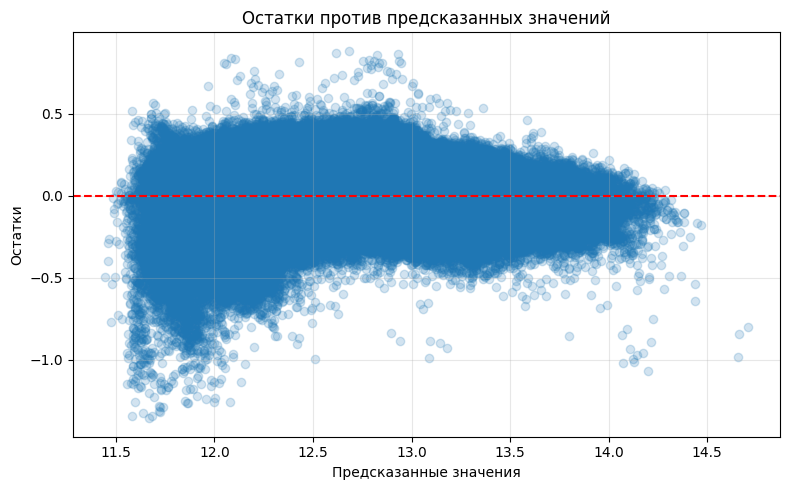

<Figure size 800x500 with 0 Axes>

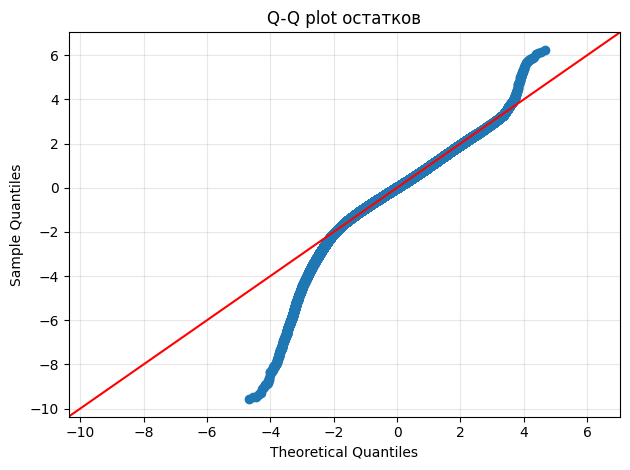

In [139]:
plt.figure(figsize=(8, 5))
plt.scatter(hedonic_full_res.fittedvalues, hedonic_full_res.resid, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки против предсказанных значений')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
qqplot(hedonic_full_res.resid, line='45', fit=True)
plt.title('Q-Q plot остатков')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [140]:
train_pred = hedonic_full_res.predict(train_full_ols)
test_pred = hedonic_full_res.predict(test_full_ols)

In [141]:
full_ols_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae': [
        mean_absolute_error(train_full_ols[target_col], train_pred),
        mean_absolute_error(test_full_ols[target_col], test_pred)
    ],
    'rmse': [
        root_mean_squared_error(train_full_ols[target_col], train_pred),
        root_mean_squared_error(test_full_ols[target_col], test_pred)
    ],
    'r2': [
        r2_score(train_full_ols[target_col], train_pred),
        r2_score(test_full_ols[target_col], test_pred)
    ]
})

display(full_ols_metrics_df)

,sample,mae,rmse,r2
0,train,0.108404,0.141825,0.916027
1,test,0.108168,0.141488,0.916135


In [142]:
train_pred_price = np.exp(train_pred)
test_pred_price = np.exp(test_pred)

full_ols_price_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae_price': [
        mean_absolute_error(np.exp(train_full_ols[target_col]), train_pred_price),
        mean_absolute_error(np.exp(test_full_ols[target_col]), test_pred_price)
    ],
    'rmse_price': [
        root_mean_squared_error(np.exp(train_full_ols[target_col]), train_pred_price),
        root_mean_squared_error(np.exp(test_full_ols[target_col]), test_pred_price)
    ],
    'r2_price_level': [
        r2_score(np.exp(train_full_ols[target_col]), train_pred_price),
        r2_score(np.exp(test_full_ols[target_col]), test_pred_price)
    ]
})

display(full_ols_price_metrics_df)

,sample,mae_price,rmse_price,r2_price_level
0,train,36239.818591,49582.774010,0.920528
1,test,36100.509622,49281.844556,0.920880


## 1.4 FGLS все параметры

In [8]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

In [9]:
target_col = 'log_resale_price'

model_cols = [
    target_col,
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units',
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type',
    'cpi_all_items',
    'sgs_2y_yield',
    'resident_unemployment_rate',
    'town'
]

train_fgls = df_train[model_cols].dropna().copy()
val_fgls = df_val[model_cols].dropna().copy()
train_fgls = pd.concat([train_fgls, val_fgls], ignore_index=True)

test_fgls = df_test[model_cols].dropna().copy()

print('train:', train_fgls.shape)
print('val:  ', val_fgls.shape)
print('test: ', test_fgls.shape)

train: (689751, 30)
val:   (86219, 30)
test:  (172438, 30)


In [10]:
formula_fgls_mean = """
log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)
"""

print(formula_fgls_mean)


log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)



In [11]:
ols_start_model = smf.ols(formula=formula_fgls_mean, data=train_fgls)
ols_start_res = ols_start_model.fit()

print(ols_start_res.summary())

                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 1.420e+05
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:19:58   Log-Likelihood:             3.6848e+05
No. Observations:              689751   AIC:                        -7.369e+05
Df Residuals:                  689697   BIC:                        -7.362e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [12]:
eps = 1e-8

train_fgls['fitted_ols'] = ols_start_res.fittedvalues
train_fgls['resid_ols'] = ols_start_res.resid
train_fgls['log_resid_sq'] = np.log(np.square(train_fgls['resid_ols']) + eps)

In [13]:
formula_var_model = """
log_resid_sq ~
fitted_ols +
I(fitted_ols ** 2)
"""

var_model = smf.ols(formula=formula_var_model, data=train_fgls)
var_res = var_model.fit()

print(var_res.summary())

                            OLS Regression Results                            
Dep. Variable:           log_resid_sq   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     5582.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:20:18   Log-Likelihood:            -1.5378e+06
No. Observations:              689751   AIC:                         3.076e+06
Df Residuals:                  689748   BIC:                         3.076e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             69.4377      1

In [14]:
train_fgls['log_sigma2_hat'] = var_res.predict(train_fgls)
train_fgls['sigma2_hat'] = np.exp(train_fgls['log_sigma2_hat']).clip(lower=eps)
train_fgls['fgls_weight'] = 1.0 / train_fgls['sigma2_hat']

fgls_model = smf.wls(
    formula=formula_fgls_mean,
    data=train_fgls,
    weights=train_fgls['fgls_weight']
)
fgls_res = fgls_model.fit()

print(fgls_res.summary())

                            WLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.915
Model:                            WLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                 1.394e+05
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:20:54   Log-Likelihood:             3.9698e+05
No. Observations:              689751   AIC:                        -7.938e+05
Df Residuals:                  689697   BIC:                        -7.932e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [15]:
train_fgls['fitted_fgls_1'] = fgls_res.fittedvalues
train_fgls['resid_fgls_1'] = fgls_res.resid
train_fgls['log_resid_sq_fgls_1'] = np.log(np.square(train_fgls['resid_fgls_1']) + eps)

formula_var_model_2 = """
log_resid_sq_fgls_1 ~
fitted_fgls_1 +
I(fitted_fgls_1 ** 2)
"""

var_model_2 = smf.ols(formula=formula_var_model_2, data=train_fgls)
var_res_2 = var_model_2.fit()

train_fgls['log_sigma2_hat_2'] = var_res_2.predict(train_fgls)
train_fgls['sigma2_hat_2'] = np.exp(train_fgls['log_sigma2_hat_2']).clip(lower=eps)
train_fgls['fgls_weight_2'] = 1.0 / train_fgls['sigma2_hat_2']

fgls_model_2 = smf.wls(
    formula=formula_fgls_mean,
    data=train_fgls,
    weights=train_fgls['fgls_weight_2']
)
fgls_res_2 = fgls_model_2.fit()

print(fgls_res_2.summary())

                            WLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.916
Model:                            WLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 1.417e+05
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:21:24   Log-Likelihood:             3.9851e+05
No. Observations:              689751   AIC:                        -7.969e+05
Df Residuals:                  689697   BIC:                        -7.963e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [16]:
fgls_res_hc3 = fgls_res_2.get_robustcov_results(cov_type='HC3')
print(fgls_res_hc3.summary())

                            WLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.916
Model:                            WLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 1.594e+05
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:22:55   Log-Likelihood:             3.9851e+05
No. Observations:              689751   AIC:                        -7.969e+05
Df Residuals:                  689697   BIC:                        -7.963e+05
Df Model:                          53                                         
Covariance Type:                  HC3                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [17]:
coef_compare = pd.DataFrame({
    'ols_start': ols_start_res.params,
    'fgls_1': fgls_res.params,
    'fgls_2': fgls_res_2.params
})

coef_compare['diff_fgls2_vs_fgls1'] = coef_compare['fgls_2'] - coef_compare['fgls_1']
coef_compare['abs_diff_fgls2_vs_fgls1'] = coef_compare['diff_fgls2_vs_fgls1'].abs()

display(coef_compare.sort_values('abs_diff_fgls2_vs_fgls1', ascending=False).head(20))

,ols_start,fgls_1,fgls_2,diff_fgls2_vs_fgls1,abs_diff_fgls2_vs_fgls1
cpf_oa_rate,3.514947,4.252609,4.382838,0.130229,0.130229
Intercept,10.236876,10.515388,10.563111,0.047723,0.047723
C(town)[T.WOODLANDS],-0.176814,-0.186450,-0.190439,-0.003988,0.003988
C(town)[T.CENTRAL AREA],-0.137288,-0.143768,-0.147534,-0.003766,0.003766
C(town)[T.HOUGANG],-0.037568,-0.047198,-0.050955,-0.003757,0.003757
market_hawker,-0.307606,-0.296065,-0.299607,-0.003543,0.003543
C(town)[T.TAMPINES],0.010078,0.003366,0.000566,-0.002799,0.002799
np.log1p(dist_to_raffles_place_m),-0.084275,-0.091314,-0.093854,-0.002540,0.002540
C(town)[T.KALLANG/WHAMPOA],-0.053498,-0.055933,-0.058311,-0.002379,0.002379
C(town)[T.SEMBAWANG],-0.187470,-0.192701,-0.194951,-0.002250,0.002250


In [18]:
bp_test_fgls = het_breuschpagan(fgls_res_2.resid, fgls_res_2.model.exog)

bp_results_fgls = pd.Series(
    bp_test_fgls,
    index=['LM stat', 'LM p-value', 'F stat', 'F p-value']
)

print('Breusch-Pagan test after FGLS:')
display(bp_results_fgls)

Breusch-Pagan test after FGLS:


LM stat       84424.847463
LM p-value        0.000000
F stat         1814.944355
F p-value         0.000000
dtype: float64

In [19]:
reset_res_fgls = linear_reset(
    fgls_res_2,
    power=2,
    use_f=True,
    cov_type='HC3'
)

print('RESET test after FGLS:')
print(reset_res_fgls)

RESET test after FGLS:
<F test: F=40158.72157089235, p=0.0, df_denom=6.9e+05, df_num=1>


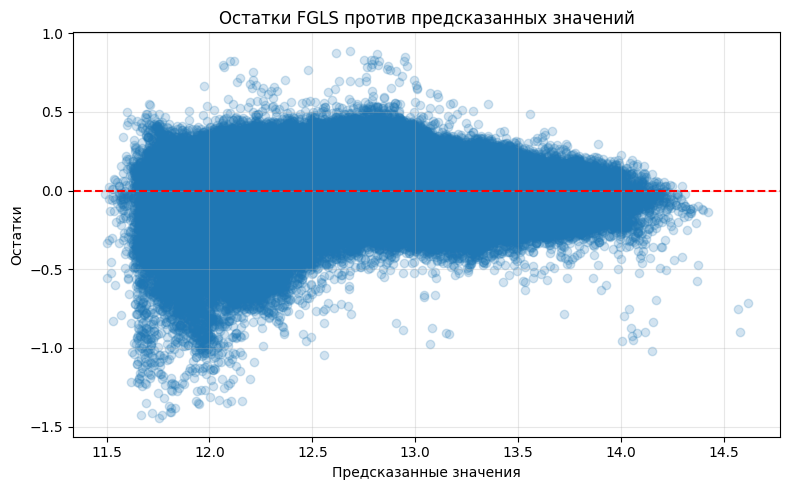

<Figure size 800x500 with 0 Axes>

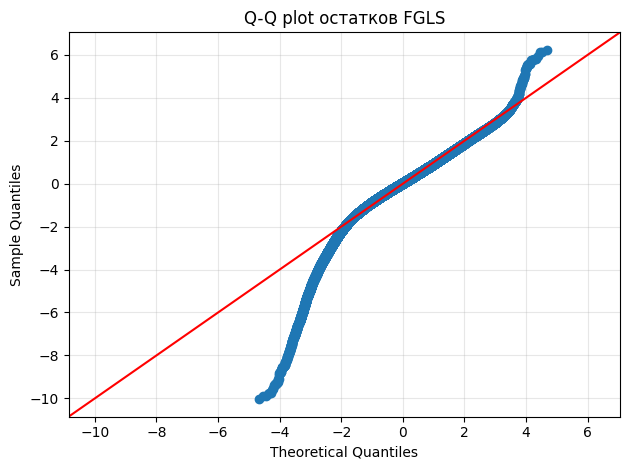

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(fgls_res_2.fittedvalues, fgls_res_2.resid, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остатки FGLS против предсказанных значений')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
qqplot(fgls_res_2.resid, line='45', fit=True)
plt.title('Q-Q plot остатков FGLS')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
train_pred_fgls = fgls_res_2.predict(train_fgls)
test_pred_fgls = fgls_res_2.predict(test_fgls)

In [22]:
fgls_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae': [
        mean_absolute_error(train_fgls[target_col], train_pred_fgls),
        mean_absolute_error(test_fgls[target_col], test_pred_fgls)
    ],
    'rmse': [
        root_mean_squared_error(train_fgls[target_col], train_pred_fgls),
        root_mean_squared_error(test_fgls[target_col], test_pred_fgls)
    ],
    'r2': [
        r2_score(train_fgls[target_col], train_pred_fgls),
        r2_score(test_fgls[target_col], test_pred_fgls)
    ]
})

display(fgls_metrics_df)

,sample,mae,rmse,r2
0,train,0.107736,0.143636,0.913869
1,test,0.107468,0.143261,0.914020


In [23]:
train_pred_price_fgls = np.exp(train_pred_fgls)
test_pred_price_fgls = np.exp(test_pred_fgls)

fgls_price_metrics_df = pd.DataFrame({
    'sample': ['train', 'test'],
    'mae_price': [
        mean_absolute_error(np.exp(train_fgls[target_col]), train_pred_price_fgls),
        mean_absolute_error(np.exp(test_fgls[target_col]), test_pred_price_fgls)
    ],
    'rmse_price': [
        root_mean_squared_error(np.exp(train_fgls[target_col]), train_pred_price_fgls),
        root_mean_squared_error(np.exp(test_fgls[target_col]), test_pred_price_fgls)
    ],
    'r2_price_level': [
        r2_score(np.exp(train_fgls[target_col]), train_pred_price_fgls),
        r2_score(np.exp(test_fgls[target_col]), test_pred_price_fgls)
    ]
})

display(fgls_price_metrics_df)

,sample,mae_price,rmse_price,r2_price_level
0,train,34977.230485,47149.868974,0.928136
1,test,34832.872622,46842.077776,0.928520


## 1.5 Quantile regression

In [24]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_pinball_loss

target_col = 'log_resale_price'

model_cols = [
    target_col,
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units',
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',
    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type',
    'cpi_all_items',
    'sgs_2y_yield',
    'resident_unemployment_rate',
    'town'
]

train_qr = df_train[model_cols].dropna().copy()
val_qr = df_val[model_cols].dropna().copy()
train_qr = pd.concat([train_qr, val_qr], ignore_index=True)

test_qr = df_test[model_cols].dropna().copy()

print('train:', train_qr.shape)
print('test: ', test_qr.shape)

train: (689751, 30)
test:  (172438, 30)


In [17]:
formula_qr = """
log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)
"""

print(formula_qr)


log_resale_price ~
floor_area_sqm +
remaining_lease_full_years +
floor_mean +
max_floor_lvl +
total_dwelling_units +
commercial +
market_hawker +
miscellaneous +
multistorey_carpark +
precinct_pavilion +
np.log1p(dist_mrt_exit_m) +
mrt_station_count_1km +
np.log1p(dist_to_raffles_place_m) +
np.log1p(dist_nearest_primary_school_m) +
primary_school_count_1km +
np.log1p(dist_nearest_secondary_school_m) +
secondary_school_count_1km +
np.log1p(dist_nearest_park_m) +
park_count_1km +
np.log1p(dist_nearest_hospital_m) +
hospital_count_1km +
np.log1p(dist_nearest_hawker_centre_m) +
hawker_centre_count_1km +
cpf_oa_rate +
hdb_ltv_by_flat_type +
cpi_all_items +
sgs_2y_yield +
resident_unemployment_rate +
C(town)



In [18]:
quantiles = [0.25, 0.50, 0.75]

qr_model = smf.quantreg(formula_qr, train_qr)

qr_results = {}

for q in quantiles:
    res = qr_model.fit(
        q=q,
        vcov='robust',
        max_iter=5000,
        p_tol=1e-6
    )
    qr_results[q] = res
    print(f'\n===== Quantile {q:.2f} =====')
    print(res.summary())


===== Quantile 0.25 =====
                         QuantReg Regression Results                          
Dep. Variable:       log_resale_price   Pseudo R-squared:               0.7301
Model:                       QuantReg   Bandwidth:                    0.006345
Method:                 Least Squares   Sparsity:                       0.3861
Date:                Tue, 26 May 2026   No. Observations:               689751
Time:                        01:49:06   Df Residuals:                   689697
                                        Df Model:                           53
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    10.2299      0.023    436.280      0.000      10.184      10.276
C(town)[T.BEDOK]                             -0.0092      0.001     -7.525      0.000     

In [27]:
coef_table = pd.DataFrame()
se_table = pd.DataFrame()
pval_table = pd.DataFrame()

for q, res in qr_results.items():
    coef_table[f'coef_q{q:.2f}'] = res.params
    se_table[f'se_q{q:.2f}'] = res.bse
    pval_table[f'pval_q{q:.2f}'] = res.pvalues

qr_coef_summary = pd.concat([coef_table, se_table, pval_table], axis=1)

display(qr_coef_summary)

,coef_q0.25,coef_q0.50,coef_q0.75,se_q0.25,se_q0.50,se_q0.75,pval_q0.25,pval_q0.50,pval_q0.75
Intercept,10.229938,10.694925,10.974279,0.023448,0.021456,0.022901,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.BEDOK],-0.009190,-0.012958,-0.017855,0.001221,0.001145,0.001236,5.243693e-14,1.141951e-29,2.867959e-47
C(town)[T.BISHAN],0.097065,0.092432,0.087461,0.001791,0.001642,0.001746,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.BUKIT BATOK],-0.138177,-0.127187,-0.124132,0.001731,0.001601,0.001708,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.BUKIT MERAH],-0.050394,-0.014093,0.005732,0.002599,0.002447,0.002631,9.576161e-84,8.401020e-09,2.932693e-02
C(town)[T.BUKIT PANJANG],-0.123393,-0.118486,-0.118810,0.001909,0.001776,0.001914,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.BUKIT TIMAH],0.259858,0.266257,0.258689,0.004095,0.003767,0.004032,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.CENTRAL AREA],-0.191594,-0.151201,-0.100723,0.004646,0.004193,0.004353,0.000000e+00,1.543358e-284,2.132909e-118
C(town)[T.CHOA CHU KANG],-0.189526,-0.173896,-0.163814,0.002000,0.001855,0.001994,0.000000e+00,0.000000e+00,0.000000e+00
C(town)[T.CLEMENTI],0.049124,0.061319,0.075415,0.001620,0.001490,0.001589,9.497556e-202,0.000000e+00,0.000000e+00


In [28]:
model_info_rows = []

for q, res in qr_results.items():
    model_info_rows.append({
        'quantile': q,
        'pseudo_r2': getattr(res, 'prsquared', np.nan),
        'iterations': getattr(res, 'iterations', np.nan),
        'nobs': getattr(res, 'nobs', np.nan)
    })

qr_model_info = pd.DataFrame(model_info_rows)
display(qr_model_info)

conf_int_dict = {q: res.conf_int() for q, res in qr_results.items()}

,quantile,pseudo_r2,iterations,nobs
0,0.25,0.730070,149,689751.0
1,0.50,0.728980,230,689751.0
2,0.75,0.724057,204,689751.0


In [29]:
train_pred_dict = {}
test_pred_dict = {}

for q, res in qr_results.items():
    train_pred_dict[q] = res.predict(train_qr)
    test_pred_dict[q] = res.predict(test_qr)

In [30]:
metrics_rows = []

for q in quantiles:
    y_train = train_qr[target_col]
    y_test = test_qr[target_col]

    pred_train = train_pred_dict[q]
    pred_test = test_pred_dict[q]

    metrics_rows.append({
        'quantile': q,
        'sample': 'train',
        'pinball_loss': mean_pinball_loss(y_train, pred_train, alpha=q),
        'mae': mean_absolute_error(y_train, pred_train),
        'rmse': root_mean_squared_error(y_train, pred_train),
        'r2': r2_score(y_train, pred_train)
    })

    metrics_rows.append({
        'quantile': q,
        'sample': 'test',
        'pinball_loss': mean_pinball_loss(y_test, pred_test, alpha=q),
        'mae': mean_absolute_error(y_test, pred_test),
        'rmse': root_mean_squared_error(y_test, pred_test),
        'r2': r2_score(y_test, pred_test)
    })

qr_metrics_df = pd.DataFrame(metrics_rows)
display(qr_metrics_df)

,quantile,sample,pinball_loss,mae,rmse,r2
0,0.25,train,0.043641,0.131694,0.168935,0.880855
1,0.25,test,0.043598,0.131844,0.168988,0.880367
2,0.50,train,0.053754,0.107507,0.143241,0.914342
3,0.50,test,0.053631,0.107261,0.142875,0.914483
4,0.75,train,0.041964,0.130520,0.174213,0.873294
5,0.75,test,0.041803,0.129904,0.173524,0.873858


In [31]:
price_metrics_rows = []

for q in quantiles:
    y_train_price = np.exp(train_qr[target_col])
    y_test_price = np.exp(test_qr[target_col])

    pred_train_price = np.exp(train_pred_dict[q])
    pred_test_price = np.exp(test_pred_dict[q])

    price_metrics_rows.append({
        'quantile': q,
        'sample': 'train',
        'mae_price': mean_absolute_error(y_train_price, pred_train_price),
        'rmse_price': root_mean_squared_error(y_train_price, pred_train_price),
        'r2_price_level': r2_score(y_train_price, pred_train_price)
    })

    price_metrics_rows.append({
        'quantile': q,
        'sample': 'test',
        'mae_price': mean_absolute_error(y_test_price, pred_test_price),
        'rmse_price': root_mean_squared_error(y_test_price, pred_test_price),
        'r2_price_level': r2_score(y_test_price, pred_test_price)
    })

qr_price_metrics_df = pd.DataFrame(price_metrics_rows)
display(qr_price_metrics_df)

,quantile,sample,mae_price,rmse_price,r2_price_level
0,0.25,train,42580.891193,57411.224282,0.893452
1,0.25,test,42540.070927,57219.119858,0.893342
2,0.50,train,35144.376556,47677.825404,0.926518
3,0.50,test,35007.333540,47378.604669,0.926873
4,0.75,train,43321.230057,57617.962032,0.892684
5,0.75,test,43082.319258,57272.228742,0.893144


In [32]:
coverage_rows = []

for q in quantiles:
    train_coverage = (train_qr[target_col] <= train_pred_dict[q]).mean()
    test_coverage = (test_qr[target_col] <= test_pred_dict[q]).mean()

    coverage_rows.append({
        'quantile': q,
        'sample': 'train',
        'target_coverage': q,
        'actual_coverage': train_coverage,
        'abs_diff': abs(train_coverage - q)
    })

    coverage_rows.append({
        'quantile': q,
        'sample': 'test',
        'target_coverage': q,
        'actual_coverage': test_coverage,
        'abs_diff': abs(test_coverage - q)
    })

qr_coverage_df = pd.DataFrame(coverage_rows)
display(qr_coverage_df)

,quantile,sample,target_coverage,actual_coverage,abs_diff
0,0.25,train,0.25,0.250022,2.210943e-05
1,0.25,test,0.25,0.248153,1.847041e-03
2,0.50,train,0.50,0.500001,7.248993e-07
3,0.50,test,0.50,0.498249,1.751354e-03
4,0.75,train,0.75,0.749985,1.486044e-05
5,0.75,test,0.75,0.749661,3.392524e-04


In [33]:
train_crossing_df = pd.DataFrame({
    'q25': train_pred_dict[0.25],
    'q50': train_pred_dict[0.50],
    'q75': train_pred_dict[0.75]
})

test_crossing_df = pd.DataFrame({
    'q25': test_pred_dict[0.25],
    'q50': test_pred_dict[0.50],
    'q75': test_pred_dict[0.75]
})

train_crossing_stats = pd.Series({
    'train_q25_gt_q50_share': (train_crossing_df['q25'] > train_crossing_df['q50']).mean(),
    'train_q50_gt_q75_share': (train_crossing_df['q50'] > train_crossing_df['q75']).mean(),
    'train_q25_gt_q75_share': (train_crossing_df['q25'] > train_crossing_df['q75']).mean()
})

test_crossing_stats = pd.Series({
    'test_q25_gt_q50_share': (test_crossing_df['q25'] > test_crossing_df['q50']).mean(),
    'test_q50_gt_q75_share': (test_crossing_df['q50'] > test_crossing_df['q75']).mean(),
    'test_q25_gt_q75_share': (test_crossing_df['q25'] > test_crossing_df['q75']).mean()
})

display(train_crossing_stats)
display(test_crossing_stats)

train_q25_gt_q50_share    0.0
train_q50_gt_q75_share    0.0
train_q25_gt_q75_share    0.0
dtype: float64

test_q25_gt_q50_share    0.0
test_q50_gt_q75_share    0.0
test_q25_gt_q75_share    0.0
dtype: float64

In [34]:
selected_params = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'np.log1p(dist_mrt_exit_m)',
    'np.log1p(dist_to_raffles_place_m)',
    'cpf_oa_rate',
    'hdb_ltv_by_flat_type',
    'cpi_all_items',
    'sgs_2y_yield',
    'resident_unemployment_rate'
]

coef_compare_rows = []

for param in selected_params:
    row = {'parameter': param}
    for q, res in qr_results.items():
        row[f'coef_q{q:.2f}'] = res.params.get(param, np.nan)
        row[f'pval_q{q:.2f}'] = res.pvalues.get(param, np.nan)
    coef_compare_rows.append(row)

coef_compare_df = pd.DataFrame(coef_compare_rows)
display(coef_compare_df) 

,parameter,coef_q0.25,pval_q0.25,coef_q0.50,pval_q0.50,coef_q0.75,pval_q0.75
0,floor_area_sqm,0.010515,0.000000e+00,0.010404,0.0,0.010417,0.0
1,remaining_lease_full_years,0.009532,0.000000e+00,0.008928,0.0,0.008526,0.0
2,np.log1p(dist_mrt_exit_m),-0.056219,0.000000e+00,-0.054972,0.0,-0.053152,0.0
3,np.log1p(dist_to_raffles_place_m),-0.107281,0.000000e+00,-0.096565,0.0,-0.085128,0.0
4,cpf_oa_rate,2.466724,0.000000e+00,4.202537,0.0,5.423088,0.0
5,hdb_ltv_by_flat_type,-0.001508,9.636670e-80,-0.003842,0.0,-0.005127,0.0
6,cpi_all_items,0.029759,0.000000e+00,0.027595,0.0,0.025942,0.0
7,sgs_2y_yield,-0.044524,0.000000e+00,-0.054022,0.0,-0.059704,0.0
8,resident_unemployment_rate,-0.023202,0.000000e+00,-0.034934,0.0,-0.041534,0.0


## 2. Модели машинного обучения

## 2.1 Random Forest

In [15]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
print("',\n'".join(col for col in df_train.columns))

resale_id',
'transaction_date',
'x',
'y',
'max_floor_lvl',
'year_completed',
'commercial',
'market_hawker',
'miscellaneous',
'multistorey_carpark',
'precinct_pavilion',
'bldg_contract_town',
'total_dwelling_units',
'onemap_status',
'dist_mrt_exit_m',
'mrt_station_count_1km',
'walk_time_to_nearest_mrt_exit_min',
'walk_distance_to_nearest_mrt_exit_m',
'dist_to_raffles_place_m',
'dist_nearest_primary_school_m',
'primary_school_count_1km',
'dist_nearest_secondary_school_m',
'secondary_school_count_1km',
'dist_nearest_park_m',
'park_count_1km',
'dist_nearest_hospital_m',
'hospital_count_1km',
'nearest_hospital_type',
'nearest_hospital_category',
'dist_nearest_hawker_centre_m',
'hawker_centre_count_1km',
'bank_hdb_max_tenure_years',
'bank_hdb_msr',
'hdb_housing_loan_max_tenure_years',
'hdb_housing_msr',
'ltv_first_std',
'ltv_second_std',
'ltv_third_plus_std',
'ltv_non_individual_std',
'ltv_first_long',
'ltv_second_long',
'ltv_third_plus_long',
'ltv_any_existing_std',
'ltv_any_existing_long',

In [16]:
target_col = 'log_resale_price'

numeric_candidate_features = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units',

    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',

    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km',

    'cpf_oa_rate',
    'hdb_housing_msr',
    'hdb_housing_loan_max_tenure_years',
    'hdb_ltv_by_flat_type',
    # 'bank_hdb_max_tenure_years',
    # 'bank_hdb_msr',
    # 'hdb_housing_loan_max_tenure_years',
    # 'hdb_housing_msr',
    # 'ltv_first_std',
    # 'ltv_second_std',
    # 'ltv_third_plus_std',
    # 'ltv_non_individual_std',
    # 'ltv_first_long',
    # 'ltv_second_long',
    # 'ltv_third_plus_long',
    # 'ltv_any_existing_std',
    # 'ltv_any_existing_long',
    # 'cpf_oa_rate',
    # 'hdb_ltv_1room',
    # 'hdb_ltv_2room',
    # 'hdb_ltv_3room',
    # 'hdb_ltv_4room',
    # 'hdb_ltv_5room',
    # 'hdb_ltv_exec',
    # 'hdb_ltv_others',
    

    # 'cpi_all_items',
    # 'sgs_2y_yield',
    # 'resident_unemployment_rate'
    
    'cpi_all_items',
    'sgs_2y_yield',
    #'real_gdp_sa',
    #'resident_population',
    'resident_unemployment_rate',
    'ulc_index_sa',
    'per_capita_gdp_real',
    'resident_households_hdb',
    'household_net_worth'
]

categorical_candidate_features = [
    'town',
    'flat_type',
    #'flat_model',
    #'nearest_hospital_type',
    #'nearest_hospital_category'
]

all_candidate_features = numeric_candidate_features + categorical_candidate_features

present_features = [col for col in all_candidate_features if col in df_train.columns]

print('Всего кандидатов, найденных в df_train:', len(present_features))
print(present_features)

Всего кандидатов, найденных в df_train: 36
['floor_area_sqm', 'remaining_lease_full_years', 'floor_mean', 'max_floor_lvl', 'total_dwelling_units', 'commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'dist_mrt_exit_m', 'mrt_station_count_1km', 'dist_to_raffles_place_m', 'dist_nearest_primary_school_m', 'primary_school_count_1km', 'dist_nearest_secondary_school_m', 'secondary_school_count_1km', 'dist_nearest_park_m', 'park_count_1km', 'dist_nearest_hospital_m', 'hospital_count_1km', 'dist_nearest_hawker_centre_m', 'hawker_centre_count_1km', 'cpf_oa_rate', 'hdb_housing_msr', 'hdb_housing_loan_max_tenure_years', 'hdb_ltv_by_flat_type', 'cpi_all_items', 'sgs_2y_yield', 'resident_unemployment_rate', 'ulc_index_sa', 'per_capita_gdp_real', 'resident_households_hdb', 'household_net_worth', 'town', 'flat_type']


In [17]:
def keep_nonconstant_features(df, features):
    kept = []
    dropped = []

    for col in features:
        nunique = df[col].nunique(dropna=False)
        if nunique <= 1:
            dropped.append(col)
        else:
            kept.append(col)

    return kept, dropped

numeric_present = [col for col in numeric_candidate_features if col in present_features]
categorical_present = [col for col in categorical_candidate_features if col in present_features]

numeric_nonconst, numeric_const_dropped = keep_nonconstant_features(df_train, numeric_present)
categorical_nonconst, categorical_const_dropped = keep_nonconstant_features(df_train, categorical_present)

print('Удалены как константные numeric:', numeric_const_dropped)
print('Удалены как константные categorical:', categorical_const_dropped)

Удалены как константные numeric: []
Удалены как константные categorical: []


In [18]:
def greedy_corr_prune(df, ordered_numeric_features, corr_threshold=0.98):
    selected = []
    dropped = []

    for col in ordered_numeric_features:
        if len(selected) == 0:
            selected.append(col)
            continue

        corr_with_selected = df[selected + [col]].corr(numeric_only=True).loc[col, selected].abs()
        max_corr = corr_with_selected.max()

        if pd.isna(max_corr) or max_corr < corr_threshold:
            selected.append(col)
        else:
            drop_against = corr_with_selected.idxmax()
            dropped.append((col, drop_against, max_corr))

    return selected, dropped

numeric_selected, numeric_corr_dropped = greedy_corr_prune(
    df_train,
    numeric_nonconst,
    corr_threshold=0.98
)

print('Удалены как почти дублирующиеся numeric-признаки:')
for item in numeric_corr_dropped:
    print(item)

print()
print('Итоговые numeric-признаки:')
print(numeric_selected)

print()
print('Итоговые categorical-признаки:')
print(categorical_nonconst)

Удалены как почти дублирующиеся numeric-признаки:

Итоговые numeric-признаки:
['floor_area_sqm', 'remaining_lease_full_years', 'floor_mean', 'max_floor_lvl', 'total_dwelling_units', 'commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'dist_mrt_exit_m', 'mrt_station_count_1km', 'dist_to_raffles_place_m', 'dist_nearest_primary_school_m', 'primary_school_count_1km', 'dist_nearest_secondary_school_m', 'secondary_school_count_1km', 'dist_nearest_park_m', 'park_count_1km', 'dist_nearest_hospital_m', 'hospital_count_1km', 'dist_nearest_hawker_centre_m', 'hawker_centre_count_1km', 'cpf_oa_rate', 'hdb_housing_msr', 'hdb_housing_loan_max_tenure_years', 'hdb_ltv_by_flat_type', 'cpi_all_items', 'sgs_2y_yield', 'resident_unemployment_rate', 'ulc_index_sa', 'per_capita_gdp_real', 'resident_households_hdb', 'household_net_worth']

Итоговые categorical-признаки:
['town', 'flat_type']


In [19]:
selected_features = numeric_selected + categorical_nonconst

print('Финальный список признаков:')
print(selected_features)
print()
print('Всего признаков до one-hot:', len(selected_features))

Финальный список признаков:
['floor_area_sqm', 'remaining_lease_full_years', 'floor_mean', 'max_floor_lvl', 'total_dwelling_units', 'commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'dist_mrt_exit_m', 'mrt_station_count_1km', 'dist_to_raffles_place_m', 'dist_nearest_primary_school_m', 'primary_school_count_1km', 'dist_nearest_secondary_school_m', 'secondary_school_count_1km', 'dist_nearest_park_m', 'park_count_1km', 'dist_nearest_hospital_m', 'hospital_count_1km', 'dist_nearest_hawker_centre_m', 'hawker_centre_count_1km', 'cpf_oa_rate', 'hdb_housing_msr', 'hdb_housing_loan_max_tenure_years', 'hdb_ltv_by_flat_type', 'cpi_all_items', 'sgs_2y_yield', 'resident_unemployment_rate', 'ulc_index_sa', 'per_capita_gdp_real', 'resident_households_hdb', 'household_net_worth', 'town', 'flat_type']

Всего признаков до one-hot: 36


In [20]:
X_train = df_train[selected_features].copy()
y_train = df_train[target_col].copy()

X_val = df_val[selected_features].copy()
y_val = df_val[target_col].copy()

X_test = df_test[selected_features].copy()
y_test = df_test[target_col].copy()

print('Shapes:')
print('X_train:', X_train.shape)
print('X_val:  ', X_val.shape)
print('X_test: ', X_test.shape)

Shapes:
X_train: (603532, 36)
X_val:   (86219, 36)
X_test:  (172438, 36)


In [21]:
numeric_features_final = [col for col in selected_features if col in numeric_selected]
categorical_features_final = [col for col in selected_features if col in categorical_nonconst]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features_final),
    ('cat', categorical_transformer, categorical_features_final)
])

In [22]:
def calc_regression_metrics(y_true_log, y_pred_log):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)

    y_true_price = np.exp(y_true_log)
    y_pred_price = np.exp(y_pred_log)

    metrics = {
        'mae_log': mean_absolute_error(y_true_log, y_pred_log),
        'rmse_log': np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        'r2_log': r2_score(y_true_log, y_pred_log),
        'mae_price': mean_absolute_error(y_true_price, y_pred_price),
        'rmse_price': np.sqrt(mean_squared_error(y_true_price, y_pred_price)),
        'r2_price': r2_score(y_true_price, y_pred_price)
    }

    return metrics

In [25]:
rf_candidates = [
    {
        'n_estimators': 250,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    },
    {
        'n_estimators': 250,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 3,
        'max_features': 0.35,
        'random_state': 42,
        'n_jobs': -1
    },
    {
        'n_estimators': 300,
        'max_depth': None,
        'min_samples_split': 10,
        'min_samples_leaf': 3,
        'max_features': 0.50,
        'random_state': 42,
        'n_jobs': -1
    }
]

val_results = []

for i, params in enumerate(rf_candidates, start=1):
    rf = RandomForestRegressor(**params)

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', rf)
    ])

    pipe.fit(X_train, y_train)

    val_pred = pipe.predict(X_val)
    val_metrics = calc_regression_metrics(y_val, val_pred)

    row = {
        'candidate': i,
        **params,
        **val_metrics
    }
    val_results.append(row)

val_results_df = pd.DataFrame(val_results).sort_values('rmse_log').reset_index(drop=True)
display(val_results_df)

KeyboardInterrupt: 

In [27]:
val_results_df = pd.DataFrame(val_results).sort_values('rmse_log').reset_index(drop=True)
display(val_results_df)

,candidate,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,random_state,n_jobs,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
0,2,250,None,2,3,0.35,42,-1,0.042181,0.057611,0.98614,14458.123747,21277.911786,0.985499
1,1,250,None,2,1,sqrt,42,-1,0.044230,0.059955,0.98499,15202.734084,22323.344721,0.984039


In [28]:
best_params = val_results_df.iloc[0][[
    'n_estimators',
    'max_depth',
    'min_samples_split',
    'min_samples_leaf',
    'max_features',
    'random_state',
    'n_jobs'
]].to_dict()

best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_samples_split'] = int(best_params['min_samples_split'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_rf = RandomForestRegressor(**best_params)

best_rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', best_rf)
])

best_rf_pipe.fit(X_train_full, y_train_full)

print('Best params:')
print(best_params)
print()
print('Train+Val shape:', X_train_full.shape)

Best params:
{'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

Train+Val shape: (689751, 36)


In [23]:
best_params = {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_samples_split'] = int(best_params['min_samples_split'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_rf = RandomForestRegressor(**best_params)

best_rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', best_rf)
])

best_rf_pipe.fit(X_train_full, y_train_full)

print('Best params:')
print(best_params)
print()
print('Train+Val shape:', X_train_full.shape)

Best params:
{'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.35, 'random_state': 42, 'n_jobs': -1}

Train+Val shape: (689751, 36)


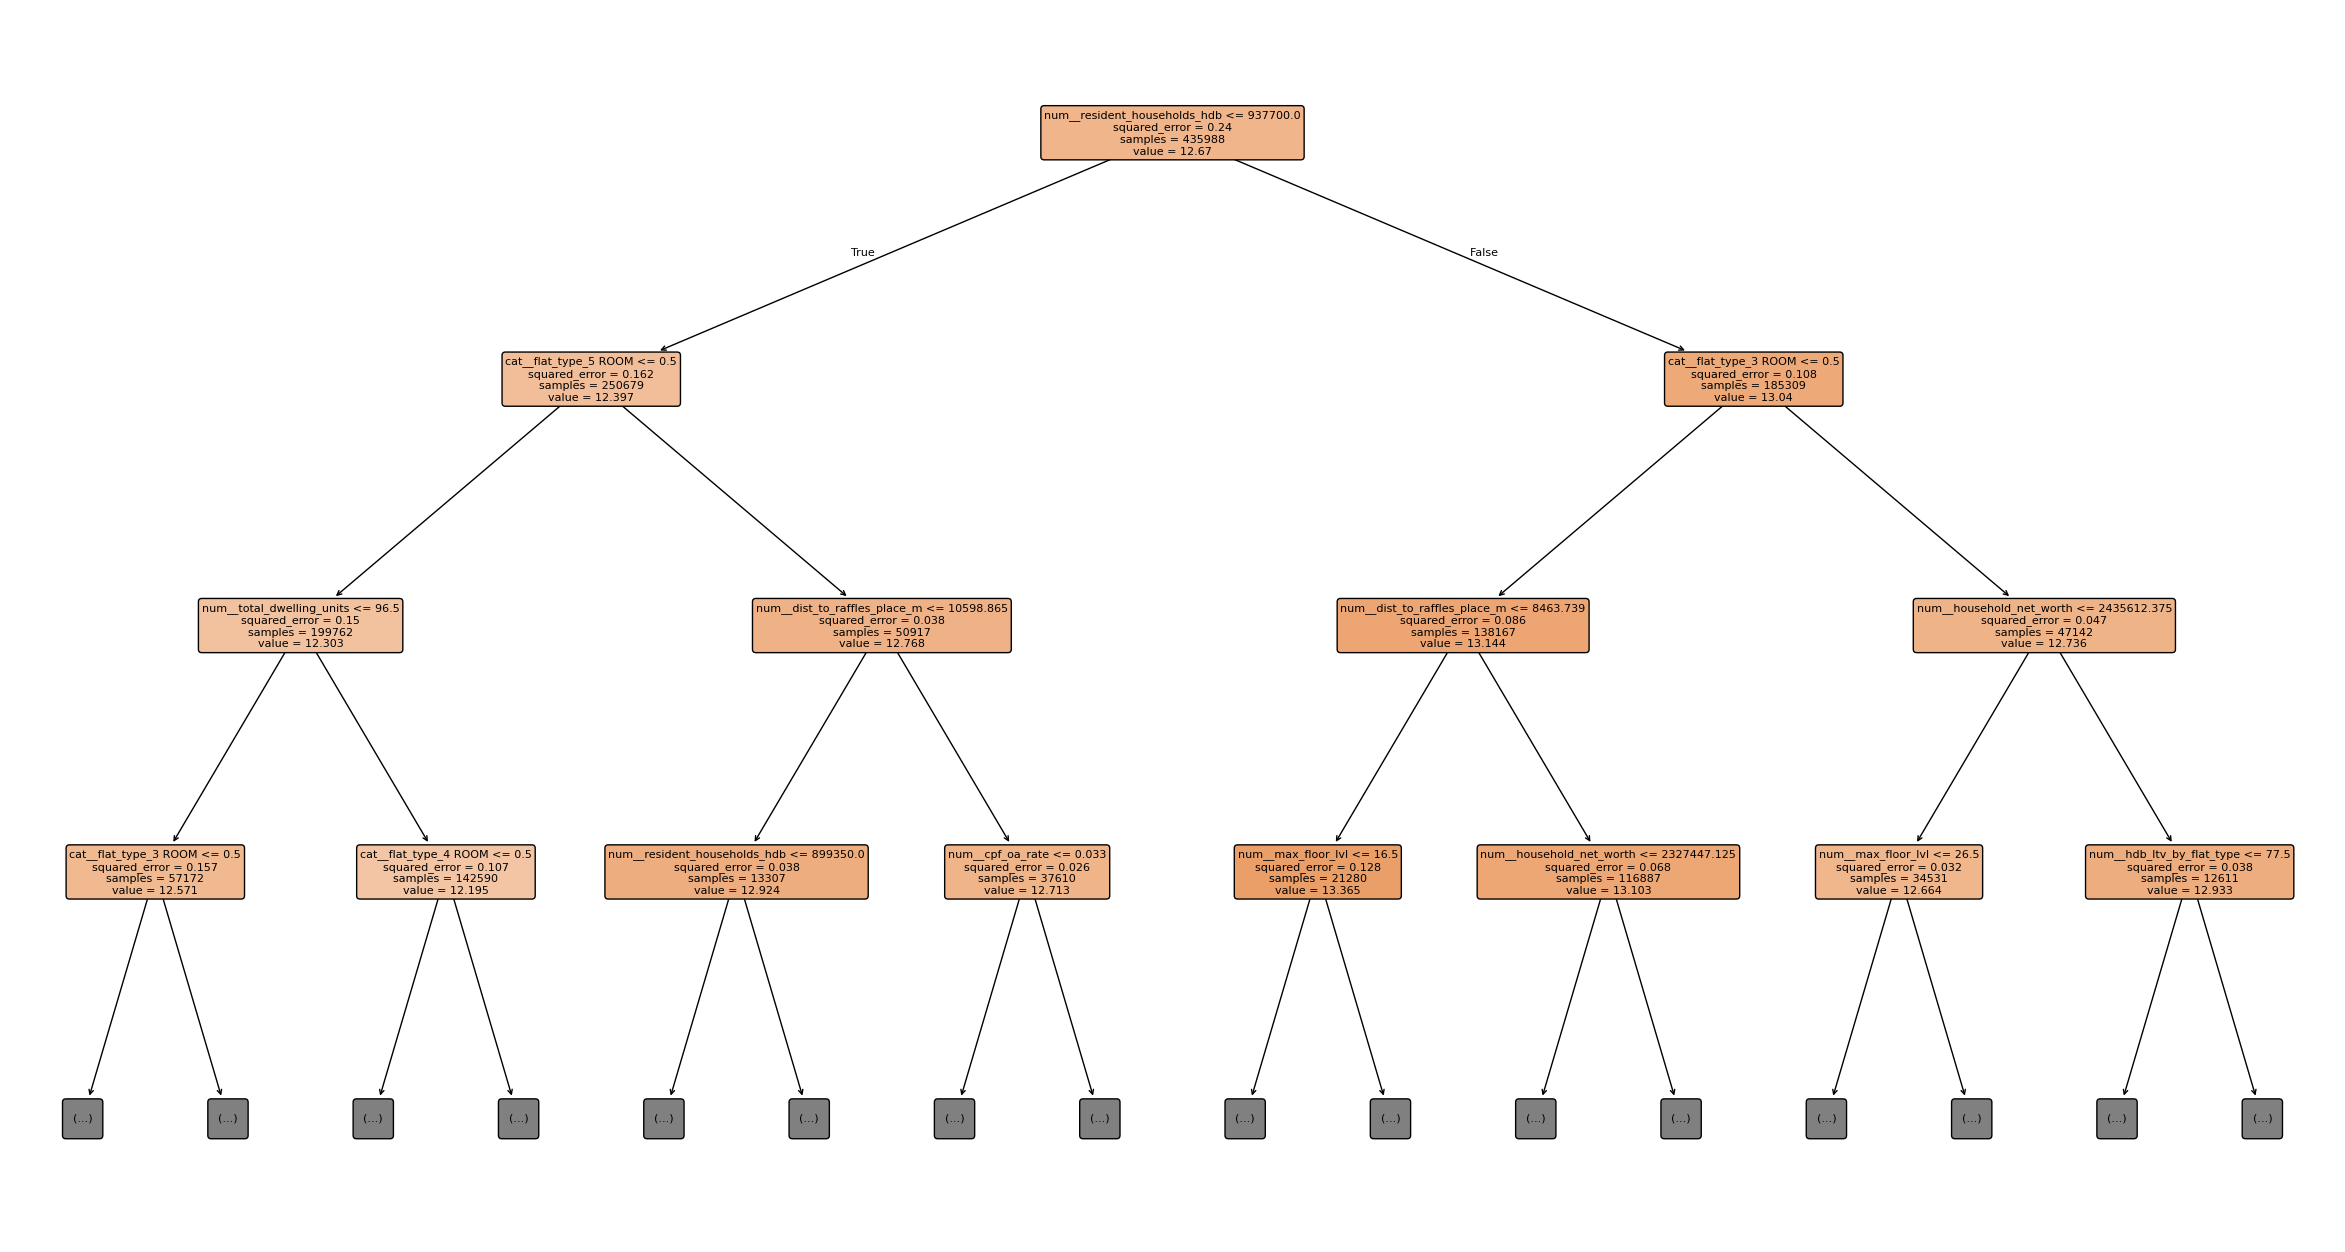

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

rf_model = best_rf_pipe.named_steps['model']
preprocess_model = best_rf_pipe.named_steps['preprocess']

feature_names = preprocess_model.get_feature_names_out()

tree_id = 0

plt.figure(figsize=(30, 16))

plot_tree(
    rf_model.estimators_[tree_id],
    feature_names=feature_names,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [26]:
test_pred = best_rf_pipe.predict(X_test)

test_metrics = calc_regression_metrics(y_test, test_pred)
test_metrics_df = pd.DataFrame([test_metrics], index=['test'])

display(test_metrics_df)

,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
test,0.041383,0.056683,0.98654,14090.808927,20725.309463,0.986007


In [30]:
train_full_pred = best_rf_pipe.predict(X_train_full)

train_full_metrics = calc_regression_metrics(y_train_full, train_full_pred)

comparison_df = pd.DataFrame([
    {'sample': 'train_val', **train_full_metrics},
    {'sample': 'test', **test_metrics}
])

display(comparison_df)

,sample,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
0,train_val,0.026123,0.036391,0.994471,8836.106280,13142.022229,0.994417
1,test,0.041383,0.056683,0.986540,14090.808927,20725.309463,0.986007


In [31]:
feature_names_after_prep = best_rf_pipe.named_steps['preprocess'].get_feature_names_out()
mdi_importances = best_rf_pipe.named_steps['model'].feature_importances_

rf_feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names_after_prep,
        'importance_mdi': mdi_importances
    })
    .sort_values('importance_mdi', ascending=False)
    .reset_index(drop=True)
)

display(rf_feature_importance_df.head(30))

,feature,importance_mdi
0,num__floor_area_sqm,0.195285
1,num__household_net_worth,0.168996
2,num__per_capita_gdp_real,0.120716
3,cat__flat_type_3 ROOM,0.088744
4,num__resident_households_hdb,0.085237
5,num__cpi_all_items,0.075822
6,num__dist_to_raffles_place_m,0.027829
7,num__hdb_housing_msr,0.027538
8,cat__flat_type_4 ROOM,0.024750
9,cat__flat_type_5 ROOM,0.022820


In [24]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

rf_preprocessor = best_rf_pipe.named_steps['preprocess']
rf_model = best_rf_pipe.named_steps['model']

feature_names = rf_preprocessor.get_feature_names_out()

test_shap_n = min(50, len(X_test))
tree_limit = min(50, len(rf_model.estimators_))
batch_size = 1

X_test_shap = X_test.sample(n=test_shap_n, random_state=42).copy()
X_test_transformed = rf_preprocessor.transform(X_test_shap)

if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = X_test_transformed.astype(np.float32, copy=False)

print('SHAP test sample shape:', X_test_transformed.shape)
print('Number of transformed features:', len(feature_names))
print('Used tree_limit:', tree_limit)
print('Batch size:', batch_size)

SHAP test sample shape: (50, 67)
Number of transformed features: 67
Used tree_limit: 50
Batch size: 1


In [25]:
rf_explainer = shap.TreeExplainer(
    rf_model,
    feature_perturbation='tree_path_dependent',
    model_output='raw'
)

n_rows = X_test_transformed.shape[0]
shap_batches = []

batch_starts = list(range(0, n_rows, batch_size))

for start in tqdm(batch_starts, desc='Расчёт SHAP для Random Forest'):
    end = min(start + batch_size, n_rows)
    X_batch = X_test_transformed[start:end]

    shap_batch = rf_explainer.shap_values(
        X_batch,
        tree_limit=tree_limit,
        check_additivity=False
    )

    shap_batches.append(shap_batch)

rf_shap_values = np.vstack(shap_batches)
rf_expected_value = rf_explainer.expected_value

print('SHAP values shape:', rf_shap_values.shape)
print('Expected value:', rf_expected_value)

Расчёт SHAP для Random Forest:   0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 67)
Expected value: [12.67081647]


In [26]:
rf_shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(rf_shap_values).mean(axis=0),
    'mean_shap': rf_shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(rf_shap_importance_df.head(30))

check_n = min(10, X_test_transformed.shape[0])

rf_shap_values_check = rf_explainer.shap_values(
    X_test_transformed[:check_n],
    tree_limit=tree_limit,
    check_additivity=True
)

rf_pred_check = rf_model.predict(X_test_transformed[:check_n])

additivity_check_df = pd.DataFrame({
    'model_pred': rf_pred_check,
    'shap_sum_plus_base': rf_shap_values_check.sum(axis=1) + rf_expected_value
})

additivity_check_df['abs_diff'] = (
    additivity_check_df['model_pred'] - additivity_check_df['shap_sum_plus_base']
).abs()

display(additivity_check_df)
print('Max abs diff:', additivity_check_df['abs_diff'].max())

,feature,mean_abs_shap,mean_shap
0,num__floor_area_sqm,0.032883,0.010527
1,num__household_net_worth,0.025206,0.002289
2,num__cpi_all_items,0.013431,0.001394
3,num__per_capita_gdp_real,0.013337,0.001293
4,num__resident_households_hdb,0.011852,0.001934
5,num__dist_to_raffles_place_m,0.010162,0.002835
6,cat__flat_type_3 ROOM,0.008579,0.002106
7,num__remaining_lease_full_years,0.006067,0.000099
8,cat__flat_type_EXECUTIVE,0.005273,0.000656
9,cat__flat_type_4 ROOM,0.004433,0.001868


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 12.860222, while the model output was 13.619258. If this difference is acceptable you can set check_additivity=False to disable this check.

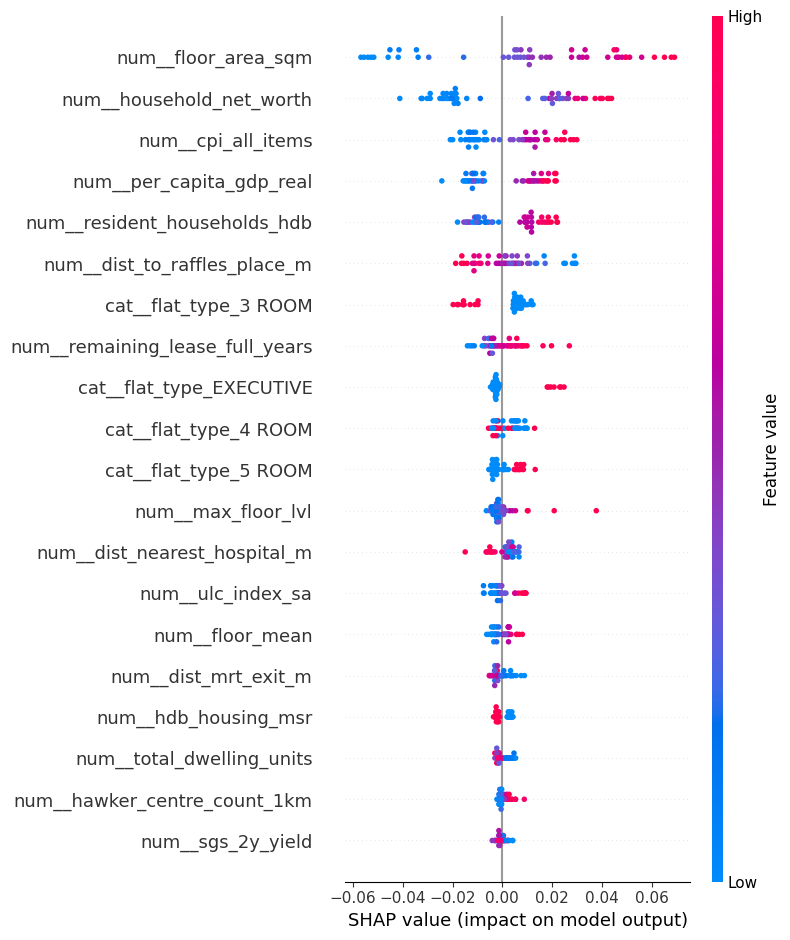

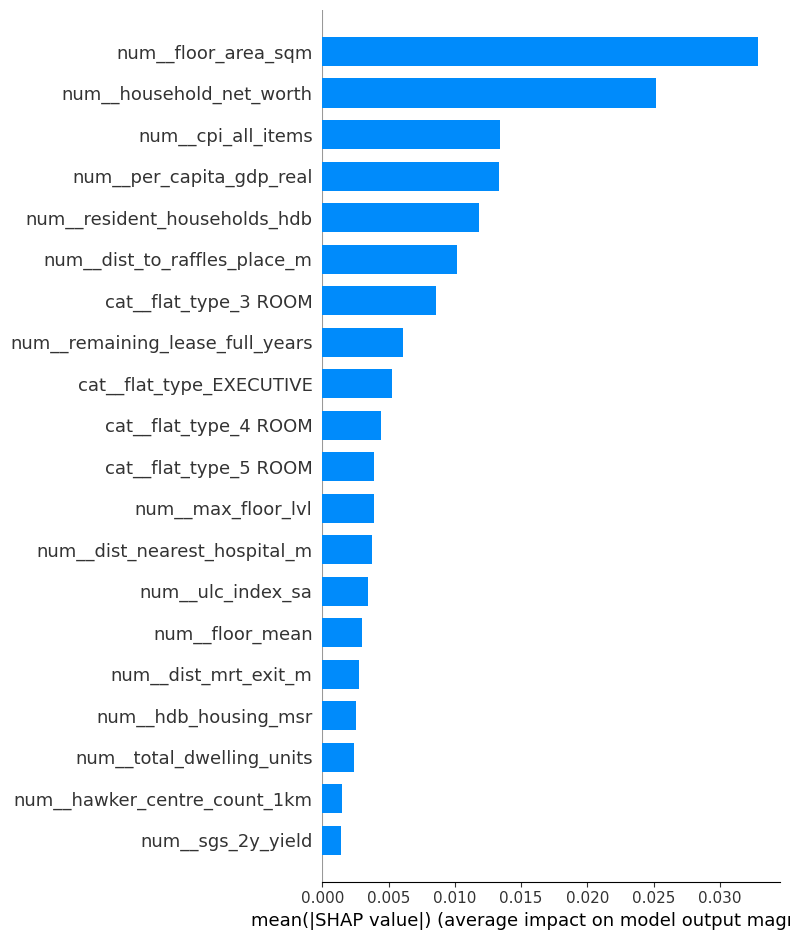

In [27]:
shap.summary_plot(
    rf_shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.show()

shap.summary_plot(
    rf_shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.tight_layout()
plt.show()

## 2.2 Gradient boosting (Catboost)

In [25]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [26]:
target_col = 'log_resale_price'

numeric_candidate_features = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'floor_mean',
    'max_floor_lvl',
    'total_dwelling_units',

    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',

    'dist_mrt_exit_m',
    'mrt_station_count_1km',
    'dist_to_raffles_place_m',
    'dist_nearest_primary_school_m',
    'primary_school_count_1km',
    'dist_nearest_secondary_school_m',
    'secondary_school_count_1km',
    'dist_nearest_park_m',
    'park_count_1km',
    'dist_nearest_hospital_m',
    'hospital_count_1km',
    'dist_nearest_hawker_centre_m',
    'hawker_centre_count_1km',

    'cpf_oa_rate',
    'hdb_housing_msr',
    'hdb_housing_loan_max_tenure_years',
    'hdb_ltv_by_flat_type',

    'cpi_all_items',
    'sgs_2y_yield',
    'resident_unemployment_rate',
    'ulc_index_sa',
    'per_capita_gdp_real',
    'resident_households_hdb',
    'household_net_worth'
]

categorical_candidate_features = [
    'town',
    'flat_type'
]

all_candidate_features = numeric_candidate_features + categorical_candidate_features
present_features = [col for col in all_candidate_features if col in df_train.columns]

print('Всего признаков для CatBoost:', len(present_features))
print(present_features)

Всего признаков для CatBoost: 36
['floor_area_sqm', 'remaining_lease_full_years', 'floor_mean', 'max_floor_lvl', 'total_dwelling_units', 'commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'dist_mrt_exit_m', 'mrt_station_count_1km', 'dist_to_raffles_place_m', 'dist_nearest_primary_school_m', 'primary_school_count_1km', 'dist_nearest_secondary_school_m', 'secondary_school_count_1km', 'dist_nearest_park_m', 'park_count_1km', 'dist_nearest_hospital_m', 'hospital_count_1km', 'dist_nearest_hawker_centre_m', 'hawker_centre_count_1km', 'cpf_oa_rate', 'hdb_housing_msr', 'hdb_housing_loan_max_tenure_years', 'hdb_ltv_by_flat_type', 'cpi_all_items', 'sgs_2y_yield', 'resident_unemployment_rate', 'ulc_index_sa', 'per_capita_gdp_real', 'resident_households_hdb', 'household_net_worth', 'town', 'flat_type']


In [27]:
X_train = df_train[present_features].copy()
y_train = df_train[target_col].copy()

X_val = df_val[present_features].copy()
y_val = df_val[target_col].copy()

X_test = df_test[present_features].copy()
y_test = df_test[target_col].copy()

cat_features = [col for col in categorical_candidate_features if col in present_features]

for df_ in [X_train, X_val, X_test]:
    for col in cat_features:
        df_[col] = df_[col].astype('string').fillna('__nan__').astype(str)

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)

print('Train shape:', X_train.shape)
print('Val shape:  ', X_val.shape)
print('Test shape: ', X_test.shape)
print('Categorical features:', cat_features)

Train shape: (603532, 36)
Val shape:   (86219, 36)
Test shape:  (172438, 36)
Categorical features: ['town', 'flat_type']


In [28]:
def calc_regression_metrics(y_true_log, y_pred_log):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)

    y_true_price = np.exp(y_true_log)
    y_pred_price = np.exp(y_pred_log)

    return {
        'mae_log': mean_absolute_error(y_true_log, y_pred_log),
        'rmse_log': root_mean_squared_error(y_true_log, y_pred_log),
        'r2_log': r2_score(y_true_log, y_pred_log),
        'mae_price': mean_absolute_error(y_true_price, y_pred_price),
        'rmse_price': root_mean_squared_error(y_true_price, y_pred_price),
        'r2_price': r2_score(y_true_price, y_pred_price)
    }

In [12]:
param_distributions = {
    'depth': [6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07],
    'l2_leaf_reg': [2, 3, 5, 7, 10, 15],
    'min_data_in_leaf': [1, 5, 10, 20, 30, 50],
    'random_strength': [0.0, 0.5, 1.0, 2.0],
    'bagging_temperature': [0.0, 0.5, 1.0, 2.0, 5.0],
    'border_count': [64, 128, 254]
}

n_iter_search = 20

sampled_params = list(
    ParameterSampler(
        param_distributions=param_distributions,
        n_iter=n_iter_search,
        random_state=42
    )
)

print(f'Будет проверено комбинаций: {len(sampled_params)}')
display(pd.DataFrame(sampled_params).head())

Будет проверено комбинаций: 20


,random_strength,min_data_in_leaf,learning_rate,l2_leaf_reg,depth,border_count,bagging_temperature
0,2.0,1,0.05,15,7,128,0.5
1,0.0,50,0.01,3,7,64,0.0
2,1.0,50,0.07,15,8,128,2.0
3,0.0,50,0.05,2,8,64,5.0
4,0.0,5,0.01,10,6,64,0.5


In [13]:
search_results = []
best_model = None
best_params = None
best_val_rmse = np.inf

for i, params in enumerate(sampled_params, start=1):
    print(f'Запуск {i}/{len(sampled_params)}')
    print(params)

    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=5000,
        bootstrap_type='Bayesian',
        use_best_model=True,
        random_seed=42,
        verbose=False,

        task_type='GPU',
        devices='0',

        **params
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=300,
        verbose=False
    )

    val_pred = model.predict(val_pool)
    val_metrics = calc_regression_metrics(y_val, val_pred)

    row = {
        'run_id': i,
        **params,
        'best_iteration': model.tree_count_,
        **val_metrics
    }

    search_results.append(row)

    if val_metrics['rmse_log'] < best_val_rmse:
        best_val_rmse = val_metrics['rmse_log']
        best_model = model
        best_params = params.copy()

search_results_df = pd.DataFrame(search_results).sort_values('rmse_log').reset_index(drop=True)
display(search_results_df)

print('Лучшие параметры:')
print(best_params)
print('Лучший val RMSE(log):', best_val_rmse)
print('Лучшее число деревьев:', best_model.tree_count_)

Запуск 1/20
{'random_strength': 2.0, 'min_data_in_leaf': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 15, 'depth': 7, 'border_count': 128, 'bagging_temperature': 0.5}
Запуск 2/20
{'random_strength': 0.0, 'min_data_in_leaf': 50, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'depth': 7, 'border_count': 64, 'bagging_temperature': 0.0}
Запуск 3/20
{'random_strength': 1.0, 'min_data_in_leaf': 50, 'learning_rate': 0.07, 'l2_leaf_reg': 15, 'depth': 8, 'border_count': 128, 'bagging_temperature': 2.0}


KeyboardInterrupt: 

In [14]:
search_results_df = pd.DataFrame(search_results).sort_values('rmse_log').reset_index(drop=True)
display(search_results_df)

print('Лучшие параметры:')
print(best_params)
print('Лучший val RMSE(log):', best_val_rmse)
print('Лучшее число деревьев:', best_model.tree_count_)

,run_id,random_strength,min_data_in_leaf,learning_rate,l2_leaf_reg,depth,border_count,bagging_temperature,best_iteration,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
0,1,2.0,1,0.05,15,7,128,0.5,5000,0.040424,0.054910,0.987410,13738.167537,19751.432829,0.987505
1,2,0.0,50,0.01,3,7,64,0.0,5000,0.046513,0.062114,0.983889,16013.937428,23057.994287,0.982972


Лучшие параметры:
{'random_strength': 2.0, 'min_data_in_leaf': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 15, 'depth': 7, 'border_count': 128, 'bagging_temperature': 0.5}
Лучший val RMSE(log): 0.054909502126377116
Лучшее число деревьев: 5000


In [15]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

for col in cat_features:
    X_train_full[col] = X_train_full[col].astype('string').fillna('__nan__').astype(str)

train_full_pool = Pool(
    data=X_train_full,
    label=y_train_full,
    cat_features=cat_features
)

final_cat_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=best_model.tree_count_,
    bootstrap_type='Bayesian',
    random_seed=42,
    verbose=200,

    task_type='GPU',
    devices='0',

    **best_params
)

final_cat_model.fit(train_full_pool)

0:	learn: 0.4688182	total: 50.5ms	remaining: 4m 12s
200:	learn: 0.0820085	total: 7.34s	remaining: 2m 55s
400:	learn: 0.0708374	total: 14.5s	remaining: 2m 46s
600:	learn: 0.0661556	total: 21.7s	remaining: 2m 38s
800:	learn: 0.0633656	total: 28.8s	remaining: 2m 31s
1000:	learn: 0.0614888	total: 36s	remaining: 2m 23s
1200:	learn: 0.0601119	total: 43.3s	remaining: 2m 16s
1400:	learn: 0.0590965	total: 50.6s	remaining: 2m 9s
1600:	learn: 0.0582893	total: 57.8s	remaining: 2m 2s
1800:	learn: 0.0575868	total: 1m 5s	remaining: 1m 55s
2000:	learn: 0.0570133	total: 1m 12s	remaining: 1m 48s
2200:	learn: 0.0564911	total: 1m 19s	remaining: 1m 41s
2400:	learn: 0.0560661	total: 1m 26s	remaining: 1m 34s
2600:	learn: 0.0556832	total: 1m 34s	remaining: 1m 26s
2800:	learn: 0.0553458	total: 1m 41s	remaining: 1m 19s
3000:	learn: 0.0550189	total: 1m 48s	remaining: 1m 12s
3200:	learn: 0.0547249	total: 1m 55s	remaining: 1m 5s
3400:	learn: 0.0544634	total: 2m 2s	remaining: 57.8s
3600:	learn: 0.0542171	total: 2m 

CatBoostRegressor(bagging_temperature=0.5, bootstrap_type='Bayesian', border_count=128, depth=7, devices='0', eval_metric='RMSE', iterations=5000, l2_leaf_reg=15, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=1, random_seed=42, random_strength=2.0, task_type='GPU', verbose=200)

In [29]:
best_params = {'random_strength': 2.0, 'min_data_in_leaf': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 15, 'depth': 7, 'border_count': 128, 'bagging_temperature': 0.5}

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

for col in cat_features:
    X_train_full[col] = X_train_full[col].astype('string').fillna('__nan__').astype(str)

train_full_pool = Pool(
    data=X_train_full,
    label=y_train_full,
    cat_features=cat_features
)

final_cat_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=5000,
    bootstrap_type='Bayesian',
    random_seed=42,
    verbose=200,

    task_type='GPU',
    devices='0',

    **best_params
)

final_cat_model.fit(train_full_pool)

0:	learn: 0.4688182	total: 163ms	remaining: 13m 32s
200:	learn: 0.0820085	total: 7.4s	remaining: 2m 56s
400:	learn: 0.0708374	total: 14.5s	remaining: 2m 46s
600:	learn: 0.0661556	total: 21.6s	remaining: 2m 38s
800:	learn: 0.0633615	total: 28.7s	remaining: 2m 30s
1000:	learn: 0.0614820	total: 35.8s	remaining: 2m 23s
1200:	learn: 0.0601357	total: 43s	remaining: 2m 15s
1400:	learn: 0.0591121	total: 50.1s	remaining: 2m 8s
1600:	learn: 0.0582870	total: 57.3s	remaining: 2m 1s
1800:	learn: 0.0575930	total: 1m 4s	remaining: 1m 54s
2000:	learn: 0.0570067	total: 1m 11s	remaining: 1m 47s
2200:	learn: 0.0564780	total: 1m 19s	remaining: 1m 40s
2400:	learn: 0.0560347	total: 1m 26s	remaining: 1m 33s
2600:	learn: 0.0556331	total: 1m 33s	remaining: 1m 26s
2800:	learn: 0.0552884	total: 1m 40s	remaining: 1m 19s
3000:	learn: 0.0549793	total: 1m 48s	remaining: 1m 12s
3200:	learn: 0.0546900	total: 1m 55s	remaining: 1m 4s
3400:	learn: 0.0544226	total: 2m 2s	remaining: 57.8s
3600:	learn: 0.0541840	total: 2m 1

CatBoostRegressor(bagging_temperature=0.5, bootstrap_type='Bayesian', border_count=128, depth=7, devices='0', eval_metric='RMSE', iterations=5000, l2_leaf_reg=15, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=1, random_seed=42, random_strength=2.0, task_type='GPU', verbose=200)

In [16]:
test_pred = final_cat_model.predict(test_pool)
test_metrics = calc_regression_metrics(y_test, test_pred)

test_metrics_df = pd.DataFrame([test_metrics], index=['test'])
display(test_metrics_df)

,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
test,0.040194,0.054567,0.987526,13608.414984,19511.555833,0.987598


In [17]:
train_full_pred = final_cat_model.predict(train_full_pool)

train_full_metrics = calc_regression_metrics(y_train_full, train_full_pred)

comparison_df = pd.DataFrame([
    {'sample': 'train_val', **train_full_metrics},
    {'sample': 'test', **test_metrics}
])

display(comparison_df)

,sample,mae_log,rmse_log,r2_log,mae_price,rmse_price,r2_price
0,train_val,0.039096,0.052812,0.988356,13253.548312,18941.091560,0.988403
1,test,0.040194,0.054567,0.987526,13608.414984,19511.555833,0.987598


In [18]:
feature_importance_df = pd.DataFrame({
    'feature': present_features,
    'importance': final_cat_model.get_feature_importance(train_full_pool)
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(feature_importance_df.head(30))

,feature,importance
0,floor_area_sqm,30.705812
1,household_net_worth,17.360984
2,resident_households_hdb,7.782873
3,dist_to_raffles_place_m,7.700134
4,cpi_all_items,6.708697
5,flat_type,5.723696
6,remaining_lease_full_years,3.494217
7,per_capita_gdp_real,3.225269
8,max_floor_lvl,2.726574
9,town,2.446826


In [34]:
import numpy as np
import pandas as pd
from catboost import Pool, EFstrType
from pathlib import Path

X_test_shap = X_test.copy()

for col in cat_features:
    X_test_shap[col] = X_test_shap[col].astype('string').fillna('__nan__').astype(str)

test_pool = Pool(
    data=X_test_shap,
    label=y_test,
    cat_features=cat_features
)

print('Test shape:', X_test_shap.shape)

Test shape: (172438, 36)


In [35]:
cat_shap_full = final_cat_model.get_feature_importance(
    data=test_pool,
    type=EFstrType.ShapValues,
    thread_count=-1,
    verbose=True
)

print('SHAP full shape:', cat_shap_full.shape)

Processing trees...
128/5000 trees processed	passed time: 371ms	remaining time: 14.1s
256/5000 trees processed	passed time: 748ms	remaining time: 13.9s
384/5000 trees processed	passed time: 1.14s	remaining time: 13.7s
512/5000 trees processed	passed time: 1.51s	remaining time: 13.2s
640/5000 trees processed	passed time: 1.91s	remaining time: 13s
768/5000 trees processed	passed time: 2.31s	remaining time: 12.8s
896/5000 trees processed	passed time: 2.71s	remaining time: 12.4s
1024/5000 trees processed	passed time: 3.14s	remaining time: 12.2s
1152/5000 trees processed	passed time: 3.55s	remaining time: 11.9s
1280/5000 trees processed	passed time: 3.96s	remaining time: 11.5s
1408/5000 trees processed	passed time: 4.39s	remaining time: 11.2s
1536/5000 trees processed	passed time: 4.81s	remaining time: 10.8s
1664/5000 trees processed	passed time: 5.21s	remaining time: 10.4s
1792/5000 trees processed	passed time: 5.65s	remaining time: 10.1s
1920/5000 trees processed	passed time: 6.11s	remain

In [36]:
cat_feature_names = X_test_shap.columns.tolist()

cat_shap_values = cat_shap_full[:, :-1]
cat_expected_value_by_object = cat_shap_full[:, -1]

print('SHAP values shape:', cat_shap_values.shape)
print('Expected value column shape:', cat_expected_value_by_object.shape)
print('Unique expected values:', pd.Series(cat_expected_value_by_object).nunique())
print('Expected value:', float(cat_expected_value_by_object[0]))

SHAP values shape: (172438, 36)
Expected value column shape: (172438,)
Unique expected values: 1
Expected value: 12.67082591894768


In [37]:
cat_shap_importance_df = pd.DataFrame({
    'feature': cat_feature_names,
    'mean_abs_shap': np.abs(cat_shap_values).mean(axis=0),
    'mean_shap': cat_shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(cat_shap_importance_df.head(30))

,feature,mean_abs_shap,mean_shap
0,floor_area_sqm,0.178333,-0.002459
1,household_net_worth,0.126703,-0.002176
2,resident_households_hdb,0.076488,0.001784
3,cpi_all_items,0.064943,0.000148
4,dist_to_raffles_place_m,0.056242,0.000690
5,remaining_lease_full_years,0.054967,0.000031
6,flat_type,0.047798,0.006111
7,per_capita_gdp_real,0.033469,-0.001316
8,town,0.028547,-0.001819
9,dist_mrt_exit_m,0.027462,0.000037


In [38]:
cat_pred_test = final_cat_model.predict(test_pool)

additivity_check_df = pd.DataFrame({
    'model_pred': cat_pred_test[:10],
    'shap_sum_plus_base': cat_shap_values[:10].sum(axis=1) + cat_expected_value_by_object[:10]
})

additivity_check_df['abs_diff'] = (
    additivity_check_df['model_pred'] - additivity_check_df['shap_sum_plus_base']
).abs()

display(additivity_check_df)
print('Max abs diff:', additivity_check_df['abs_diff'].max())

,model_pred,shap_sum_plus_base,abs_diff
0,12.052000,12.052000,0.000000e+00
1,12.683848,12.683848,1.776357e-15
2,12.325274,12.325274,0.000000e+00
3,12.559041,12.559041,0.000000e+00
4,12.621800,12.621800,0.000000e+00
5,12.747996,12.747996,1.776357e-15
6,13.106297,13.106297,0.000000e+00
7,12.045969,12.045969,0.000000e+00
8,12.243597,12.243597,1.776357e-15
9,13.145802,13.145802,0.000000e+00


Max abs diff: 1.7763568394002505e-15


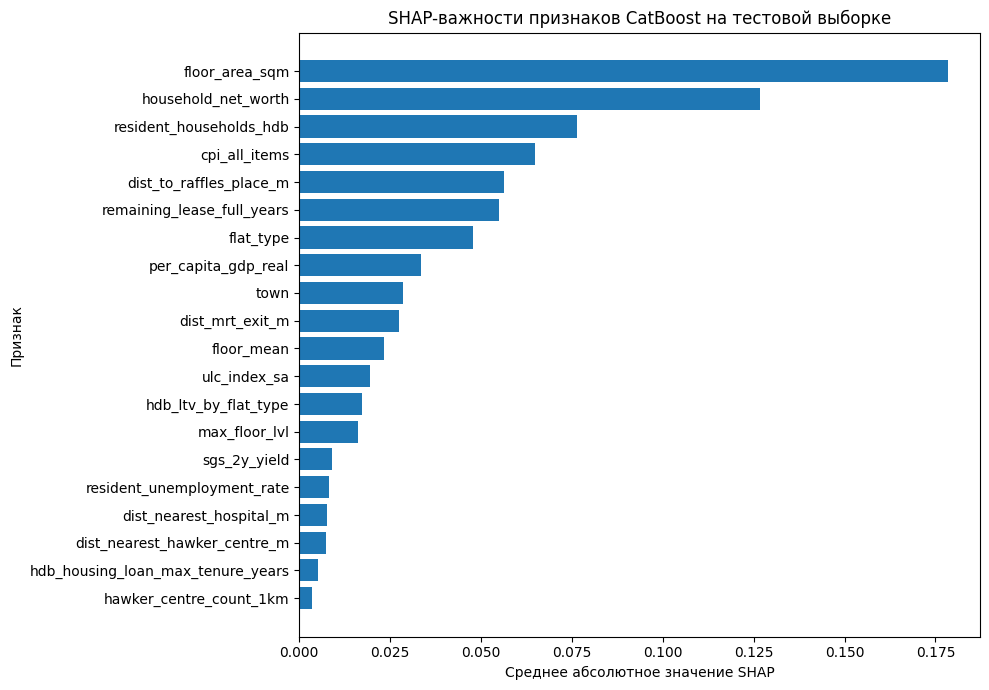

In [39]:
import matplotlib.pyplot as plt

top_n = 20
plot_df = cat_shap_importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['mean_abs_shap'])
plt.xlabel('Среднее абсолютное значение SHAP')
plt.ylabel('Признак')
plt.title('SHAP-важности признаков CatBoost на тестовой выборке')
plt.tight_layout()
plt.show()

In [40]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cat_explanation = shap.Explanation(
    values=cat_shap_values,
    base_values=cat_expected_value_by_object,
    data=X_test_shap[cat_feature_names],
    feature_names=cat_feature_names
)

print(cat_explanation.shape)

(172438, 36)


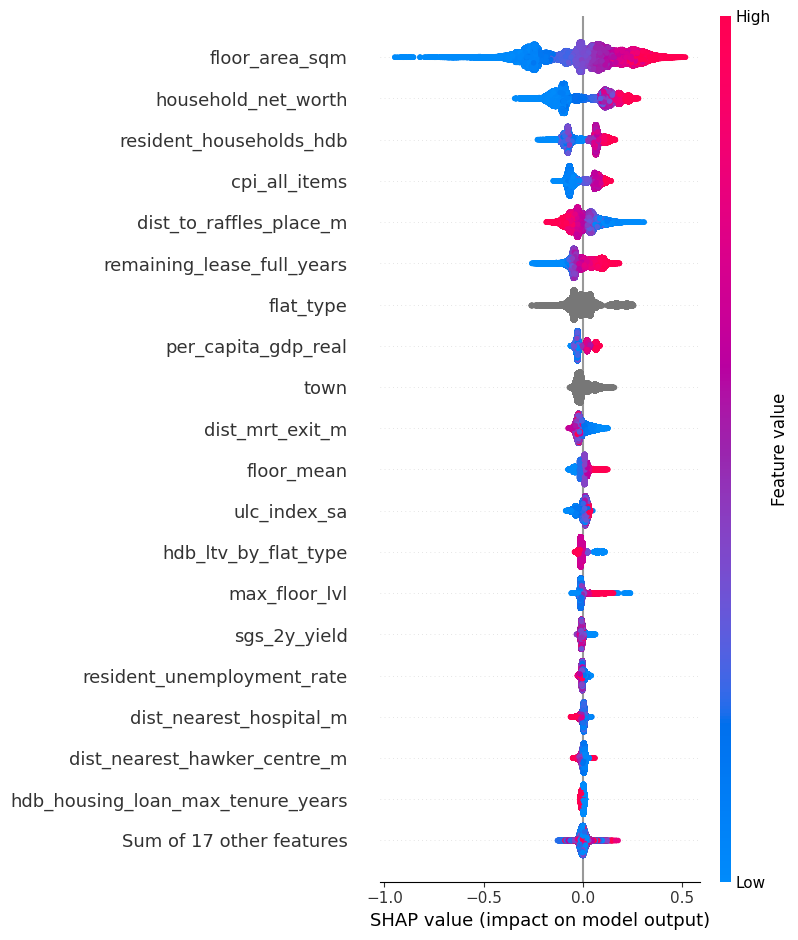

In [41]:
shap.plots.beeswarm(cat_explanation, max_display=20, show=False)
plt.tight_layout()
plt.show()

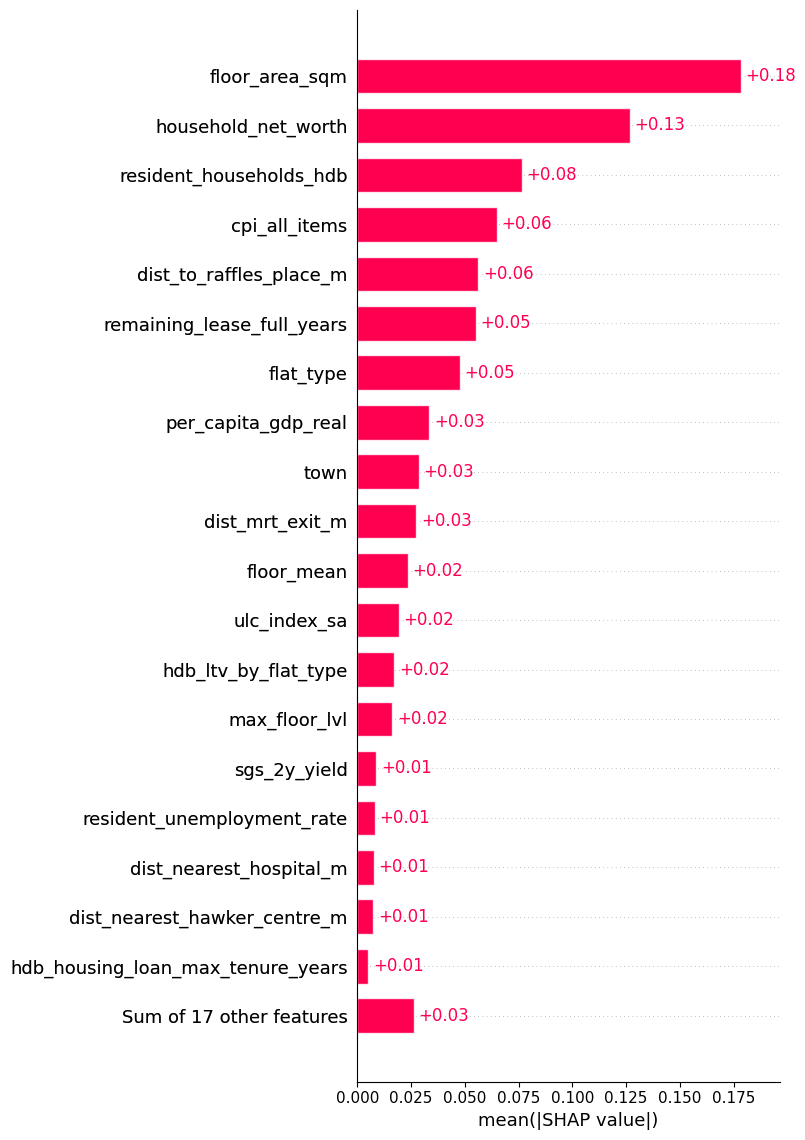

In [42]:
shap.plots.bar(cat_explanation.abs.mean(0), max_display=20, show=False)
plt.tight_layout()
plt.show()

In [44]:
cat_shap_top20_df = pd.DataFrame({
    'feature': cat_feature_names,
    'mean_abs_shap': np.abs(cat_shap_values).mean(axis=0),
    'mean_shap': cat_shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(cat_shap_top20_df.head(20))

,feature,mean_abs_shap,mean_shap
0,floor_area_sqm,0.178333,-0.002459
1,household_net_worth,0.126703,-0.002176
2,resident_households_hdb,0.076488,0.001784
3,cpi_all_items,0.064943,0.000148
4,dist_to_raffles_place_m,0.056242,0.000690
5,remaining_lease_full_years,0.054967,0.000031
6,flat_type,0.047798,0.006111
7,per_capita_gdp_real,0.033469,-0.001316
8,town,0.028547,-0.001819
9,dist_mrt_exit_m,0.027462,0.000037


In [47]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cat_explanation = shap.Explanation(
    values=cat_shap_values,
    base_values=cat_expected_value_by_object,
    data=X_test_shap[cat_feature_names].to_numpy(),
    feature_names=cat_feature_names
)

print(cat_explanation.shape)

(172438, 36)


floor_area_sqm


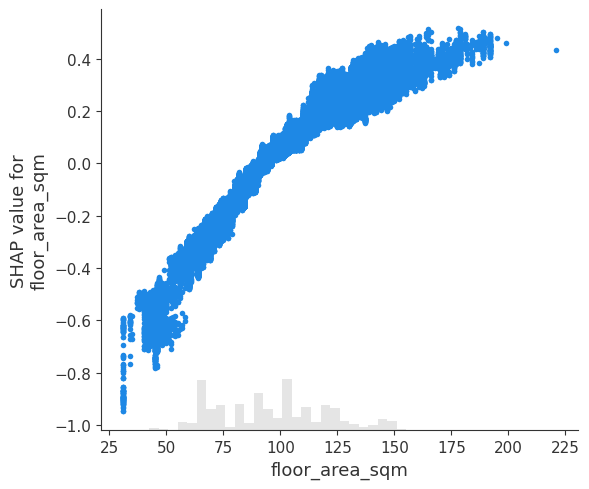

household_net_worth


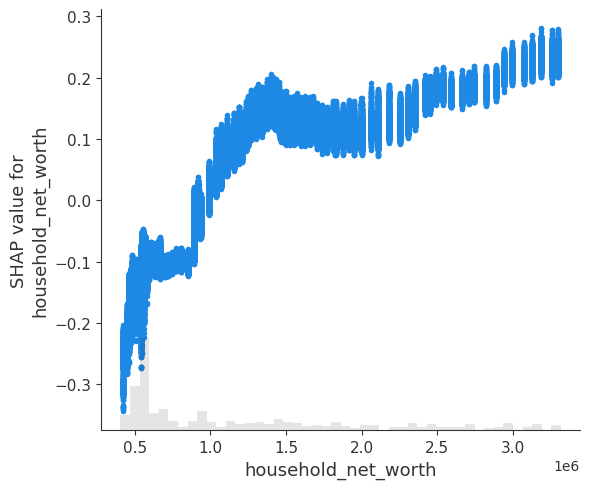

resident_households_hdb


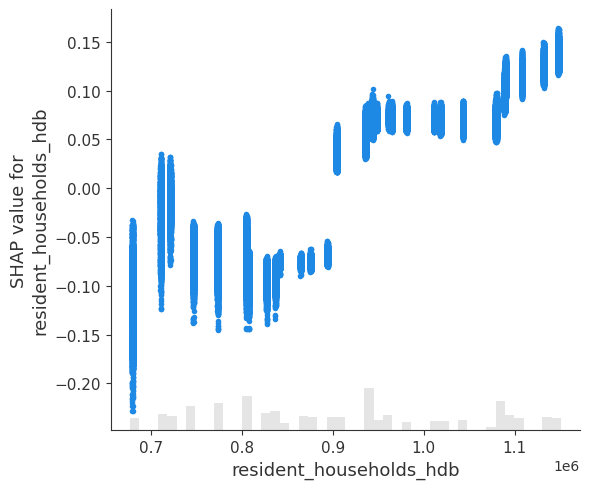

cpi_all_items


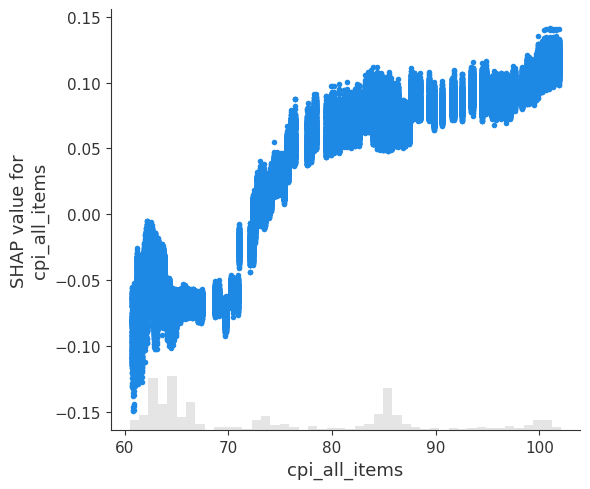

In [48]:
top_features_for_scatter = cat_shap_top20_df['feature'].head(4).tolist()

for feature in top_features_for_scatter:
    print(feature)
    shap.plots.scatter(cat_explanation[:, feature], show=False)
    plt.tight_layout()
    plt.show()

## Бутстрэп тестирование моделей

### CatBoost vs Random Forest

In [30]:
import numpy as np
import pandas as pd
from catboost import Pool
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


def prepare_catboost_pool_from_df(df_source, feature_cols, cat_cols, target_col=None):
    X = df_source[feature_cols].copy()

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype('string').fillna('__nan__').astype(str)

    if target_col is None:
        return Pool(
            data=X,
            cat_features=[col for col in cat_cols if col in X.columns]
        )

    return Pool(
        data=X,
        label=df_source[target_col],
        cat_features=[col for col in cat_cols if col in X.columns]
    )


def paired_bootstrap_metric_diff(
    y_true,
    y_pred_model,
    y_pred_baseline,
    model_name,
    baseline_name,
    n_bootstrap=5000,
    confidence_level=0.95,
    batch_size=25,
    random_state=42
):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred_model = np.asarray(y_pred_model, dtype=np.float64)
    y_pred_baseline = np.asarray(y_pred_baseline, dtype=np.float64)

    mask = (
        np.isfinite(y_true)
        & np.isfinite(y_pred_model)
        & np.isfinite(y_pred_baseline)
    )

    y_true = y_true[mask]
    y_pred_model = y_pred_model[mask]
    y_pred_baseline = y_pred_baseline[mask]

    n = len(y_true)
    rng = np.random.default_rng(random_state)

    abs_err_model = np.abs(y_true - y_pred_model)
    abs_err_baseline = np.abs(y_true - y_pred_baseline)

    sq_err_model = (y_true - y_pred_model) ** 2
    sq_err_baseline = (y_true - y_pred_baseline) ** 2

    mae_model = abs_err_model.mean()
    mae_baseline = abs_err_baseline.mean()
    rmse_model = np.sqrt(sq_err_model.mean())
    rmse_baseline = np.sqrt(sq_err_baseline.mean())

    mae_diff = mae_baseline - mae_model
    rmse_diff = rmse_baseline - rmse_model

    mae_boot = np.empty(n_bootstrap, dtype=np.float64)
    rmse_boot = np.empty(n_bootstrap, dtype=np.float64)

    done = 0

    while done < n_bootstrap:
        current_batch = min(batch_size, n_bootstrap - done)
        idx = rng.integers(0, n, size=(current_batch, n))

        mae_boot[done:done + current_batch] = (
            abs_err_baseline[idx].mean(axis=1)
            - abs_err_model[idx].mean(axis=1)
        )

        rmse_boot[done:done + current_batch] = (
            np.sqrt(sq_err_baseline[idx].mean(axis=1))
            - np.sqrt(sq_err_model[idx].mean(axis=1))
        )

        done += current_batch

    alpha = 1 - confidence_level
    low_q = 100 * alpha / 2
    high_q = 100 * (1 - alpha / 2)

    mae_ci_low, mae_ci_high = np.percentile(mae_boot, [low_q, high_q])
    rmse_ci_low, rmse_ci_high = np.percentile(rmse_boot, [low_q, high_q])

    mae_p_one_sided = (np.sum(mae_boot <= 0) + 1) / (n_bootstrap + 1)
    rmse_p_one_sided = (np.sum(rmse_boot <= 0) + 1) / (n_bootstrap + 1)

    return pd.DataFrame([
        {
            'comparison': f'{model_name} vs {baseline_name}',
            'metric': 'MAE',
            'n_obs': n,
            f'{model_name}': mae_model,
            f'{baseline_name}': mae_baseline,
            'diff_baseline_minus_model': mae_diff,
            'ci_95_low': mae_ci_low,
            'ci_95_high': mae_ci_high,
            'p_value_one_sided_model_better': mae_p_one_sided,
            'model_better_by_ci_95': mae_ci_low > 0
        },
        {
            'comparison': f'{model_name} vs {baseline_name}',
            'metric': 'RMSE',
            'n_obs': n,
            f'{model_name}': rmse_model,
            f'{baseline_name}': rmse_baseline,
            'diff_baseline_minus_model': rmse_diff,
            'ci_95_low': rmse_ci_low,
            'ci_95_high': rmse_ci_high,
            'p_value_one_sided_model_better': rmse_p_one_sided,
            'model_better_by_ci_95': rmse_ci_low > 0
        }
    ])

In [31]:
target_col = 'log_resale_price'

ml_test_idx = df_test[target_col].dropna().index

df_test_ml = df_test.loc[ml_test_idx].copy()

cat_test_pool_ml = prepare_catboost_pool_from_df(
    df_source=df_test_ml,
    feature_cols=present_features,
    cat_cols=cat_features,
    target_col=target_col
)

cat_pred_log_ml = final_cat_model.predict(cat_test_pool_ml)

rf_pred_log_ml = best_rf_pipe.predict(
    df_test_ml[selected_features].copy()
)

y_true_price_ml = np.exp(df_test_ml[target_col].to_numpy())
cat_pred_price_ml = np.exp(cat_pred_log_ml)
rf_pred_price_ml = np.exp(rf_pred_log_ml)

cat_vs_rf_bootstrap_df = paired_bootstrap_metric_diff(
    y_true=y_true_price_ml,
    y_pred_model=cat_pred_price_ml,
    y_pred_baseline=rf_pred_price_ml,
    model_name='CatBoost',
    baseline_name='Random Forest',
    n_bootstrap=5000,
    confidence_level=0.95,
    batch_size=25,
    random_state=42
)

display(cat_vs_rf_bootstrap_df)

,comparison,metric,n_obs,CatBoost,Random Forest,diff_baseline_minus_model,ci_95_low,ci_95_high,p_value_one_sided_model_better,model_better_by_ci_95
0,CatBoost vs Random Forest,MAE,172438,13606.282076,14090.808927,484.526851,435.183281,534.038439,0.0002,True
1,CatBoost vs Random Forest,RMSE,172438,19512.811946,20725.309463,1212.497517,1091.229520,1336.352932,0.0002,True


### CatBoost vs Log-hedonic OLS full

In [44]:
ols_test_idx = test_full_ols.index

df_test_ols_common = df_test.loc[ols_test_idx].copy()

cat_test_pool_ols_common = prepare_catboost_pool_from_df(
    df_source=df_test_ols_common,
    feature_cols=present_features,
    cat_cols=cat_features,
    target_col=target_col
)

cat_pred_log_ols_common = final_cat_model.predict(cat_test_pool_ols_common)

ols_full_pred_log = hedonic_full_res.predict(test_full_ols)

y_true_price_ols_common = np.exp(test_full_ols[target_col].to_numpy())
cat_pred_price_ols_common = np.exp(cat_pred_log_ols_common)
ols_full_pred_price = np.exp(np.asarray(ols_full_pred_log))

cat_vs_ols_full_bootstrap_df = paired_bootstrap_metric_diff(
    y_true=y_true_price_ols_common,
    y_pred_model=cat_pred_price_ols_common,
    y_pred_baseline=ols_full_pred_price,
    model_name='CatBoost',
    baseline_name='Log-hedonic OLS + location + macro-params',
    n_bootstrap=5000,
    confidence_level=0.95,
    batch_size=25,
    random_state=42
)

display(cat_vs_ols_full_bootstrap_df)

,comparison,metric,n_obs,CatBoost,Log-hedonic OLS + location + macro-params,diff_baseline_minus_model,ci_95_low,ci_95_high,p_value_one_sided_model_better,model_better_by_ci_95
0,CatBoost vs Log-hedonic OLS + location + macro...,MAE,172438,13606.282076,36100.509622,22494.227546,22344.437224,22644.967828,0.0002,True
1,CatBoost vs Log-hedonic OLS + location + macro...,RMSE,172438,19512.811946,49281.844556,29769.032610,29488.065278,30061.117994,0.0002,True


In [45]:
bootstrap_comparison_df = pd.concat(
    [
        cat_vs_rf_bootstrap_df,
        cat_vs_ols_full_bootstrap_df
    ],
    ignore_index=True
)

display(bootstrap_comparison_df)

,comparison,metric,n_obs,CatBoost,Random Forest,diff_baseline_minus_model,ci_95_low,ci_95_high,p_value_one_sided_model_better,model_better_by_ci_95,Log-hedonic OLS + location + macro-params
0,CatBoost vs Random Forest,MAE,172438,13606.282076,14090.808927,484.526851,435.183281,534.038439,0.0002,True,NaN
1,CatBoost vs Random Forest,RMSE,172438,19512.811946,20725.309463,1212.497517,1091.229520,1336.352932,0.0002,True,NaN
2,CatBoost vs Log-hedonic OLS + location + macro...,MAE,172438,13606.282076,NaN,22494.227546,22344.437224,22644.967828,0.0002,True,36100.509622
3,CatBoost vs Log-hedonic OLS + location + macro...,RMSE,172438,19512.811946,NaN,29769.032610,29488.065278,30061.117994,0.0002,True,49281.844556


## Тест Вальда с бутстрэпом

In [24]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import patsy

from scipy.stats import chi2
from numpy.linalg import pinv

In [25]:
quantiles_wald = [0.25, 0.50, 0.75]

y_qr, X_qr = patsy.dmatrices(
    formula_qr,
    train_qr,
    return_type='dataframe'
)

y_qr = y_qr.iloc[:, 0]

pd.Series(X_qr.columns).to_frame('param_name')

,param_name
0,Intercept
1,C(town)[T.BEDOK]
2,C(town)[T.BISHAN]
3,C(town)[T.BUKIT BATOK]
4,C(town)[T.BUKIT MERAH]
5,C(town)[T.BUKIT PANJANG]
6,C(town)[T.BUKIT TIMAH]
7,C(town)[T.CENTRAL AREA]
8,C(town)[T.CHOA CHU KANG]
9,C(town)[T.CLEMENTI]


In [26]:
terms_to_test = [
    'floor_area_sqm',
    'remaining_lease_full_years',
    'np.log1p(dist_to_raffles_place_m)',
    'cpf_oa_rate',
    'sgs_2y_yield',
    'hdb_ltv_by_flat_type'
]

terms_to_test = [term for term in terms_to_test if term in X_qr.columns]

print(terms_to_test)

['floor_area_sqm', 'remaining_lease_full_years', 'np.log1p(dist_to_raffles_place_m)', 'cpf_oa_rate', 'sgs_2y_yield', 'hdb_ltv_by_flat_type']


# HDB-CompNet

In [2]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import math
import random
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, Dataset

from tqdm.auto import tqdm

In [3]:
DATA_PATH = Path(
    "/kaggle/input/datasets/paveleshmeev/"
    "sgp-resale-prices-90/"
    "df_common_sample_complete_case.csv"
)

PROJECT_DIR = Path("/kaggle/working/hdb_compnet")
CACHE_DIR = PROJECT_DIR / "cache"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
LOGS_DIR = PROJECT_DIR / "logs"

for directory in [
    PROJECT_DIR,
    CACHE_DIR,
    CHECKPOINT_DIR,
    ARTIFACTS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Исходный датасет не найден: {DATA_PATH}"
    )

SEED = 42
STRICT_DETERMINISM = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = DEVICE.type == "cuda"
USE_AMP = DEVICE.type == "cuda"

In [4]:
def set_global_seed(
    seed: int,
    strict_determinism: bool = True,
) -> torch.Generator:
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = strict_determinism

    torch.use_deterministic_algorithms(
        strict_determinism,
        warn_only=False,
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    return generator


def seed_dataloader_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)

    random.seed(worker_seed)
    np.random.seed(worker_seed)


DATALOADER_GENERATOR = set_global_seed(
    seed=SEED,
    strict_determinism=STRICT_DETERMINISM,
)

In [6]:
def collect_environment_info() -> Dict[str, Any]:
    environment_info = {
        "python_hash_seed": os.environ.get("PYTHONHASHSEED"),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(DEVICE),
        "strict_determinism": STRICT_DETERMINISM,
        "seed": SEED,
        "pin_memory": PIN_MEMORY,
        "use_amp": USE_AMP,
        "project_dir": str(PROJECT_DIR),
        "data_path": str(DATA_PATH),
    }

    if torch.cuda.is_available():
        device_properties = torch.cuda.get_device_properties(0)

        environment_info.update(
            {
                "gpu_name": torch.cuda.get_device_name(0),
                "gpu_memory_gb": round(
                    device_properties.total_memory / (1024**3),
                    2,
                ),
                "cudnn_version": torch.backends.cudnn.version(),
            }
        )

    return environment_info


ENVIRONMENT_INFO = collect_environment_info()

with open(
    ARTIFACTS_DIR / "environment_info.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ENVIRONMENT_INFO,
        file,
        ensure_ascii=False,
        indent=2,
    )

pd.Series(ENVIRONMENT_INFO, name="value")

python_hash_seed                                                     42
numpy_version                                                     2.0.2
pandas_version                                                    2.3.3
torch_version                                              2.10.0+cu128
cuda_available                                                     True
cuda_version                                                       12.8
device                                                             cuda
strict_determinism                                                 True
seed                                                                 42
pin_memory                                                         True
use_amp                                                            True
project_dir                                 /kaggle/working/hdb_compnet
data_path             /kaggle/input/datasets/paveleshmeev/sgp-resale...
gpu_name                                                       T

In [7]:
if "df_common_sample" not in globals():
    raise NameError(
        "Переменная df_common_sample не найдена. "
        "Сначала загрузите исходный датасет."
    )

if not isinstance(df_common_sample, pd.DataFrame):
    raise TypeError(
        "df_common_sample должен быть объектом pandas.DataFrame."
    )

audit_df = df_common_sample

AUDIT_DIR = ARTIFACTS_DIR / "dataset_audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print("Размер датасета:")
print(f"Строки: {audit_df.shape[0]:,}")
print(f"Столбцы: {audit_df.shape[1]:,}")
print()

print("Информация DataFrame:")
audit_df.info(
    verbose=True,
    show_counts=True,
    memory_usage="deep",
)

Размер датасета:
Строки: 862,189
Столбцы: 70

Информация DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862189 entries, 0 to 862188
Data columns (total 70 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   resale_id                            862189 non-null  int64  
 1   transaction_date                     862189 non-null  object 
 2   x                                    862189 non-null  float64
 3   y                                    862189 non-null  float64
 4   max_floor_lvl                        862189 non-null  float64
 5   year_completed                       862189 non-null  float64
 6   commercial                           862189 non-null  float64
 7   market_hawker                        862189 non-null  float64
 8   miscellaneous                        862189 non-null  float64
 9   multistorey_carpark                  862189 non-null  float64
 10  precinct_pav

In [8]:
column_memory_bytes = audit_df.memory_usage(
    index=False,
    deep=True,
)

column_nunique = audit_df.nunique(
    dropna=True,
)

dataset_schema_audit = pd.DataFrame(
    {
        "column": audit_df.columns,
        "dtype": audit_df.dtypes.astype(str).values,
        "non_null_count": audit_df.notna().sum().values,
        "missing_count": audit_df.isna().sum().values,
        "missing_share": audit_df.isna().mean().values,
        "nunique": column_nunique.reindex(
            audit_df.columns
        ).values,
        "memory_mb": (
            column_memory_bytes.reindex(
                audit_df.columns
            ).values
            / 1024**2
        ),
    }
)

dataset_schema_audit["unique_share"] = (
    dataset_schema_audit["nunique"]
    / len(audit_df)
)

dataset_schema_audit = dataset_schema_audit.sort_values(
    "column"
).reset_index(drop=True)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    220,
    "display.float_format",
    "{:.6f}".format,
):
    display(dataset_schema_audit)

,column,dtype,non_null_count,missing_count,missing_share,nunique,memory_mb,unique_share
0,bank_hdb_max_tenure_years,float64,862189,0,0.000000,2,6.577980,0.000002
1,bank_hdb_msr,float64,862189,0,0.000000,2,6.577980,0.000002
2,bldg_contract_town,object,862189,0,0.000000,26,42.159418,0.000030
3,commercial,float64,862189,0,0.000000,2,6.577980,0.000002
4,cpf_oa_rate,float64,862189,0,0.000000,7,6.577980,0.000008
5,cpi_all_items,float64,862189,0,0.000000,366,6.577980,0.000425
6,dist_mrt_exit_m,float64,862189,0,0.000000,13177,6.577980,0.015283
7,dist_nearest_hawker_centre_m,float64,862189,0,0.000000,17248,6.577980,0.020005
8,dist_nearest_hospital_m,float64,862189,0,0.000000,14446,6.577980,0.016755
9,dist_nearest_park_m,float64,862189,0,0.000000,9724,6.577980,0.011278


In [9]:
all_null_columns = dataset_schema_audit.loc[
    dataset_schema_audit["non_null_count"] == 0,
    "column",
].tolist()

constant_columns = dataset_schema_audit.loc[
    dataset_schema_audit["nunique"] <= 1,
    "column",
].tolist()

fully_unique_columns = dataset_schema_audit.loc[
    dataset_schema_audit["nunique"] == len(audit_df),
    "column",
].tolist()

name_based_id_columns = [
    column
    for column in audit_df.columns
    if (
        column.lower() == "id"
        or column.lower().endswith("_id")
        or column.lower().startswith("id_")
    )
]

exact_duplicate_rows_after_first = int(
    audit_df.duplicated(keep="first").sum()
)

rows_participating_in_duplicates = int(
    audit_df.duplicated(keep=False).sum()
)

print("Полностью пустые столбцы:")
print(all_null_columns)
print()

print("Константные столбцы:")
print(constant_columns)
print()

print("Столбцы с уникальным значением в каждой строке:")
print(fully_unique_columns)
print()

print("Предполагаемые ID-столбцы по названию:")
print(name_based_id_columns)
print()

print("Полностью повторяющиеся строки сверх первых экземпляров:")
print(f"{exact_duplicate_rows_after_first:,}")
print()

print("Все строки, участвующие в группах полных дубликатов:")
print(f"{rows_participating_in_duplicates:,}")

Полностью пустые столбцы:
[]

Константные столбцы:
['onemap_status']

Столбцы с уникальным значением в каждой строке:
['resale_id']

Предполагаемые ID-столбцы по названию:
['resale_id']

Полностью повторяющиеся строки сверх первых экземпляров:
0

Все строки, участвующие в группах полных дубликатов:
0


In [10]:
id_column_audit_rows = []

for column in sorted(
    set(name_based_id_columns + fully_unique_columns)
):
    series = audit_df[column]

    id_column_audit_rows.append(
        {
            "column": column,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "nunique_dropna": int(
                series.nunique(dropna=True)
            ),
            "duplicated_non_null_count": int(
                series[
                    series.notna()
                ].duplicated(keep=False).sum()
            ),
            "is_unique_including_missing": bool(
                series.is_unique
            ),
        }
    )

id_column_audit = pd.DataFrame(
    id_column_audit_rows
)

if not id_column_audit.empty:
    display(id_column_audit)
else:
    print("Кандидаты на роль идентификатора не найдены.")

,column,dtype,missing_count,nunique_dropna,duplicated_non_null_count,is_unique_including_missing
0,resale_id,int64,0,862189,0,True


In [11]:
numeric_columns = audit_df.select_dtypes(
    include=[np.number]
).columns.tolist()

infinite_audit_rows = []

for column in numeric_columns:
    numeric_series = pd.to_numeric(
        audit_df[column],
        errors="coerce",
    )

    values = numeric_series.to_numpy(
        dtype=np.float64,
        na_value=np.nan,
    )

    positive_infinity_count = int(
        np.isposinf(values).sum()
    )

    negative_infinity_count = int(
        np.isneginf(values).sum()
    )

    infinite_audit_rows.append(
        {
            "column": column,
            "positive_infinity_count": (
                positive_infinity_count
            ),
            "negative_infinity_count": (
                negative_infinity_count
            ),
            "total_infinity_count": (
                positive_infinity_count
                + negative_infinity_count
            ),
        }
    )

infinite_value_audit = pd.DataFrame(
    infinite_audit_rows
).sort_values(
    [
        "total_infinity_count",
        "column",
    ],
    ascending=[False, True],
).reset_index(drop=True)

display(
    infinite_value_audit[
        infinite_value_audit[
            "total_infinity_count"
        ] > 0
    ]
)

if (
    infinite_value_audit[
        "total_infinity_count"
    ].sum()
    == 0
):
    print(
        "Бесконечные значения в числовых "
        "столбцах не обнаружены."
    )

,column,positive_infinity_count,negative_infinity_count,total_infinity_count


Бесконечные значения в числовых столбцах не обнаружены.


In [12]:
if "transaction_date" not in audit_df.columns:
    print(
        "Столбец transaction_date отсутствует."
    )
    transaction_date_audit = None
    transaction_time_summary = pd.DataFrame()
    transaction_year_counts = pd.DataFrame()
    transaction_month_counts = pd.DataFrame()
else:
    transaction_date_audit = pd.to_datetime(
        audit_df["transaction_date"],
        errors="coerce",
    )

    transaction_month_period = (
        transaction_date_audit.dt.to_period("M")
    )

    transaction_time_summary = pd.DataFrame(
        {
            "indicator": [
                "row_count",
                "valid_date_count",
                "invalid_or_missing_date_count",
                "minimum_date",
                "maximum_date",
                "unique_dates",
                "unique_months",
                "unique_years",
                "rows_before_1995",
                "rows_after_2025",
            ],
            "value": [
                len(audit_df),
                int(
                    transaction_date_audit
                    .notna()
                    .sum()
                ),
                int(
                    transaction_date_audit
                    .isna()
                    .sum()
                ),
                transaction_date_audit.min(),
                transaction_date_audit.max(),
                int(
                    transaction_date_audit
                    .nunique()
                ),
                int(
                    transaction_month_period
                    .nunique()
                ),
                int(
                    transaction_date_audit
                    .dt.year
                    .nunique()
                ),
                int(
                    (
                        transaction_date_audit
                        < pd.Timestamp("1995-01-01")
                    ).sum()
                ),
                int(
                    (
                        transaction_date_audit
                        >= pd.Timestamp("2026-01-01")
                    ).sum()
                ),
            ],
        }
    )

    transaction_year_counts = (
        transaction_date_audit
        .dt.year
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("year")
        .reset_index(name="row_count")
    )

    transaction_month_counts = (
        transaction_month_period
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("month")
        .reset_index(name="row_count")
    )

    display(transaction_time_summary)
    display(transaction_year_counts)

    print("Первые 12 месяцев:")
    display(transaction_month_counts.head(12))

    print("Последние 12 месяцев:")
    display(transaction_month_counts.tail(12))

,indicator,value
0,row_count,862189
1,valid_date_count,862189
2,invalid_or_missing_date_count,0
3,minimum_date,1995-01-01 00:00:00
4,maximum_date,2025-12-01 00:00:00
5,unique_dates,372
6,unique_months,372
7,unique_years,31
8,rows_before_1995,0
9,rows_after_2025,0


,year,row_count
0,1995,24830
1,1996,33237
2,1997,30353
3,1998,49500
4,1999,55800
5,2000,33661
6,2001,37043
7,2002,34867
8,2003,28100
9,2004,27943


Первые 12 месяцев:


,month,row_count
0,1995-01,1544
1,1995-02,1151
2,1995-03,1471
3,1995-04,1448
4,1995-05,1572
5,1995-06,1771
6,1995-07,2179
7,1995-08,2362
8,1995-09,2437
9,1995-10,2911


Последние 12 месяцев:


,month,row_count
360,2025-01,2284
361,2025-02,2056
362,2025-03,1871
363,2025-04,2259
364,2025-05,2232
365,2025-06,2212
366,2025-07,2525
367,2025-08,2177
368,2025-09,2149
369,2025-10,1318


In [13]:
target_relationship_audit = {}

if (
    "resale_price" in audit_df.columns
    and "log_resale_price" in audit_df.columns
):
    resale_price_audit = pd.to_numeric(
        audit_df["resale_price"],
        errors="coerce",
    )

    log_resale_price_audit = pd.to_numeric(
        audit_df["log_resale_price"],
        errors="coerce",
    )

    valid_target_mask = (
        resale_price_audit.notna()
        & log_resale_price_audit.notna()
        & (resale_price_audit > 0)
        & np.isfinite(resale_price_audit)
        & np.isfinite(log_resale_price_audit)
    )

    expected_log = np.log(
        resale_price_audit[
            valid_target_mask
        ]
    )

    expected_log1p = np.log1p(
        resale_price_audit[
            valid_target_mask
        ]
    )

    observed_log = log_resale_price_audit[
        valid_target_mask
    ]

    log_absolute_difference = (
        observed_log - expected_log
    ).abs()

    log1p_absolute_difference = (
        observed_log - expected_log1p
    ).abs()

    target_relationship_audit = {
        "row_count": len(audit_df),
        "valid_comparison_count": int(
            valid_target_mask.sum()
        ),
        "missing_resale_price_count": int(
            resale_price_audit.isna().sum()
        ),
        "non_positive_resale_price_count": int(
            (resale_price_audit <= 0).sum()
        ),
        "missing_log_resale_price_count": int(
            log_resale_price_audit
            .isna()
            .sum()
        ),
        "max_abs_difference_vs_log": float(
            log_absolute_difference.max()
        ),
        "mean_abs_difference_vs_log": float(
            log_absolute_difference.mean()
        ),
        "max_abs_difference_vs_log1p": float(
            log1p_absolute_difference.max()
        ),
        "mean_abs_difference_vs_log1p": float(
            log1p_absolute_difference.mean()
        ),
        "matches_np_log": bool(
            np.allclose(
                observed_log,
                expected_log,
                rtol=1e-6,
                atol=1e-8,
            )
        ),
        "matches_np_log1p": bool(
            np.allclose(
                observed_log,
                expected_log1p,
                rtol=1e-6,
                atol=1e-8,
            )
        ),
    }

    display(
        pd.Series(
            target_relationship_audit,
            name="value",
        )
    )
else:
    print(
        "Нельзя проверить связь resale_price и "
        "log_resale_price: один из столбцов отсутствует."
    )

row_count                            862189
valid_comparison_count               862189
missing_resale_price_count                0
non_positive_resale_price_count           0
missing_log_resale_price_count            0
max_abs_difference_vs_log               0.0
mean_abs_difference_vs_log              0.0
max_abs_difference_vs_log1p         0.00004
mean_abs_difference_vs_log1p       0.000004
matches_np_log                         True
matches_np_log1p                      False
Name: value, dtype: object

In [14]:
if "resale_price" in audit_df.columns:
    resale_price_numeric = pd.to_numeric(
        audit_df["resale_price"],
        errors="coerce",
    )

    resale_price_quantiles = (
        resale_price_numeric.quantile(
            [
                0.00,
                0.01,
                0.05,
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99,
                1.00,
            ]
        )
        .rename("resale_price")
        .rename_axis("quantile")
        .reset_index()
    )

    display(resale_price_quantiles)

if "log_resale_price" in audit_df.columns:
    log_price_numeric = pd.to_numeric(
        audit_df["log_resale_price"],
        errors="coerce",
    )

    log_price_quantiles = (
        log_price_numeric.quantile(
            [
                0.00,
                0.01,
                0.05,
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99,
                1.00,
            ]
        )
        .rename("log_resale_price")
        .rename_axis("quantile")
        .reset_index()
    )

    display(log_price_quantiles)

,quantile,resale_price
0,0.00,25000.0
1,0.01,108000.0
2,0.05,140000.0
3,0.10,160000.0
4,0.25,227000.0
5,0.50,328000.0
6,0.75,450000.0
7,0.90,590000.0
8,0.95,695000.0
9,0.99,912000.0


,quantile,log_resale_price
0,0.00,10.126631
1,0.01,11.589887
2,0.05,11.849398
3,0.10,11.982929
4,0.25,12.332705
5,0.50,12.700769
6,0.75,13.017003
7,0.90,13.287878
8,0.95,13.451667
9,0.99,13.723395


In [15]:
categorical_columns = audit_df.select_dtypes(
    include=[
        "object",
        "string",
        "category",
        "bool",
    ]
).columns.tolist()

low_cardinality_numeric_columns = [
    column
    for column in numeric_columns
    if (
        audit_df[column].nunique(
            dropna=True
        )
        <= 30
    )
]

print("Категориальные столбцы:")
print(categorical_columns)
print()

print(
    "Числовые столбцы с числом уникальных "
    "значений не более 30:"
)
print(low_cardinality_numeric_columns)

Категориальные столбцы:
['transaction_date', 'bldg_contract_town', 'onemap_status', 'nearest_hospital_type', 'nearest_hospital_category', 'town', 'flat_type', 'flat_model']

Числовые столбцы с числом уникальных значений не более 30:
['commercial', 'market_hawker', 'miscellaneous', 'multistorey_carpark', 'precinct_pavilion', 'mrt_station_count_1km', 'primary_school_count_1km', 'secondary_school_count_1km', 'park_count_1km', 'hospital_count_1km', 'hawker_centre_count_1km', 'bank_hdb_max_tenure_years', 'bank_hdb_msr', 'hdb_housing_loan_max_tenure_years', 'hdb_housing_msr', 'ltv_first_std', 'ltv_second_std', 'ltv_third_plus_std', 'ltv_non_individual_std', 'ltv_first_long', 'ltv_second_long', 'ltv_third_plus_long', 'ltv_any_existing_std', 'ltv_any_existing_long', 'cpf_oa_rate', 'hdb_ltv_1room', 'hdb_ltv_2room', 'hdb_ltv_3room', 'hdb_ltv_4room', 'hdb_ltv_5room', 'hdb_ltv_exec', 'hdb_ltv_others', 'floor_mean']


In [16]:
def format_top_values(
    series: pd.Series,
    top_n: int = 10,
) -> str:
    counts = series.value_counts(
        dropna=False
    ).head(top_n)

    formatted_values = []

    for value, count in counts.items():
        formatted_values.append(
            f"{repr(value)}: {int(count)}"
        )

    return " | ".join(formatted_values)


categorical_audit_rows = []

for column in categorical_columns:
    series = audit_df[column]

    categorical_audit_rows.append(
        {
            "column": column,
            "dtype": str(series.dtype),
            "missing_count": int(
                series.isna().sum()
            ),
            "nunique": int(
                series.nunique(dropna=True)
            ),
            "top_values": format_top_values(
                series,
                top_n=10,
            ),
        }
    )

categorical_value_audit = pd.DataFrame(
    categorical_audit_rows
).sort_values(
    [
        "nunique",
        "column",
    ]
).reset_index(drop=True)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_colwidth",
    250,
    "display.width",
    300,
):
    display(categorical_value_audit)

,column,dtype,missing_count,nunique,top_values
0,onemap_status,object,0,1,'ok': 862189
1,nearest_hospital_category,object,0,3,'community_hospital': 500321 | 'acute_hospital': 264664 | 'psychiatric_hospital': 97204
2,nearest_hospital_type,object,0,3,'Not-for-Profit': 489900 | 'Public': 297147 | 'Private': 75142
3,flat_type,object,0,7,'4 ROOM': 341423 | '3 ROOM': 253175 | '5 ROOM': 190105 | 'EXECUTIVE': 66381 | '2 ROOM': 10107 | '1 ROOM': 563 | 'MULTI-GENERATION': 435
4,flat_model,object,0,21,'MODEL A': 263954 | 'IMPROVED': 221303 | 'NEW GENERATION': 161326 | 'SIMPLIFIED': 52326 | 'PREMIUM APARTMENT': 50424 | 'APARTMENT': 35302 | 'STANDARD': 32475 | 'MAISONETTE': 26377 | 'MODEL A2': 10543 | 'DBSS': 3245
5,bldg_contract_town,object,0,26,'TAP': 73626 | 'WL': 65447 | 'YS': 64702 | 'JW': 62033 | 'BD': 58373 | 'HG': 48230 | 'AMK': 44669 | 'BB': 41248 | 'CCK': 38652 | 'SK': 35289
6,town,object,0,26,'TAMPINES': 73626 | 'WOODLANDS': 65447 | 'YISHUN': 64702 | 'JURONG WEST': 62033 | 'BEDOK': 58373 | 'HOUGANG': 48230 | 'ANG MO KIO': 44669 | 'BUKIT BATOK': 41248 | 'CHOA CHU KANG': 38652 | 'SENGKANG': 35289
7,transaction_date,object,0,372,'1999-03-01': 6254 | '1999-06-01': 5659 | '1998-10-01': 5555 | '1999-04-01': 5496 | '1999-05-01': 5482 | '1999-07-01': 5322 | '1999-08-01': 5069 | '1998-11-01': 4850 | '1998-12-01': 4822 | '1999-02-01': 4651


In [17]:
low_cardinality_numeric_audit_rows = []

for column in low_cardinality_numeric_columns:
    series = audit_df[column]

    low_cardinality_numeric_audit_rows.append(
        {
            "column": column,
            "dtype": str(series.dtype),
            "missing_count": int(
                series.isna().sum()
            ),
            "nunique": int(
                series.nunique(dropna=True)
            ),
            "top_values": format_top_values(
                series,
                top_n=30,
            ),
        }
    )

low_cardinality_numeric_audit = pd.DataFrame(
    low_cardinality_numeric_audit_rows
).sort_values(
    [
        "nunique",
        "column",
    ]
).reset_index(drop=True)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_colwidth",
    300,
    "display.width",
    350,
):
    display(low_cardinality_numeric_audit)

,column,dtype,missing_count,nunique,top_values
0,bank_hdb_max_tenure_years,float64,0,2,30.0: 631806 | 35.0: 230383
1,bank_hdb_msr,float64,0,2,40.0: 576207 | 30.0: 285982
2,commercial,float64,0,2,0.0: 681424 | 1.0: 180765
3,hdb_housing_loan_max_tenure_years,float64,0,2,25.0: 464272 | 30.0: 397917
4,market_hawker,float64,0,2,0.0: 862091 | 1.0: 98
5,miscellaneous,float64,0,2,0.0: 588061 | 1.0: 274128
6,multistorey_carpark,float64,0,2,0.0: 861999 | 1.0: 190
7,precinct_pavilion,float64,0,2,0.0: 861640 | 1.0: 549
8,hdb_housing_msr,float64,0,3,40.0: 576207 | 30.0: 276472 | 35.0: 9510
9,ltv_first_std,int64,0,3,80: 522882 | 75: 186739 | 90: 152568


In [20]:
numeric_audit_rows = []

quantile_levels = [
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99,
]

for column in tqdm(
    numeric_columns,
    desc="Numeric columns audit",
):
    series = pd.to_numeric(
        audit_df[column],
        errors="coerce",
    )

    values = series.to_numpy(
        dtype=np.float64,
        na_value=np.nan,
    )

    finite_mask = np.isfinite(values)
    finite_values = values[finite_mask]

    if finite_values.size == 0:
        quantiles = {
            level: np.nan
            for level in quantile_levels
        }

        mean_value = np.nan
        std_value = np.nan
        min_value = np.nan
        max_value = np.nan
    else:
        quantile_array = np.quantile(
            finite_values,
            quantile_levels,
        )

        quantiles = dict(
            zip(
                quantile_levels,
                quantile_array,
            )
        )

        mean_value = float(
            finite_values.mean()
        )

        std_value = float(
            finite_values.std(ddof=1)
        )

        min_value = float(
            finite_values.min()
        )

        max_value = float(
            finite_values.max()
        )

    numeric_audit_rows.append(
        {
            "column": column,
            "dtype": str(
                audit_df[column].dtype
            ),
            "finite_count": int(
                finite_mask.sum()
            ),
            "missing_count": int(
                np.isnan(values).sum()
            ),
            "infinity_count": int(
                np.isinf(values).sum()
            ),
            "nunique": int(
                series.nunique(dropna=True)
            ),
            "zero_count": int(
                (finite_values == 0).sum()
            ),
            "negative_count": int(
                (finite_values < 0).sum()
            ),
            "positive_count": int(
                (finite_values > 0).sum()
            ),
            "mean": mean_value,
            "std": std_value,
            "min": min_value,
            "q01": quantiles[0.01],
            "q05": quantiles[0.05],
            "q25": quantiles[0.25],
            "median": quantiles[0.50],
            "q75": quantiles[0.75],
            "q95": quantiles[0.95],
            "q99": quantiles[0.99],
            "max": max_value,
        }
    )

numeric_feature_audit = pd.DataFrame(
    numeric_audit_rows
).sort_values(
    "column"
).reset_index(drop=True)

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    320,
    "display.float_format",
    "{:.6f}".format,
):
    display(numeric_feature_audit)

Numeric columns audit:   0%|          | 0/62 [00:00<?, ?it/s]

,column,dtype,finite_count,missing_count,infinity_count,nunique,zero_count,negative_count,positive_count,mean,std,min,q01,q05,q25,median,q75,q95,q99,max
0,bank_hdb_max_tenure_years,float64,862189,0,0,2,0,0,862189,31.336035,2.212508,30.000000,30.000000,30.000000,30.000000,30.000000,35.000000,35.000000,35.000000,35.000000
1,bank_hdb_msr,float64,862189,0,0,2,0,0,862189,36.683071,4.708216,30.000000,30.000000,30.000000,30.000000,40.000000,40.000000,40.000000,40.000000,40.000000
2,commercial,float64,862189,0,0,2,681424,0,180765,0.209658,0.407065,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
3,cpf_oa_rate,float64,862189,0,0,7,0,0,862189,0.027578,0.005540,0.025000,0.025000,0.025000,0.025000,0.025000,0.025000,0.042900,0.044100,0.044100
4,cpi_all_items,float64,862189,0,0,366,0,0,862189,74.706573,12.348062,60.717000,61.239000,62.048000,64.163000,69.051000,85.274000,99.755000,100.978000,101.854000
5,dist_mrt_exit_m,float64,862189,0,0,13177,0,0,862189,930.684894,774.826107,14.659649,111.519744,213.398367,468.003451,739.765060,1114.748491,2378.517944,4551.456777,7278.116451
6,dist_nearest_hawker_centre_m,float64,862189,0,0,17248,0,0,862189,1383.923889,1337.799231,0.000025,78.760983,154.986298,383.615608,898.587504,1960.658909,4404.923691,5742.851606,6280.906803
7,dist_nearest_hospital_m,float64,862189,0,0,14446,0,0,862189,2818.270828,1969.664920,81.211710,353.616767,674.941152,1420.147921,2218.861638,3699.748438,7385.699587,9157.053531,12076.292798
8,dist_nearest_park_m,float64,862189,0,0,9724,0,0,862189,525.328535,321.785897,6.038939,48.960564,106.823588,290.815290,475.535272,705.856848,1090.251455,1605.443098,1953.550475
9,dist_nearest_primary_school_m,float64,862189,0,0,12535,0,0,862189,482.176991,309.310213,42.775748,90.110547,139.825046,263.500117,412.217566,611.494709,1089.183809,1588.738389,3944.317710


In [19]:
target_correlation_rows = []

if "log_resale_price" in audit_df.columns:
    target_for_correlation = pd.to_numeric(
        audit_df["log_resale_price"],
        errors="coerce",
    )

    for column in tqdm(
        numeric_columns,
        desc="Target correlations",
    ):
        numeric_series = pd.to_numeric(
            audit_df[column],
            errors="coerce",
        )

        valid_mask = (
            numeric_series.notna()
            & target_for_correlation.notna()
            & np.isfinite(numeric_series)
            & np.isfinite(
                target_for_correlation
            )
        )

        if (
            valid_mask.sum() >= 2
            and numeric_series[
                valid_mask
            ].nunique() > 1
        ):
            correlation = float(
                numeric_series[
                    valid_mask
                ].corr(
                    target_for_correlation[
                        valid_mask
                    ]
                )
            )
        else:
            correlation = np.nan

        target_correlation_rows.append(
            {
                "column": column,
                "correlation_with_log_resale_price": (
                    correlation
                ),
                "absolute_correlation": (
                    abs(correlation)
                    if np.isfinite(correlation)
                    else np.nan
                ),
            }
        )

    target_correlation_audit = (
        pd.DataFrame(
            target_correlation_rows
        )
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(
        target_correlation_audit.head(30)
    )
else:
    target_correlation_audit = pd.DataFrame()

    print(
        "log_resale_price отсутствует, "
        "корреляции с целью не рассчитаны."
    )

Target correlations:   0%|          | 0/62 [00:00<?, ?it/s]

,column,correlation_with_log_resale_price,absolute_correlation
0,log_resale_price,1.000000,1.000000
1,resale_price,0.952409,0.952409
2,cpi_all_items,0.682698,0.682698
3,real_gdp_sa,0.667094,0.667094
4,household_net_worth,0.658150,0.658150
5,per_capita_gdp_real,0.654106,0.654106
6,resident_population,0.643251,0.643251
7,resident_households_hdb,0.631934,0.631934
8,resale_id,0.628708,0.628708
9,ltv_second_std,-0.620713,0.620713


In [21]:
possible_leakage_columns = [
    column
    for column in audit_df.columns
    if any(
        token in column.lower()
        for token in [
            "price",
            "target",
            "label",
            "prediction",
            "predicted",
            "residual",
            "error",
            "sale_amount",
            "transaction_value",
        ]
    )
]

print(
    "Столбцы, которые требуют проверки "
    "на прямую или косвенную утечку цели:"
)

print(possible_leakage_columns)

Столбцы, которые требуют проверки на прямую или косвенную утечку цели:
['resale_price', 'log_resale_price']


In [23]:
date_name_candidates = [
    column
    for column in audit_df.columns
    if any(
        token in column.lower()
        for token in [
            "date",
            "month",
            "time",
            "year",
        ]
    )
]

date_audit_rows = []
parsed_date_columns = {}

for column in date_name_candidates:
    series = audit_df[column]
    dtype = series.dtype

    is_datetime_dtype = (
        pd.api.types.is_datetime64_any_dtype(
            dtype
        )
    )

    is_text_dtype = (
        pd.api.types.is_object_dtype(dtype)
        or pd.api.types.is_string_dtype(dtype)
    )

    if is_datetime_dtype or is_text_dtype:
        parsed = pd.to_datetime(
            series,
            errors="coerce",
        )

        parsed_date_columns[column] = parsed

        date_audit_rows.append(
            {
                "column": column,
                "original_dtype": str(dtype),
                "audit_type": "datetime_candidate",
                "non_null_original": int(
                    series.notna().sum()
                ),
                "valid_parsed_count": int(
                    parsed.notna().sum()
                ),
                "invalid_or_missing_count": int(
                    parsed.isna().sum()
                ),
                "nunique_original": int(
                    series.nunique(dropna=True)
                ),
                "min_value": (
                    parsed.min()
                    if parsed.notna().any()
                    else pd.NaT
                ),
                "max_value": (
                    parsed.max()
                    if parsed.notna().any()
                    else pd.NaT
                ),
            }
        )
    else:
        numeric_series = pd.to_numeric(
            series,
            errors="coerce",
        )

        date_audit_rows.append(
            {
                "column": column,
                "original_dtype": str(dtype),
                "audit_type": "numeric_time_candidate",
                "non_null_original": int(
                    series.notna().sum()
                ),
                "valid_parsed_count": np.nan,
                "invalid_or_missing_count": int(
                    series.isna().sum()
                ),
                "nunique_original": int(
                    series.nunique(dropna=True)
                ),
                "min_value": (
                    numeric_series.min()
                ),
                "max_value": (
                    numeric_series.max()
                ),
            }
        )

date_column_audit = pd.DataFrame(
    date_audit_rows
)

display(date_column_audit)

,column,original_dtype,audit_type,non_null_original,valid_parsed_count,invalid_or_missing_count,nunique_original,min_value,max_value
0,transaction_date,object,datetime_candidate,862189,862189.0,0,372,1995-01-01 00:00:00,2025-12-01 00:00:00
1,year_completed,float64,numeric_time_candidate,862189,NaN,0,61,1949.0,2020.0
2,walk_time_to_nearest_mrt_exit_min,float64,numeric_time_candidate,862189,NaN,0,2879,0.116667,247.85
3,bank_hdb_max_tenure_years,float64,numeric_time_candidate,862189,NaN,0,2,30.0,35.0
4,hdb_housing_loan_max_tenure_years,float64,numeric_time_candidate,862189,NaN,0,2,25.0,30.0
5,lease_commence_date,int64,numeric_time_candidate,862189,NaN,0,56,1966,2021
6,remaining_lease_full_years,int64,numeric_time_candidate,862189,NaN,0,62,39,100


In [25]:
target_name_candidates = [
    column
    for column in audit_df.columns
    if any(
        token in column.lower()
        for token in [
            "price",
            "target",
            "label",
            "prediction",
            "residual",
        ]
    )
]

target_candidate_rows = []

for column in target_name_candidates:
    series = audit_df[column]

    numeric_series = pd.to_numeric(
        series,
        errors="coerce",
    )

    finite_values = numeric_series[
        np.isfinite(numeric_series)
    ]

    target_candidate_rows.append(
        {
            "column": column,
            "dtype": str(series.dtype),
            "non_null_count": int(
                series.notna().sum()
            ),
            "numeric_count": int(
                numeric_series.notna().sum()
            ),
            "nunique": int(
                series.nunique(dropna=True)
            ),
            "minimum": (
                finite_values.min()
                if len(finite_values) > 0
                else np.nan
            ),
            "median": (
                finite_values.median()
                if len(finite_values) > 0
                else np.nan
            ),
            "mean": (
                finite_values.mean()
                if len(finite_values) > 0
                else np.nan
            ),
            "maximum": (
                finite_values.max()
                if len(finite_values) > 0
                else np.nan
            ),
        }
    )

target_candidate_audit = pd.DataFrame(
    target_candidate_rows
)

display(target_candidate_audit)

,column,dtype,non_null_count,numeric_count,nunique,minimum,median,mean,maximum
0,resale_price,float64,862189,862189,9239,25000.000000,328000.000000,357604.954656,1.658888e+06
1,log_resale_price,float64,862189,862189,9239,10.126631,12.700769,12.670779,1.432166e+01


In [26]:
dataset_schema_audit.to_csv(
    AUDIT_DIR / "dataset_schema_audit.csv",
    index=False,
)

id_column_audit.to_csv(
    AUDIT_DIR / "id_column_audit.csv",
    index=False,
)

infinite_value_audit.to_csv(
    AUDIT_DIR / "infinite_value_audit.csv",
    index=False,
)

date_column_audit.to_csv(
    AUDIT_DIR / "date_column_audit.csv",
    index=False,
)

target_candidate_audit.to_csv(
    AUDIT_DIR / "target_candidate_audit.csv",
    index=False,
)

categorical_value_audit.to_csv(
    AUDIT_DIR / "categorical_value_audit.csv",
    index=False,
)

low_cardinality_numeric_audit.to_csv(
    AUDIT_DIR
    / "low_cardinality_numeric_audit.csv",
    index=False,
)

numeric_feature_audit.to_csv(
    AUDIT_DIR / "numeric_feature_audit.csv",
    index=False,
)

target_correlation_audit.to_csv(
    AUDIT_DIR
    / "target_correlation_audit.csv",
    index=False,
)

if not transaction_time_summary.empty:
    transaction_time_summary.to_csv(
        AUDIT_DIR
        / "transaction_time_summary.csv",
        index=False,
    )

if not transaction_year_counts.empty:
    transaction_year_counts.to_csv(
        AUDIT_DIR
        / "transaction_year_counts.csv",
        index=False,
    )

if not transaction_month_counts.empty:
    transaction_month_counts.to_csv(
        AUDIT_DIR
        / "transaction_month_counts.csv",
        index=False,
    )

dataset_audit_summary = {
    "row_count": int(audit_df.shape[0]),
    "column_count": int(audit_df.shape[1]),
    "all_null_columns": all_null_columns,
    "constant_columns": constant_columns,
    "fully_unique_columns": fully_unique_columns,
    "name_based_id_columns": (
        name_based_id_columns
    ),
    "exact_duplicate_rows_after_first": (
        exact_duplicate_rows_after_first
    ),
    "rows_participating_in_duplicates": (
        rows_participating_in_duplicates
    ),
    "numeric_columns": numeric_columns,
    "categorical_columns": (
        categorical_columns
    ),
    "low_cardinality_numeric_columns": (
        low_cardinality_numeric_columns
    ),
    "date_name_candidates": (
        date_name_candidates
    ),
    "target_name_candidates": (
        target_name_candidates
    ),
    "possible_leakage_columns": (
        possible_leakage_columns
    ),
    "target_relationship_audit": (
        target_relationship_audit
    ),
}

with open(
    AUDIT_DIR / "dataset_audit_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        dataset_audit_summary,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print("Аудит сохранен в:")
print(AUDIT_DIR)

print()
print("Созданные файлы:")

for file_path in sorted(
    AUDIT_DIR.iterdir()
):
    print(file_path.name)

Аудит сохранен в:
/kaggle/working/hdb_compnet/artifacts/dataset_audit

Созданные файлы:
categorical_value_audit.csv
dataset_audit_summary.json
dataset_schema_audit.csv
date_column_audit.csv
id_column_audit.csv
infinite_value_audit.csv
low_cardinality_numeric_audit.csv
numeric_feature_audit.csv
target_candidate_audit.csv
target_correlation_audit.csv
transaction_month_counts.csv
transaction_time_summary.csv
transaction_year_counts.csv


In [27]:
def find_exact_duplicate_columns(
    df: pd.DataFrame,
) -> pd.DataFrame:
    column_hashes = {}

    for column in tqdm(
        df.columns,
        desc="Hashing columns",
    ):
        hashed_values = pd.util.hash_pandas_object(
            df[column],
            index=False,
            categorize=True,
        ).to_numpy(dtype=np.uint64)

        signature = (
            len(hashed_values),
            int(
                hashed_values.sum(
                    dtype=np.uint64
                )
            ),
            int(
                np.bitwise_xor.reduce(
                    hashed_values
                )
            ),
        )

        column_hashes.setdefault(
            signature,
            [],
        ).append(column)

    duplicate_groups = []

    for candidate_columns in (
        column_hashes.values()
    ):
        if len(candidate_columns) < 2:
            continue

        remaining_columns = (
            candidate_columns.copy()
        )

        while remaining_columns:
            reference_column = (
                remaining_columns.pop(0)
            )

            exact_matches = [
                column
                for column in remaining_columns
                if df[reference_column].equals(
                    df[column]
                )
            ]

            if exact_matches:
                duplicate_group = [
                    reference_column,
                    *exact_matches,
                ]

                duplicate_groups.append(
                    duplicate_group
                )

                remaining_columns = [
                    column
                    for column
                    in remaining_columns
                    if column
                    not in exact_matches
                ]

    duplicate_rows = []

    for group_id, columns in enumerate(
        duplicate_groups,
        start=1,
    ):
        duplicate_rows.append(
            {
                "group_id": group_id,
                "n_columns": len(columns),
                "columns": columns,
            }
        )

    return pd.DataFrame(
        duplicate_rows
    )


exact_duplicate_columns_audit = (
    find_exact_duplicate_columns(
        df_common_sample
    )
)

if exact_duplicate_columns_audit.empty:
    print(
        "Полностью одинаковые столбцы "
        "не обнаружены."
    )
else:
    with pd.option_context(
        "display.max_colwidth",
        500,
        "display.width",
        600,
    ):
        display(
            exact_duplicate_columns_audit
        )

Hashing columns:   0%|          | 0/70 [00:00<?, ?it/s]

,group_id,n_columns,columns
0,1,2,"[ltv_second_std, ltv_any_existing_std]"
1,2,2,"[ltv_second_long, ltv_any_existing_long]"
2,3,4,"[hdb_ltv_1room, hdb_ltv_2room, hdb_ltv_3room, hdb_ltv_4room]"
3,4,3,"[hdb_ltv_5room, hdb_ltv_exec, hdb_ltv_others]"


In [28]:
required_town_columns = [
    "town",
    "bldg_contract_town",
]

missing_town_columns = [
    column
    for column in required_town_columns
    if column
    not in df_common_sample.columns
]

if missing_town_columns:
    print(
        "Отсутствуют столбцы:",
        missing_town_columns,
    )
else:
    town_contract_pairs = (
        df_common_sample[
            required_town_columns
        ]
        .drop_duplicates()
        .sort_values(
            required_town_columns
        )
        .reset_index(drop=True)
    )

    town_to_contract = (
        town_contract_pairs
        .groupby(
            "town",
            observed=True,
        )["bldg_contract_town"]
        .nunique()
    )

    contract_to_town = (
        town_contract_pairs
        .groupby(
            "bldg_contract_town",
            observed=True,
        )["town"]
        .nunique()
    )

    town_mapping_summary = pd.Series(
        {
            "unique_towns": (
                df_common_sample[
                    "town"
                ].nunique()
            ),
            "unique_contract_towns": (
                df_common_sample[
                    "bldg_contract_town"
                ].nunique()
            ),
            "unique_pairs": len(
                town_contract_pairs
            ),
            "max_contract_codes_per_town": (
                int(
                    town_to_contract.max()
                )
            ),
            "max_towns_per_contract_code": (
                int(
                    contract_to_town.max()
                )
            ),
            "is_one_to_one_mapping": bool(
                town_to_contract.max() == 1
                and contract_to_town.max()
                == 1
            ),
        },
        name="value",
    )

    display(town_mapping_summary)
    display(town_contract_pairs)

unique_towns                     26
unique_contract_towns            26
unique_pairs                     26
max_contract_codes_per_town       1
max_towns_per_contract_code       1
is_one_to_one_mapping          True
Name: value, dtype: object

,town,bldg_contract_town
0,ANG MO KIO,AMK
1,BEDOK,BD
2,BISHAN,BH
3,BUKIT BATOK,BB
4,BUKIT MERAH,BM
5,BUKIT PANJANG,BP
6,BUKIT TIMAH,BT
7,CENTRAL AREA,CT
8,CHOA CHU KANG,CCK
9,CLEMENTI,CL


In [29]:
coordinate_columns = ["x", "y"]

if not all(
    column in df_common_sample.columns
    for column in coordinate_columns
):
    print(
        "Столбцы x и y отсутствуют."
    )
else:
    coordinate_pair_count = int(
        df_common_sample[
            coordinate_columns
        ]
        .drop_duplicates()
        .shape[0]
    )

    transactions_per_coordinate = (
        df_common_sample
        .groupby(
            coordinate_columns,
            sort=False,
            observed=True,
        )
        .size()
        .rename(
            "transaction_count"
        )
    )

    coordinate_summary = pd.Series(
        {
            "unique_coordinate_pairs": (
                coordinate_pair_count
            ),
            "minimum_transactions_per_pair": (
                int(
                    transactions_per_coordinate
                    .min()
                )
            ),
            "median_transactions_per_pair": (
                float(
                    transactions_per_coordinate
                    .median()
                )
            ),
            "mean_transactions_per_pair": (
                float(
                    transactions_per_coordinate
                    .mean()
                )
            ),
            "maximum_transactions_per_pair": (
                int(
                    transactions_per_coordinate
                    .max()
                )
            ),
            "coordinate_pairs_with_one_transaction": (
                int(
                    (
                        transactions_per_coordinate
                        == 1
                    ).sum()
                )
            ),
        },
        name="value",
    )

    display(coordinate_summary)

    transaction_count_quantiles = (
        transactions_per_coordinate
        .quantile(
            [
                0.00,
                0.01,
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
                1.00,
            ]
        )
        .rename(
            "transactions_per_coordinate"
        )
        .rename_axis("quantile")
        .reset_index()
    )

    display(
        transaction_count_quantiles
    )

unique_coordinate_pairs                  9724.000000
minimum_transactions_per_pair               1.000000
median_transactions_per_pair               79.000000
mean_transactions_per_pair                 88.666084
maximum_transactions_per_pair             687.000000
coordinate_pairs_with_one_transaction      26.000000
Name: value, dtype: float64

,quantile,transactions_per_coordinate
0,0.00,1.0
1,0.01,6.0
2,0.05,19.0
3,0.25,49.0
4,0.50,79.0
5,0.75,116.0
6,0.95,189.0
7,0.99,269.0
8,1.00,687.0


In [30]:
candidate_building_static_columns = [
    "town",
    "bldg_contract_town",
    "year_completed",
    "lease_commence_date",
    "max_floor_lvl",
    "total_dwelling_units",
    "commercial",
    "market_hawker",
    "miscellaneous",
    "multistorey_carpark",
    "precinct_pavilion",
    "dist_mrt_exit_m",
    "dist_to_raffles_place_m",
    "dist_nearest_primary_school_m",
    "dist_nearest_secondary_school_m",
    "dist_nearest_park_m",
    "dist_nearest_hospital_m",
    "dist_nearest_hawker_centre_m",
]

available_building_static_columns = [
    column
    for column
    in candidate_building_static_columns
    if column
    in df_common_sample.columns
]

building_stability_rows = []

coordinate_groupby = (
    df_common_sample.groupby(
        ["x", "y"],
        sort=False,
        observed=True,
    )
)

for column in tqdm(
    available_building_static_columns,
    desc="Checking coordinate stability",
):
    unique_counts_within_coordinates = (
        coordinate_groupby[column]
        .nunique(dropna=False)
    )

    inconsistent_coordinates = (
        unique_counts_within_coordinates
        > 1
    )

    building_stability_rows.append(
        {
            "column": column,
            "coordinate_pair_count": int(
                len(
                    unique_counts_within_coordinates
                )
            ),
            "inconsistent_coordinate_pairs": int(
                inconsistent_coordinates.sum()
            ),
            "inconsistent_share": float(
                inconsistent_coordinates.mean()
            ),
            "maximum_unique_values_within_pair": int(
                unique_counts_within_coordinates
                .max()
            ),
        }
    )

building_coordinate_stability_audit = (
    pd.DataFrame(
        building_stability_rows
    )
    .sort_values(
        [
            "inconsistent_coordinate_pairs",
            "column",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(
    building_coordinate_stability_audit
)

Checking coordinate stability:   0%|          | 0/18 [00:00<?, ?it/s]

,column,coordinate_pair_count,inconsistent_coordinate_pairs,inconsistent_share,maximum_unique_values_within_pair
0,dist_nearest_hawker_centre_m,9724,5184,0.533114,6
1,dist_nearest_hospital_m,9724,3543,0.364356,3
2,dist_mrt_exit_m,9724,3175,0.326512,5
3,dist_nearest_primary_school_m,9724,2205,0.226759,5
4,dist_nearest_secondary_school_m,9724,2091,0.215035,5
5,lease_commence_date,9724,3,0.000309,2
6,commercial,9724,1,0.000103,2
7,max_floor_lvl,9724,1,0.000103,2
8,total_dwelling_units,9724,1,0.000103,2
9,bldg_contract_town,9724,0,0.000000,1


In [31]:
categorical_columns_for_full_counts = [
    "town",
    "flat_type",
    "flat_model",
    "nearest_hospital_type",
    "nearest_hospital_category",
]

for column in (
    categorical_columns_for_full_counts
):
    if column not in df_common_sample.columns:
        continue

    category_counts = (
        df_common_sample[column]
        .value_counts(
            dropna=False
        )
        .rename_axis(column)
        .reset_index(name="row_count")
    )

    category_counts["row_share"] = (
        category_counts["row_count"]
        / len(df_common_sample)
    )

    print(f"\n{column}:")
    display(category_counts)


town:


,town,row_count,row_share
0,TAMPINES,73626,0.085394
1,WOODLANDS,65447,0.075908
2,YISHUN,64702,0.075044
3,JURONG WEST,62033,0.071948
4,BEDOK,58373,0.067703
5,HOUGANG,48230,0.055939
6,ANG MO KIO,44669,0.051809
7,BUKIT BATOK,41248,0.047841
8,CHOA CHU KANG,38652,0.044830
9,SENGKANG,35289,0.040930



flat_type:


,flat_type,row_count,row_share
0,4 ROOM,341423,0.395996
1,3 ROOM,253175,0.293642
2,5 ROOM,190105,0.220491
3,EXECUTIVE,66381,0.076991
4,2 ROOM,10107,0.011722
5,1 ROOM,563,0.000653
6,MULTI-GENERATION,435,0.000505



flat_model:


,flat_model,row_count,row_share
0,MODEL A,263954,0.306144
1,IMPROVED,221303,0.256676
2,NEW GENERATION,161326,0.187112
3,SIMPLIFIED,52326,0.060690
4,PREMIUM APARTMENT,50424,0.058484
5,APARTMENT,35302,0.040945
6,STANDARD,32475,0.037666
7,MAISONETTE,26377,0.030593
8,MODEL A2,10543,0.012228
9,DBSS,3245,0.003764



nearest_hospital_type:


,nearest_hospital_type,row_count,row_share
0,Not-for-Profit,489900,0.568205
1,Public,297147,0.344643
2,Private,75142,0.087153



nearest_hospital_category:


,nearest_hospital_category,row_count,row_share
0,community_hospital,500321,0.580292
1,acute_hospital,264664,0.306967
2,psychiatric_hospital,97204,0.112741


In [32]:
exact_duplicate_columns_audit.to_json(
    AUDIT_DIR
    / "exact_duplicate_columns_audit.json",
    orient="records",
    force_ascii=False,
    indent=2,
)

if "town_contract_pairs" in globals():
    town_contract_pairs.to_csv(
        AUDIT_DIR
        / "town_contract_pairs.csv",
        index=False,
    )

if (
    "building_coordinate_stability_audit"
    in globals()
):
    building_coordinate_stability_audit.to_csv(
        AUDIT_DIR
        / "building_coordinate_stability_audit.csv",
        index=False,
    )

print(
    "Дополнительный аудит сохранен в:",
    AUDIT_DIR,
)

Дополнительный аудит сохранен в: /kaggle/working/hdb_compnet/artifacts/dataset_audit


In [33]:
import hashlib

from dataclasses import replace
from typing import Literal

In [34]:
SplitStrategy = Literal[
    "random_stratified_year",
    "chronological",
]

DistanceMetric = Literal[
    "euclidean",
    "manhattan",
    "cosine",
]

NeighborAlgorithm = Literal[
    "auto",
    "brute",
    "kd_tree",
    "ball_tree",
]

ActivationName = Literal[
    "gelu",
    "relu",
    "silu",
]

LossName = Literal[
    "huber",
    "mse",
    "mae",
]

OptimizerName = Literal[
    "adam",
    "adamw",
]

SchedulerName = Literal[
    "reduce_on_plateau",
    "cosine",
    "none",
]

In [35]:
def validate_non_empty_string(
    value: str,
    field_name: str,
) -> None:
    if not isinstance(value, str) or not value.strip():
        raise ValueError(
            f"{field_name} должен быть непустой строкой."
        )


def validate_positive_integer(
    value: int,
    field_name: str,
) -> None:
    if not isinstance(value, int) or value <= 0:
        raise ValueError(
            f"{field_name} должен быть положительным целым числом."
        )


def validate_non_negative_number(
    value: float,
    field_name: str,
) -> None:
    if value < 0:
        raise ValueError(
            f"{field_name} не может быть отрицательным."
        )


def validate_probability(
    value: float,
    field_name: str,
    allow_one: bool = True,
) -> None:
    upper_condition = (
        value <= 1
        if allow_one
        else value < 1
    )

    if value < 0 or not upper_condition:
        upper_bound = "1" if allow_one else "1, не включая 1"

        raise ValueError(
            f"{field_name} должен находиться "
            f"в диапазоне от 0 до {upper_bound}."
        )


def validate_unique_values(
    values: Sequence[str],
    field_name: str,
) -> None:
    duplicates = sorted(
        {
            value
            for value in values
            if values.count(value) > 1
        }
    )

    if duplicates:
        raise ValueError(
            f"{field_name} содержит повторяющиеся значения: "
            f"{duplicates}"
        )


def validate_positive_dimensions(
    dimensions: Sequence[int],
    field_name: str,
) -> None:
    if not dimensions:
        raise ValueError(
            f"{field_name} не может быть пустым."
        )

    invalid_dimensions = [
        value
        for value in dimensions
        if not isinstance(value, int) or value <= 0
    ]

    if invalid_dimensions:
        raise ValueError(
            f"{field_name} содержит некорректные размерности: "
            f"{invalid_dimensions}"
        )


def ordered_unique(
    values: Sequence[str],
) -> Tuple[str, ...]:
    return tuple(
        dict.fromkeys(values)
    )

In [36]:
@dataclass(frozen=True)
class FeatureConfig:
    id_column: str = "resale_id"
    date_column: str = "transaction_date"
    price_column: str = "resale_price"
    target_column: str = "log_resale_price"

    constant_columns: Tuple[str, ...] = (
        "onemap_status",
    )

    duplicate_columns_to_exclude: Tuple[str, ...] = (
        "bldg_contract_town",
        "ltv_any_existing_std",
        "ltv_any_existing_long",
    )

    raw_hdb_ltv_columns: Tuple[str, ...] = (
        "hdb_ltv_1room",
        "hdb_ltv_2room",
        "hdb_ltv_3room",
        "hdb_ltv_4room",
        "hdb_ltv_5room",
        "hdb_ltv_exec",
        "hdb_ltv_others",
    )

    derived_numeric_features: Tuple[str, ...] = (
        "transaction_month_index",
        "transaction_month_sin",
        "transaction_month_cos",
        "hdb_ltv_effective",
    )

    global_numeric_features: Tuple[str, ...] = ()
    global_categorical_features: Tuple[str, ...] = ()

    structural_numeric_features: Tuple[str, ...] = ()
    structural_categorical_features: Tuple[str, ...] = ()

    spatial_numeric_features: Tuple[str, ...] = ()
    spatial_categorical_features: Tuple[str, ...] = ()

    market_numeric_features: Tuple[str, ...] = ()
    market_categorical_features: Tuple[str, ...] = ()

    @property
    def excluded_columns(
        self,
    ) -> Tuple[str, ...]:
        return ordered_unique(
            (
                self.id_column,
                self.price_column,
                self.target_column,
                self.date_column,
                *self.constant_columns,
                *self.duplicate_columns_to_exclude,
                *self.raw_hdb_ltv_columns,
            )
        )

    @property
    def all_model_features(
        self,
    ) -> Tuple[str, ...]:
        return ordered_unique(
            (
                *self.global_numeric_features,
                *self.global_categorical_features,
            )
        )

    @property
    def structural_features(
        self,
    ) -> Tuple[str, ...]:
        return ordered_unique(
            (
                *self.structural_numeric_features,
                *self.structural_categorical_features,
            )
        )

    @property
    def spatial_features(
        self,
    ) -> Tuple[str, ...]:
        return ordered_unique(
            (
                *self.spatial_numeric_features,
                *self.spatial_categorical_features,
            )
        )

    @property
    def market_features(
        self,
    ) -> Tuple[str, ...]:
        return ordered_unique(
            (
                *self.market_numeric_features,
                *self.market_categorical_features,
            )
        )

    @property
    def raw_required_columns(
        self,
    ) -> Tuple[str, ...]:
        model_raw_features = [
            feature
            for feature in self.all_model_features
            if feature
            not in self.derived_numeric_features
        ]

        required_columns = [
            self.id_column,
            self.date_column,
            self.price_column,
            self.target_column,
            *model_raw_features,
        ]

        if (
            "hdb_ltv_effective"
            in self.all_model_features
        ):
            required_columns.extend(
                self.raw_hdb_ltv_columns
            )

        return ordered_unique(
            required_columns
        )

    def validate(
        self,
        require_feature_groups: bool = True,
    ) -> None:
        for field_name in [
            "id_column",
            "date_column",
            "price_column",
            "target_column",
        ]:
            validate_non_empty_string(
                getattr(self, field_name),
                field_name,
            )

        feature_sequences = {
            "constant_columns": self.constant_columns,
            "duplicate_columns_to_exclude": (
                self.duplicate_columns_to_exclude
            ),
            "raw_hdb_ltv_columns": (
                self.raw_hdb_ltv_columns
            ),
            "derived_numeric_features": (
                self.derived_numeric_features
            ),
            "global_numeric_features": (
                self.global_numeric_features
            ),
            "global_categorical_features": (
                self.global_categorical_features
            ),
            "structural_numeric_features": (
                self.structural_numeric_features
            ),
            "structural_categorical_features": (
                self.structural_categorical_features
            ),
            "spatial_numeric_features": (
                self.spatial_numeric_features
            ),
            "spatial_categorical_features": (
                self.spatial_categorical_features
            ),
            "market_numeric_features": (
                self.market_numeric_features
            ),
            "market_categorical_features": (
                self.market_categorical_features
            ),
        }

        for field_name, values in (
            feature_sequences.items()
        ):
            validate_unique_values(
                values,
                field_name,
            )

        global_overlap = (
            set(self.global_numeric_features)
            & set(
                self.global_categorical_features
            )
        )

        if global_overlap:
            raise ValueError(
                "Признаки одновременно указаны как "
                "числовые и категориальные: "
                f"{sorted(global_overlap)}"
            )

        prohibited_model_features = (
            set(self.excluded_columns)
            & set(self.all_model_features)
        )

        if prohibited_model_features:
            raise ValueError(
                "Исключаемые столбцы попали в признаки модели: "
                f"{sorted(prohibited_model_features)}"
            )

        branch_feature_groups = {
            "structural": (
                self.structural_features
            ),
            "spatial": self.spatial_features,
            "market": self.market_features,
        }

        global_feature_set = set(
            self.all_model_features
        )

        for branch_name, features in (
            branch_feature_groups.items()
        ):
            missing_from_global = (
                set(features)
                - global_feature_set
            )

            if missing_from_global:
                raise ValueError(
                    f"Признаки ветви {branch_name} "
                    "отсутствуют в общем наборе: "
                    f"{sorted(missing_from_global)}"
                )

        if require_feature_groups:
            if not self.global_numeric_features:
                raise ValueError(
                    "Не заданы общие числовые признаки."
                )

            if not self.global_categorical_features:
                raise ValueError(
                    "Не заданы общие категориальные признаки."
                )

            for branch_name, features in (
                branch_feature_groups.items()
            ):
                if not features:
                    raise ValueError(
                        f"Для ветви {branch_name} "
                        "не заданы признаки."
                    )

In [37]:
@dataclass(frozen=True)
class SplitConfig:
    strategy: SplitStrategy = (
        "random_stratified_year"
    )

    train_fraction: float = 0.70
    validation_fraction: float = 0.10
    test_fraction: float = 0.20

    random_state: int = 42
    stratify_by_year: bool = True
    save_split_indices: bool = True

    def validate(
        self,
    ) -> None:
        validate_probability(
            self.train_fraction,
            "train_fraction",
        )

        validate_probability(
            self.validation_fraction,
            "validation_fraction",
        )

        validate_probability(
            self.test_fraction,
            "test_fraction",
        )

        total_fraction = (
            self.train_fraction
            + self.validation_fraction
            + self.test_fraction
        )

        if not math.isclose(
            total_fraction,
            1.0,
            rel_tol=0.0,
            abs_tol=1e-12,
        ):
            raise ValueError(
                "Сумма train_fraction, "
                "validation_fraction и test_fraction "
                f"должна быть равна 1, получено "
                f"{total_fraction:.12f}."
            )

        if self.random_state < 0:
            raise ValueError(
                "random_state не может быть отрицательным."
            )

In [38]:
@dataclass(frozen=True)
class PreprocessingConfig:
    standardize_numeric: bool = True
    standardize_target: bool = True

    numeric_dtype: str = "float32"
    categorical_dtype: str = "int64"
    target_dtype: str = "float32"

    unknown_category_index: int = 0
    minimum_category_frequency: int = 1

    add_transaction_month_index: bool = True
    add_cyclical_month_features: bool = True
    create_effective_hdb_ltv: bool = True
    create_location_id: bool = True

    location_coordinate_columns: Tuple[str, str] = (
        "x",
        "y",
    )

    check_finite_values: bool = True
    check_unknown_categories: bool = True

    def validate(
        self,
    ) -> None:
        valid_numeric_dtypes = {
            "float32",
            "float64",
        }

        valid_categorical_dtypes = {
            "int32",
            "int64",
        }

        if (
            self.numeric_dtype
            not in valid_numeric_dtypes
        ):
            raise ValueError(
                "Некорректный numeric_dtype: "
                f"{self.numeric_dtype}"
            )

        if (
            self.target_dtype
            not in valid_numeric_dtypes
        ):
            raise ValueError(
                "Некорректный target_dtype: "
                f"{self.target_dtype}"
            )

        if (
            self.categorical_dtype
            not in valid_categorical_dtypes
        ):
            raise ValueError(
                "Некорректный categorical_dtype: "
                f"{self.categorical_dtype}"
            )

        if self.unknown_category_index < 0:
            raise ValueError(
                "unknown_category_index "
                "не может быть отрицательным."
            )

        validate_positive_integer(
            self.minimum_category_frequency,
            "minimum_category_frequency",
        )

        if (
            len(
                self.location_coordinate_columns
            )
            != 2
        ):
            raise ValueError(
                "Для location_id необходимо "
                "ровно два координатных столбца."
            )

        validate_unique_values(
            self.location_coordinate_columns,
            "location_coordinate_columns",
        )

In [39]:
@dataclass(frozen=True)
class RetrievalBranchConfig:
    name: str

    numeric_features: Tuple[str, ...] = ()
    categorical_features: Tuple[str, ...] = ()

    n_neighbors: int = 32
    search_neighbors: int = 128

    metric: DistanceMetric = "euclidean"
    neighbor_algorithm: NeighborAlgorithm = "auto"

    representation_dim: int = 64
    encoder_hidden_dims: Tuple[int, ...] = (
        128,
        64,
    )
    score_hidden_dims: Tuple[int, ...] = (
        128,
        64,
    )

    use_pairwise_signed_difference: bool = True
    use_pairwise_absolute_difference: bool = True
    include_retrieval_distance: bool = True
    include_time_gap: bool = True

    use_learnable_time_decay: bool = True
    initial_time_decay: float = 0.01

    def validate(
        self,
        require_features: bool = True,
    ) -> None:
        validate_non_empty_string(
            self.name,
            "name",
        )

        validate_unique_values(
            self.numeric_features,
            f"{self.name}.numeric_features",
        )

        validate_unique_values(
            self.categorical_features,
            f"{self.name}.categorical_features",
        )

        feature_overlap = (
            set(self.numeric_features)
            & set(
                self.categorical_features
            )
        )

        if feature_overlap:
            raise ValueError(
                f"В ветви {self.name} признаки "
                "указаны одновременно как числовые "
                "и категориальные: "
                f"{sorted(feature_overlap)}"
            )

        validate_positive_integer(
            self.n_neighbors,
            f"{self.name}.n_neighbors",
        )

        validate_positive_integer(
            self.search_neighbors,
            f"{self.name}.search_neighbors",
        )

        if (
            self.search_neighbors
            < self.n_neighbors
        ):
            raise ValueError(
                f"В ветви {self.name} "
                "search_neighbors должен быть "
                "не меньше n_neighbors."
            )

        validate_positive_integer(
            self.representation_dim,
            f"{self.name}.representation_dim",
        )

        validate_positive_dimensions(
            self.encoder_hidden_dims,
            f"{self.name}.encoder_hidden_dims",
        )

        validate_positive_dimensions(
            self.score_hidden_dims,
            f"{self.name}.score_hidden_dims",
        )

        validate_non_negative_number(
            self.initial_time_decay,
            f"{self.name}.initial_time_decay",
        )

        if (
            require_features
            and not self.numeric_features
            and not self.categorical_features
        ):
            raise ValueError(
                f"Для retrieval-ветви {self.name} "
                "не заданы признаки."
            )

In [40]:
@dataclass(frozen=True)
class RetrievalConfig:
    branches: Tuple[
        RetrievalBranchConfig,
        ...,
    ] = ()

    strict_past_only: bool = True
    allow_same_month_candidates: bool = False

    require_same_flat_type: bool = True

    initial_area_ratio_bounds: Tuple[
        float,
        float,
    ] = (
        0.85,
        1.15,
    )

    area_ratio_backoff_bounds: Tuple[
        Tuple[float, float],
        ...,
    ] = (
        (0.80, 1.20),
        (0.75, 1.25),
    )

    minimum_valid_neighbors: int = 1
    padding_index: int = -1

    cache_candidate_indices: bool = True
    cache_candidate_distances: bool = True
    cache_time_gaps: bool = True

    def validate(
        self,
        require_branches: bool = True,
    ) -> None:
        if not self.strict_past_only:
            raise ValueError(
                "Для текущей версии HDB-CompNet "
                "strict_past_only должен быть True."
            )

        if self.allow_same_month_candidates:
            raise ValueError(
                "При условии candidate_date < target_date "
                "сделки одного месяца запрещены."
            )

        validate_positive_integer(
            self.minimum_valid_neighbors,
            "minimum_valid_neighbors",
        )

        lower_bound, upper_bound = (
            self.initial_area_ratio_bounds
        )

        if not (
            0 < lower_bound <= 1 <= upper_bound
        ):
            raise ValueError(
                "initial_area_ratio_bounds должны "
                "удовлетворять условию "
                "0 < lower <= 1 <= upper."
            )

        previous_lower = lower_bound
        previous_upper = upper_bound

        for backoff_index, (
            current_lower,
            current_upper,
        ) in enumerate(
            self.area_ratio_backoff_bounds,
            start=1,
        ):
            if not (
                0
                < current_lower
                <= 1
                <= current_upper
            ):
                raise ValueError(
                    "Некорректные границы area backoff "
                    f"№{backoff_index}: "
                    f"{(current_lower, current_upper)}"
                )

            if (
                current_lower > previous_lower
                or current_upper < previous_upper
            ):
                raise ValueError(
                    "Каждый следующий area backoff "
                    "должен расширять предыдущий диапазон."
                )

            previous_lower = current_lower
            previous_upper = current_upper

        branch_names = [
            branch.name
            for branch in self.branches
        ]

        validate_unique_values(
            branch_names,
            "retrieval branch names",
        )

        if require_branches:
            expected_branches = {
                "structural",
                "spatial",
                "market",
            }

            actual_branches = set(
                branch_names
            )

            if (
                actual_branches
                != expected_branches
            ):
                raise ValueError(
                    "Требуются retrieval-ветви "
                    "structural, spatial и market. "
                    f"Получено: {sorted(actual_branches)}"
                )

        for branch in self.branches:
            branch.validate(
                require_features=require_branches,
            )

In [41]:
@dataclass(frozen=True)
class ModelConfig:
    global_hidden_dims: Tuple[int, ...] = (
        256,
        128,
    )

    global_representation_dim: int = 128

    base_head_hidden_dims: Tuple[int, ...] = (
        128,
        64,
    )

    gate_hidden_dims: Tuple[int, ...] = (
        64,
        32,
    )

    maximum_embedding_dim: int = 16
    minimum_embedding_dim: int = 2

    activation: ActivationName = "gelu"
    dropout: float = 0.10

    use_branch_reliability_in_gate: bool = True
    use_branch_context_in_gate: bool = False

    initialize_gate_uniformly: bool = True

    use_price_adjustment: bool = False
    use_final_residual: bool = False

    def validate(
        self,
    ) -> None:
        validate_positive_dimensions(
            self.global_hidden_dims,
            "global_hidden_dims",
        )

        validate_positive_dimensions(
            self.base_head_hidden_dims,
            "base_head_hidden_dims",
        )

        validate_positive_dimensions(
            self.gate_hidden_dims,
            "gate_hidden_dims",
        )

        validate_positive_integer(
            self.global_representation_dim,
            "global_representation_dim",
        )

        validate_positive_integer(
            self.maximum_embedding_dim,
            "maximum_embedding_dim",
        )

        validate_positive_integer(
            self.minimum_embedding_dim,
            "minimum_embedding_dim",
        )

        if (
            self.minimum_embedding_dim
            > self.maximum_embedding_dim
        ):
            raise ValueError(
                "minimum_embedding_dim не может "
                "превышать maximum_embedding_dim."
            )

        validate_probability(
            self.dropout,
            "dropout",
            allow_one=False,
        )

        if self.use_price_adjustment:
            raise ValueError(
                "В первой версии корректировка "
                "цен аналогов должна быть отключена."
            )

        if self.use_final_residual:
            raise ValueError(
                "В первой версии финальная "
                "residual-сеть должна быть отключена."
            )

In [42]:
@dataclass(frozen=True)
class TrainingConfig:
    batch_size: int = 512
    maximum_epochs: int = 30

    optimizer: OptimizerName = "adamw"
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5

    loss: LossName = "huber"
    huber_delta: float = 1.0

    auxiliary_branch_loss_weight: float = 0.10
    gate_balance_loss_weight: float = 0.0

    scheduler: SchedulerName = (
        "reduce_on_plateau"
    )
    scheduler_factor: float = 0.50
    scheduler_patience: int = 2
    minimum_learning_rate: float = 1e-6

    early_stopping_patience: int = 5
    gradient_clip_norm: float = 1.0

    use_amp: bool = USE_AMP
    num_workers: int = 2
    pin_memory: bool = PIN_MEMORY

    shuffle_train: bool = True
    shuffle_validation: bool = False
    shuffle_test: bool = False

    save_best_checkpoint: bool = True
    checkpoint_metric: str = "validation_loss"

    def validate(
        self,
    ) -> None:
        validate_positive_integer(
            self.batch_size,
            "batch_size",
        )

        validate_positive_integer(
            self.maximum_epochs,
            "maximum_epochs",
        )

        if self.learning_rate <= 0:
            raise ValueError(
                "learning_rate должен быть положительным."
            )

        validate_non_negative_number(
            self.weight_decay,
            "weight_decay",
        )

        if self.huber_delta <= 0:
            raise ValueError(
                "huber_delta должен быть положительным."
            )

        validate_non_negative_number(
            self.auxiliary_branch_loss_weight,
            "auxiliary_branch_loss_weight",
        )

        validate_non_negative_number(
            self.gate_balance_loss_weight,
            "gate_balance_loss_weight",
        )

        if not 0 < self.scheduler_factor < 1:
            raise ValueError(
                "scheduler_factor должен находиться "
                "строго между 0 и 1."
            )

        validate_positive_integer(
            self.scheduler_patience,
            "scheduler_patience",
        )

        if self.minimum_learning_rate <= 0:
            raise ValueError(
                "minimum_learning_rate "
                "должен быть положительным."
            )

        validate_positive_integer(
            self.early_stopping_patience,
            "early_stopping_patience",
        )

        if self.gradient_clip_norm <= 0:
            raise ValueError(
                "gradient_clip_norm "
                "должен быть положительным."
            )

        if self.num_workers < 0:
            raise ValueError(
                "num_workers не может быть отрицательным."
            )

        validate_non_empty_string(
            self.checkpoint_metric,
            "checkpoint_metric",
        )

In [43]:
@dataclass(frozen=True)
class ExperimentConfig:
    experiment_name: str
    version: str
    seed: int

    features: FeatureConfig
    split: SplitConfig
    preprocessing: PreprocessingConfig
    retrieval: RetrievalConfig
    model: ModelConfig
    training: TrainingConfig

    def validate(
        self,
    ) -> None:
        validate_non_empty_string(
            self.experiment_name,
            "experiment_name",
        )

        validate_non_empty_string(
            self.version,
            "version",
        )

        if self.seed < 0:
            raise ValueError(
                "seed не может быть отрицательным."
            )

        self.features.validate(
            require_feature_groups=True,
        )

        self.split.validate()
        self.preprocessing.validate()

        self.retrieval.validate(
            require_branches=True,
        )

        self.model.validate()
        self.training.validate()

        branch_feature_mapping = {
            "structural": (
                self.features
                .structural_numeric_features,
                self.features
                .structural_categorical_features,
            ),
            "spatial": (
                self.features
                .spatial_numeric_features,
                self.features
                .spatial_categorical_features,
            ),
            "market": (
                self.features
                .market_numeric_features,
                self.features
                .market_categorical_features,
            ),
        }

        for branch in (
            self.retrieval.branches
        ):
            expected_numeric, expected_categorical = (
                branch_feature_mapping[
                    branch.name
                ]
            )

            if (
                branch.numeric_features
                != expected_numeric
            ):
                raise ValueError(
                    f"Числовые признаки ветви "
                    f"{branch.name} не совпадают "
                    "между FeatureConfig и "
                    "RetrievalBranchConfig."
                )

            if (
                branch.categorical_features
                != expected_categorical
            ):
                raise ValueError(
                    f"Категориальные признаки ветви "
                    f"{branch.name} не совпадают "
                    "между FeatureConfig и "
                    "RetrievalBranchConfig."
                )

    def to_dict(
        self,
    ) -> Dict[str, Any]:
        return asdict(self)

    def to_json(
        self,
        indent: int = 2,
    ) -> str:
        return json.dumps(
            self.to_dict(),
            ensure_ascii=False,
            sort_keys=True,
            indent=indent,
        )

    def fingerprint(
        self,
        length: int = 16,
    ) -> str:
        serialized_config = json.dumps(
            self.to_dict(),
            ensure_ascii=False,
            sort_keys=True,
            separators=(",", ":"),
        )

        full_hash = hashlib.sha256(
            serialized_config.encode(
                "utf-8"
            )
        ).hexdigest()

        return full_hash[:length]

    def save_json(
        self,
        path: Path,
    ) -> None:
        path = Path(path)

        path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        with open(
            path,
            "w",
            encoding="utf-8",
        ) as file:
            file.write(
                self.to_json()
            )

In [44]:
FEATURE_CONFIG_TEMPLATE = FeatureConfig()

SPLIT_CONFIG = SplitConfig()

PREPROCESSING_CONFIG = (
    PreprocessingConfig()
)

RETRIEVAL_CONFIG_TEMPLATE = (
    RetrievalConfig()
)

MODEL_CONFIG = ModelConfig()

TRAINING_CONFIG = TrainingConfig()

In [45]:
FEATURE_CONFIG_TEMPLATE.validate(
    require_feature_groups=False,
)

SPLIT_CONFIG.validate()

PREPROCESSING_CONFIG.validate()

RETRIEVAL_CONFIG_TEMPLATE.validate(
    require_branches=False,
)

MODEL_CONFIG.validate()

TRAINING_CONFIG.validate()

In [46]:
required_base_columns = {
    FEATURE_CONFIG_TEMPLATE.id_column,
    FEATURE_CONFIG_TEMPLATE.date_column,
    FEATURE_CONFIG_TEMPLATE.price_column,
    FEATURE_CONFIG_TEMPLATE.target_column,
    *FEATURE_CONFIG_TEMPLATE.constant_columns,
    *FEATURE_CONFIG_TEMPLATE.duplicate_columns_to_exclude,
    *FEATURE_CONFIG_TEMPLATE.raw_hdb_ltv_columns,
}

missing_base_columns = sorted(
    required_base_columns
    - set(df_common_sample.columns)
)

if missing_base_columns:
    raise ValueError(
        "В df_common_sample отсутствуют "
        "необходимые столбцы: "
        f"{missing_base_columns}"
    )

print(
    "Базовая схема датасета "
    "соответствует конфигурации."
)

Базовая схема датасета соответствует конфигурации.


In [47]:
CONFIG_DIR = ARTIFACTS_DIR / "configs"
CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

stage_3_config_templates = {
    "feature_config_template": asdict(
        FEATURE_CONFIG_TEMPLATE
    ),
    "split_config": asdict(
        SPLIT_CONFIG
    ),
    "preprocessing_config": asdict(
        PREPROCESSING_CONFIG
    ),
    "retrieval_config_template": asdict(
        RETRIEVAL_CONFIG_TEMPLATE
    ),
    "model_config": asdict(
        MODEL_CONFIG
    ),
    "training_config": asdict(
        TRAINING_CONFIG
    ),
}

with open(
    CONFIG_DIR
    / "stage_3_config_templates.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        stage_3_config_templates,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Шаблоны конфигураций сохранены в:"
)

print(
    CONFIG_DIR
    / "stage_3_config_templates.json"
)

Шаблоны конфигураций сохранены в:
/kaggle/working/hdb_compnet/artifacts/configs/stage_3_config_templates.json


In [48]:
stage_3_configuration_summary = (
    pd.DataFrame(
        [
            {
                "config": "SplitConfig",
                "key_parameters": (
                    f"train={SPLIT_CONFIG.train_fraction}, "
                    f"validation={SPLIT_CONFIG.validation_fraction}, "
                    f"test={SPLIT_CONFIG.test_fraction}"
                ),
            },
            {
                "config": "PreprocessingConfig",
                "key_parameters": (
                    f"numeric_dtype="
                    f"{PREPROCESSING_CONFIG.numeric_dtype}, "
                    f"target_standardization="
                    f"{PREPROCESSING_CONFIG.standardize_target}"
                ),
            },
            {
                "config": "RetrievalConfig",
                "key_parameters": (
                    f"strict_past_only="
                    f"{RETRIEVAL_CONFIG_TEMPLATE.strict_past_only}, "
                    f"same_month_allowed="
                    f"{RETRIEVAL_CONFIG_TEMPLATE.allow_same_month_candidates}"
                ),
            },
            {
                "config": "ModelConfig",
                "key_parameters": (
                    f"global_dim="
                    f"{MODEL_CONFIG.global_representation_dim}, "
                    f"price_adjustment="
                    f"{MODEL_CONFIG.use_price_adjustment}, "
                    f"final_residual="
                    f"{MODEL_CONFIG.use_final_residual}"
                ),
            },
            {
                "config": "TrainingConfig",
                "key_parameters": (
                    f"batch_size="
                    f"{TRAINING_CONFIG.batch_size}, "
                    f"learning_rate="
                    f"{TRAINING_CONFIG.learning_rate}, "
                    f"epochs="
                    f"{TRAINING_CONFIG.maximum_epochs}"
                ),
            },
        ]
    )
)

display(
    stage_3_configuration_summary
)

,config,key_parameters
0,SplitConfig,"train=0.7, validation=0.1, test=0.2"
1,PreprocessingConfig,"numeric_dtype=float32, target_standardization=..."
2,RetrievalConfig,"strict_past_only=True, same_month_allowed=False"
3,ModelConfig,"global_dim=128, price_adjustment=False, final_..."
4,TrainingConfig,"batch_size=512, learning_rate=0.0003, epochs=30"


In [49]:
HDB_LTV_SOURCE_BY_FLAT_TYPE = {
    "1 ROOM": "hdb_ltv_1room",
    "2 ROOM": "hdb_ltv_2room",
    "3 ROOM": "hdb_ltv_3room",
    "4 ROOM": "hdb_ltv_4room",
    "5 ROOM": "hdb_ltv_5room",
    "EXECUTIVE": "hdb_ltv_exec",
    "MULTI-GENERATION": "hdb_ltv_others",
}

STRUCTURAL_NUMERIC_FEATURES = (
    "floor_area_sqm",
    "floor_mean",
    "remaining_lease_full_years",
    "lease_commence_date",
    "year_completed",
    "max_floor_lvl",
    "total_dwelling_units",
    "commercial",
    "market_hawker",
    "miscellaneous",
    "multistorey_carpark",
    "precinct_pavilion",
)

STRUCTURAL_CATEGORICAL_FEATURES = (
    "flat_type",
    "flat_model",
)

SPATIAL_NUMERIC_FEATURES = (
    "x",
    "y",
    "dist_mrt_exit_m",
    "walk_distance_to_nearest_mrt_exit_m",
    "walk_time_to_nearest_mrt_exit_min",
    "mrt_station_count_1km",
    "dist_to_raffles_place_m",
    "dist_nearest_primary_school_m",
    "primary_school_count_1km",
    "dist_nearest_secondary_school_m",
    "secondary_school_count_1km",
    "dist_nearest_park_m",
    "park_count_1km",
    "dist_nearest_hospital_m",
    "hospital_count_1km",
    "dist_nearest_hawker_centre_m",
    "hawker_centre_count_1km",
)

SPATIAL_CATEGORICAL_FEATURES = (
    "town",
    "nearest_hospital_type",
    "nearest_hospital_category",
)

MARKET_NUMERIC_FEATURES = (
    "transaction_month_index",
    "bank_hdb_max_tenure_years",
    "bank_hdb_msr",
    "hdb_housing_loan_max_tenure_years",
    "hdb_housing_msr",
    "hdb_ltv_effective",
    "ltv_first_std",
    "ltv_second_std",
    "ltv_third_plus_std",
    "ltv_non_individual_std",
    "ltv_first_long",
    "ltv_second_long",
    "ltv_third_plus_long",
    "cpf_oa_rate",
    "cpi_all_items",
    "sgs_2y_yield",
    "real_gdp_sa",
    "resident_population",
    "resident_unemployment_rate",
    "ulc_index_sa",
    "per_capita_gdp_real",
    "resident_households_hdb",
    "household_net_worth",
)

MARKET_CATEGORICAL_FEATURES = ()

GLOBAL_NUMERIC_FEATURES = ordered_unique(
    (
        *STRUCTURAL_NUMERIC_FEATURES,
        *SPATIAL_NUMERIC_FEATURES,
        *MARKET_NUMERIC_FEATURES,
        "transaction_month_sin",
        "transaction_month_cos",
    )
)

GLOBAL_CATEGORICAL_FEATURES = ordered_unique(
    (
        *STRUCTURAL_CATEGORICAL_FEATURES,
        *SPATIAL_CATEGORICAL_FEATURES,
    )
)

FEATURE_CONFIG = replace(
    FEATURE_CONFIG_TEMPLATE,
    global_numeric_features=GLOBAL_NUMERIC_FEATURES,
    global_categorical_features=GLOBAL_CATEGORICAL_FEATURES,
    structural_numeric_features=STRUCTURAL_NUMERIC_FEATURES,
    structural_categorical_features=STRUCTURAL_CATEGORICAL_FEATURES,
    spatial_numeric_features=SPATIAL_NUMERIC_FEATURES,
    spatial_categorical_features=SPATIAL_CATEGORICAL_FEATURES,
    market_numeric_features=MARKET_NUMERIC_FEATURES,
    market_categorical_features=MARKET_CATEGORICAL_FEATURES,
)

PREPROCESSING_CONFIG = replace(
    PREPROCESSING_CONFIG,
    create_location_id=False,
)

STRUCTURAL_RETRIEVAL_CONFIG = RetrievalBranchConfig(
    name="structural",
    numeric_features=FEATURE_CONFIG.structural_numeric_features,
    categorical_features=FEATURE_CONFIG.structural_categorical_features,
)

SPATIAL_RETRIEVAL_CONFIG = RetrievalBranchConfig(
    name="spatial",
    numeric_features=FEATURE_CONFIG.spatial_numeric_features,
    categorical_features=FEATURE_CONFIG.spatial_categorical_features,
)

MARKET_RETRIEVAL_CONFIG = RetrievalBranchConfig(
    name="market",
    numeric_features=FEATURE_CONFIG.market_numeric_features,
    categorical_features=FEATURE_CONFIG.market_categorical_features,
)

RETRIEVAL_CONFIG = replace(
    RETRIEVAL_CONFIG_TEMPLATE,
    branches=(
        STRUCTURAL_RETRIEVAL_CONFIG,
        SPATIAL_RETRIEVAL_CONFIG,
        MARKET_RETRIEVAL_CONFIG,
    ),
)

EXPERIMENT_CONFIG = ExperimentConfig(
    experiment_name="hdb_compnet_baseline",
    version="1.0",
    seed=SEED,
    features=FEATURE_CONFIG,
    split=SPLIT_CONFIG,
    preprocessing=PREPROCESSING_CONFIG,
    retrieval=RETRIEVAL_CONFIG,
    model=MODEL_CONFIG,
    training=TRAINING_CONFIG,
)

raw_numeric_features = [
    feature
    for feature in FEATURE_CONFIG.global_numeric_features
    if feature not in FEATURE_CONFIG.derived_numeric_features
]

missing_required_columns = sorted(
    set(FEATURE_CONFIG.raw_required_columns)
    - set(df_common_sample.columns)
)

non_numeric_raw_features = sorted(
    feature
    for feature in raw_numeric_features
    if not pd.api.types.is_numeric_dtype(
        df_common_sample[feature]
    )
)

non_categorical_raw_features = sorted(
    feature
    for feature in FEATURE_CONFIG.global_categorical_features
    if feature not in df_common_sample.columns
)

observed_flat_types = set(
    df_common_sample["flat_type"].astype(str).unique()
)

unmapped_flat_types = sorted(
    observed_flat_types
    - set(HDB_LTV_SOURCE_BY_FLAT_TYPE)
)

if missing_required_columns:
    raise ValueError(
        f"Отсутствуют необходимые столбцы: {missing_required_columns}"
    )

if non_numeric_raw_features:
    raise TypeError(
        "Следующие числовые признаки имеют некорректный тип: "
        f"{non_numeric_raw_features}"
    )

if non_categorical_raw_features:
    raise ValueError(
        "Отсутствуют категориальные признаки: "
        f"{non_categorical_raw_features}"
    )

if unmapped_flat_types:
    raise ValueError(
        "Не задан источник HDB LTV для типов квартир: "
        f"{unmapped_flat_types}"
    )

EXPERIMENT_CONFIG.validate()

FINAL_CONFIG_PATH = (
    ARTIFACTS_DIR
    / "hdb_compnet_baseline_config.json"
)

EXPERIMENT_CONFIG.save_json(
    FINAL_CONFIG_PATH
)

feature_group_summary = pd.DataFrame(
    {
        "feature_group": [
            "global_numeric",
            "global_categorical",
            "structural_numeric",
            "structural_categorical",
            "spatial_numeric",
            "spatial_categorical",
            "market_numeric",
            "market_categorical",
        ],
        "feature_count": [
            len(FEATURE_CONFIG.global_numeric_features),
            len(FEATURE_CONFIG.global_categorical_features),
            len(FEATURE_CONFIG.structural_numeric_features),
            len(FEATURE_CONFIG.structural_categorical_features),
            len(FEATURE_CONFIG.spatial_numeric_features),
            len(FEATURE_CONFIG.spatial_categorical_features),
            len(FEATURE_CONFIG.market_numeric_features),
            len(FEATURE_CONFIG.market_categorical_features),
        ],
        "features": [
            FEATURE_CONFIG.global_numeric_features,
            FEATURE_CONFIG.global_categorical_features,
            FEATURE_CONFIG.structural_numeric_features,
            FEATURE_CONFIG.structural_categorical_features,
            FEATURE_CONFIG.spatial_numeric_features,
            FEATURE_CONFIG.spatial_categorical_features,
            FEATURE_CONFIG.market_numeric_features,
            FEATURE_CONFIG.market_categorical_features,
        ],
    }
)

display(feature_group_summary)

print("Конфигурация успешно проверена.")
print(f"Fingerprint: {EXPERIMENT_CONFIG.fingerprint()}")
print(f"Конфигурация сохранена: {FINAL_CONFIG_PATH}")

,feature_group,feature_count,features
0,global_numeric,54,"(floor_area_sqm, floor_mean, remaining_lease_f..."
1,global_categorical,5,"(flat_type, flat_model, town, nearest_hospital..."
2,structural_numeric,12,"(floor_area_sqm, floor_mean, remaining_lease_f..."
3,structural_categorical,2,"(flat_type, flat_model)"
4,spatial_numeric,17,"(x, y, dist_mrt_exit_m, walk_distance_to_neare..."
5,spatial_categorical,3,"(town, nearest_hospital_type, nearest_hospital..."
6,market_numeric,23,"(transaction_month_index, bank_hdb_max_tenure_..."
7,market_categorical,0,()


Конфигурация успешно проверена.
Fingerprint: 1afd9a66e13d2038
Конфигурация сохранена: /kaggle/working/hdb_compnet/artifacts/hdb_compnet_baseline_config.json


In [50]:
split_config = EXPERIMENT_CONFIG.split
feature_config = EXPERIMENT_CONFIG.features

if split_config.strategy != "random_stratified_year":
    raise ValueError(
        "Этот блок реализует только strategy='random_stratified_year'."
    )

transaction_dates = pd.to_datetime(
    df_common_sample[feature_config.date_column],
    errors="raise",
)

transaction_years = transaction_dates.dt.year.to_numpy(
    dtype=np.int16
)

row_positions = np.arange(
    len(df_common_sample),
    dtype=np.int64,
)

remaining_fraction = (
    split_config.validation_fraction
    + split_config.test_fraction
)

stratify_values = (
    transaction_years
    if split_config.stratify_by_year
    else None
)

train_indices, remaining_indices = train_test_split(
    row_positions,
    test_size=remaining_fraction,
    random_state=split_config.random_state,
    shuffle=True,
    stratify=stratify_values,
)

test_fraction_within_remaining = (
    split_config.test_fraction
    / remaining_fraction
)

remaining_stratify_values = (
    transaction_years[remaining_indices]
    if split_config.stratify_by_year
    else None
)

val_indices, test_indices = train_test_split(
    remaining_indices,
    test_size=test_fraction_within_remaining,
    random_state=split_config.random_state,
    shuffle=True,
    stratify=remaining_stratify_values,
)

train_indices = np.sort(
    train_indices.astype(np.int64)
)

val_indices = np.sort(
    val_indices.astype(np.int64)
)

test_indices = np.sort(
    test_indices.astype(np.int64)
)

all_split_indices = np.concatenate(
    [
        train_indices,
        val_indices,
        test_indices,
    ]
)

if len(all_split_indices) != len(df_common_sample):
    raise RuntimeError(
        "После разбиения потеряны или добавлены строки."
    )

if np.unique(all_split_indices).size != len(df_common_sample):
    raise RuntimeError(
        "Обнаружено пересечение между выборками."
    )

if not np.array_equal(
    np.sort(all_split_indices),
    row_positions,
):
    raise RuntimeError(
        "Разбиение не покрывает исходный датасет полностью."
    )

resale_ids = df_common_sample[
    feature_config.id_column
].to_numpy(dtype=np.int64)

train_resale_ids = resale_ids[train_indices]
val_resale_ids = resale_ids[val_indices]
test_resale_ids = resale_ids[test_indices]

SPLIT_INDICES = {
    "train": train_indices,
    "validation": val_indices,
    "test": test_indices,
}

split_path = (
    CACHE_DIR
    / (
        "split_indices_"
        f"{split_config.strategy}_"
        f"seed_{split_config.random_state}.npz"
    )
)

if split_config.save_split_indices:
    np.savez_compressed(
        split_path,
        train_indices=train_indices,
        val_indices=val_indices,
        test_indices=test_indices,
        train_resale_ids=train_resale_ids,
        val_resale_ids=val_resale_ids,
        test_resale_ids=test_resale_ids,
    )

def build_split_summary(
    split_name: str,
    indices: np.ndarray,
) -> Dict[str, Any]:
    split_dates = transaction_dates.iloc[indices]

    return {
        "split": split_name,
        "row_count": len(indices),
        "row_share": len(indices) / len(df_common_sample),
        "minimum_date": split_dates.min(),
        "maximum_date": split_dates.max(),
        "unique_years": split_dates.dt.year.nunique(),
    }

split_summary = pd.DataFrame(
    [
        build_split_summary(
            "train",
            train_indices,
        ),
        build_split_summary(
            "validation",
            val_indices,
        ),
        build_split_summary(
            "test",
            test_indices,
        ),
    ]
)

split_year_counts = pd.concat(
    [
        pd.Series(
            transaction_years[train_indices]
        ).value_counts().rename("train"),
        pd.Series(
            transaction_years[val_indices]
        ).value_counts().rename("validation"),
        pd.Series(
            transaction_years[test_indices]
        ).value_counts().rename("test"),
    ],
    axis=1,
).fillna(0).astype(np.int64).sort_index()

split_year_counts.index.name = "year"

split_year_fractions = split_year_counts.div(
    split_year_counts.sum(axis=1),
    axis=0,
)

expected_year_fractions = pd.Series(
    {
        "train": split_config.train_fraction,
        "validation": split_config.validation_fraction,
        "test": split_config.test_fraction,
    }
)

maximum_year_fraction_deviation = (
    split_year_fractions
    .sub(
        expected_year_fractions,
        axis=1,
    )
    .abs()
    .max()
)

display(split_summary)
display(split_year_counts)
display(split_year_fractions)

print("Максимальное отклонение доли по годам:")
display(
    maximum_year_fraction_deviation.rename(
        "maximum_absolute_deviation"
    )
)

print(f"Индексы сохранены: {split_path}")

,split,row_count,row_share,minimum_date,maximum_date,unique_years
0,train,603532,0.7,1995-01-01,2025-12-01,31
1,validation,86219,0.1,1995-01-01,2025-12-01,31
2,test,172438,0.2,1995-01-01,2025-12-01,31


,train,validation,test
year,,,
1995,17381,2483,4966
1996,23266,3324,6647
1997,21247,3035,6071
1998,34650,4950,9900
1999,39060,5580,11160
2000,23563,3366,6732
2001,25930,3704,7409
2002,24407,3487,6973
2003,19670,2810,5620


,train,validation,test
year,,,
1995,0.700000,0.100000,0.200000
1996,0.700003,0.100009,0.199988
1997,0.699997,0.099990,0.200013
1998,0.700000,0.100000,0.200000
1999,0.700000,0.100000,0.200000
2000,0.700009,0.099997,0.199994
2001,0.699997,0.099992,0.200011
2002,0.700003,0.100009,0.199989
2003,0.700000,0.100000,0.200000


Максимальное отклонение доли по годам:


train         0.000025
validation    0.000026
test          0.000038
Name: maximum_absolute_deviation, dtype: float64

Индексы сохранены: /kaggle/working/hdb_compnet/cache/split_indices_random_stratified_year_seed_42.npz


In [51]:
class HDBPreprocessor:
    def __init__(
        self,
        feature_config: FeatureConfig,
        preprocessing_config: PreprocessingConfig,
        hdb_ltv_source_by_flat_type: Mapping[str, str],
    ):
        self.feature_config = feature_config
        self.preprocessing_config = preprocessing_config
        self.hdb_ltv_source_by_flat_type = dict(
            hdb_ltv_source_by_flat_type
        )

        if self.preprocessing_config.unknown_category_index != 0:
            raise ValueError(
                "Текущая реализация требует unknown_category_index=0."
            )

        self.numeric_feature_names = tuple(
            self.feature_config.global_numeric_features
        )
        self.categorical_feature_names = tuple(
            self.feature_config.global_categorical_features
        )

        self.numeric_feature_to_index = {
            feature: index
            for index, feature in enumerate(
                self.numeric_feature_names
            )
        }

        self.categorical_feature_to_index = {
            feature: index
            for index, feature in enumerate(
                self.categorical_feature_names
            )
        }

        self.numeric_scaler = (
            StandardScaler(copy=False)
            if self.preprocessing_config.standardize_numeric
            else None
        )

        self.category_mappings: Dict[str, Dict[str, int]] = {}
        self.category_cardinalities: Dict[str, int] = {}
        self.is_fitted = False

    @staticmethod
    def _normalize_indices(
        n_rows: int,
        row_indices: Optional[Sequence[int]],
    ) -> Optional[np.ndarray]:
        if row_indices is None:
            return None

        indices = np.asarray(
            row_indices,
            dtype=np.int64,
        )

        if indices.ndim != 1:
            raise ValueError(
                "row_indices должен быть одномерным массивом."
            )

        if indices.size == 0:
            raise ValueError(
                "row_indices не может быть пустым."
            )

        if indices.min() < 0 or indices.max() >= n_rows:
            raise IndexError(
                "row_indices содержит позиции за пределами DataFrame."
            )

        return indices

    @staticmethod
    def _normalize_category_series(
        series: pd.Series,
    ) -> pd.Series:
        return (
            series
            .fillna("__MISSING__")
            .astype(str)
            .str.strip()
            .str.upper()
        )

    @staticmethod
    def _select_series(
        df: pd.DataFrame,
        column: str,
        row_indices: Optional[np.ndarray],
    ) -> pd.Series:
        series = df[column]

        if row_indices is None:
            return series

        return series.iloc[row_indices]

    def _get_dates(
        self,
        df: pd.DataFrame,
        row_indices: Optional[np.ndarray],
    ) -> pd.Series:
        date_series = self._select_series(
            df,
            self.feature_config.date_column,
            row_indices,
        )

        dates = pd.to_datetime(
            date_series,
            errors="raise",
        )

        if dates.isna().any():
            raise ValueError(
                "После преобразования обнаружены пропущенные даты."
            )

        return dates

    def get_month_ordinals(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        dates = self._get_dates(
            df,
            indices,
        )

        month_ordinals = (
            dates.dt.year.to_numpy(dtype=np.int32) * 12
            + dates.dt.month.to_numpy(dtype=np.int32)
            - 1
        )

        return month_ordinals.astype(
            np.int32,
            copy=False,
        )

    def _build_effective_hdb_ltv(
        self,
        df: pd.DataFrame,
        row_indices: Optional[np.ndarray],
    ) -> np.ndarray:
        flat_types = self._normalize_category_series(
            self._select_series(
                df,
                "flat_type",
                row_indices,
            )
        ).to_numpy()

        effective_ltv = np.full(
            flat_types.shape[0],
            np.nan,
            dtype=np.float32,
        )

        for flat_type, source_column in (
            self.hdb_ltv_source_by_flat_type.items()
        ):
            mask = flat_types == flat_type

            if not mask.any():
                continue

            source_values = pd.to_numeric(
                self._select_series(
                    df,
                    source_column,
                    row_indices,
                ),
                errors="raise",
            ).to_numpy(
                dtype=np.float32,
                copy=False,
            )

            effective_ltv[mask] = source_values[mask]

        if not np.isfinite(effective_ltv).all():
            invalid_flat_types = sorted(
                set(
                    flat_types[
                        ~np.isfinite(effective_ltv)
                    ]
                )
            )

            raise ValueError(
                "Не удалось определить hdb_ltv_effective "
                f"для типов квартир: {invalid_flat_types}"
            )

        return effective_ltv

    def _build_numeric_matrix(
        self,
        df: pd.DataFrame,
        row_indices: Optional[np.ndarray],
    ) -> np.ndarray:
        n_rows = (
            len(df)
            if row_indices is None
            else len(row_indices)
        )

        matrix = np.empty(
            (
                n_rows,
                len(self.numeric_feature_names),
            ),
            dtype=np.float32,
        )

        dates = None
        month_ordinals = None

        for column_index, feature in enumerate(
            self.numeric_feature_names
        ):
            if feature in {
                "transaction_month_index",
                "transaction_month_sin",
                "transaction_month_cos",
            }:
                if dates is None:
                    dates = self._get_dates(
                        df,
                        row_indices,
                    )

                if month_ordinals is None:
                    month_ordinals = (
                        dates.dt.year.to_numpy(dtype=np.int32) * 12
                        + dates.dt.month.to_numpy(dtype=np.int32)
                        - 1
                    )

                if feature == "transaction_month_index":
                    values = month_ordinals.astype(
                        np.float32,
                        copy=False,
                    )
                else:
                    month_zero_based = (
                        dates.dt.month.to_numpy(dtype=np.float32)
                        - 1.0
                    )

                    angle = (
                        2.0
                        * np.pi
                        * month_zero_based
                        / 12.0
                    )

                    if feature == "transaction_month_sin":
                        values = np.sin(angle).astype(
                            np.float32,
                            copy=False,
                        )
                    else:
                        values = np.cos(angle).astype(
                            np.float32,
                            copy=False,
                        )

            elif feature == "hdb_ltv_effective":
                values = self._build_effective_hdb_ltv(
                    df,
                    row_indices,
                )

            else:
                values = pd.to_numeric(
                    self._select_series(
                        df,
                        feature,
                        row_indices,
                    ),
                    errors="raise",
                ).to_numpy(
                    dtype=np.float32,
                    copy=False,
                )

            matrix[:, column_index] = values

        if (
            self.preprocessing_config.check_finite_values
            and not np.isfinite(matrix).all()
        ):
            invalid_columns = [
                self.numeric_feature_names[column_index]
                for column_index in range(matrix.shape[1])
                if not np.isfinite(
                    matrix[:, column_index]
                ).all()
            ]

            raise ValueError(
                "Обнаружены NaN или infinity в признаках: "
                f"{invalid_columns}"
            )

        return matrix

    def _build_categorical_matrix(
        self,
        df: pd.DataFrame,
        row_indices: Optional[np.ndarray],
    ) -> np.ndarray:
        n_rows = (
            len(df)
            if row_indices is None
            else len(row_indices)
        )

        matrix = np.empty(
            (
                n_rows,
                len(self.categorical_feature_names),
            ),
            dtype=np.int64,
        )

        for column_index, feature in enumerate(
            self.categorical_feature_names
        ):
            normalized_values = (
                self._normalize_category_series(
                    self._select_series(
                        df,
                        feature,
                        row_indices,
                    )
                )
            )

            mapping = self.category_mappings[feature]

            matrix[:, column_index] = (
                normalized_values
                .map(mapping)
                .fillna(
                    self.preprocessing_config
                    .unknown_category_index
                )
                .to_numpy(
                    dtype=np.int64,
                    copy=False,
                )
            )

        return matrix

    def fit(
        self,
        df: pd.DataFrame,
        row_indices: Sequence[int],
    ) -> "HDBPreprocessor":
        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        missing_columns = sorted(
            set(self.feature_config.raw_required_columns)
            - set(df.columns)
        )

        if missing_columns:
            raise ValueError(
                f"В DataFrame отсутствуют столбцы: {missing_columns}"
            )

        numeric_matrix = self._build_numeric_matrix(
            df,
            indices,
        )

        if self.numeric_scaler is not None:
            self.numeric_scaler.fit(
                numeric_matrix
            )

        self.category_mappings = {}
        self.category_cardinalities = {}

        for feature in self.categorical_feature_names:
            normalized_values = (
                self._normalize_category_series(
                    self._select_series(
                        df,
                        feature,
                        indices,
                    )
                )
            )

            value_counts = normalized_values.value_counts(
                dropna=False
            )

            retained_categories = sorted(
                value_counts[
                    value_counts
                    >= self.preprocessing_config
                    .minimum_category_frequency
                ].index.tolist()
            )

            mapping = {
                category: category_index
                for category_index, category in enumerate(
                    retained_categories,
                    start=1,
                )
            }

            self.category_mappings[feature] = mapping
            self.category_cardinalities[feature] = (
                len(mapping) + 1
            )

        self.is_fitted = True

        del numeric_matrix
        gc.collect()

        return self

    def transform_numeric(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError(
                "Сначала необходимо выполнить fit()."
            )

        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        matrix = self._build_numeric_matrix(
            df,
            indices,
        )

        if self.numeric_scaler is not None:
            matrix = self.numeric_scaler.transform(
                matrix
            ).astype(
                np.float32,
                copy=False,
            )

        if (
            self.preprocessing_config.check_finite_values
            and not np.isfinite(matrix).all()
        ):
            raise ValueError(
                "После стандартизации появились "
                "NaN или infinity."
            )

        return matrix

    def transform_categorical(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError(
                "Сначала необходимо выполнить fit()."
            )

        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        return self._build_categorical_matrix(
            df,
            indices,
        )

    def transform(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        numeric_matrix = self.transform_numeric(
            df,
            row_indices,
        )

        categorical_matrix = self.transform_categorical(
            df,
            row_indices,
        )

        return (
            numeric_matrix,
            categorical_matrix,
        )

    def get_numeric_feature_indices(
        self,
        feature_names: Sequence[str],
    ) -> np.ndarray:
        missing_features = sorted(
            set(feature_names)
            - set(self.numeric_feature_to_index)
        )

        if missing_features:
            raise KeyError(
                f"Неизвестные числовые признаки: {missing_features}"
            )

        return np.asarray(
            [
                self.numeric_feature_to_index[feature]
                for feature in feature_names
            ],
            dtype=np.int64,
        )

    def get_categorical_feature_indices(
        self,
        feature_names: Sequence[str],
    ) -> np.ndarray:
        missing_features = sorted(
            set(feature_names)
            - set(self.categorical_feature_to_index)
        )

        if missing_features:
            raise KeyError(
                "Неизвестные категориальные признаки: "
                f"{missing_features}"
            )

        return np.asarray(
            [
                self.categorical_feature_to_index[feature]
                for feature in feature_names
            ],
            dtype=np.int64,
        )


HDB_PREPROCESSOR = HDBPreprocessor(
    feature_config=EXPERIMENT_CONFIG.features,
    preprocessing_config=EXPERIMENT_CONFIG.preprocessing,
    hdb_ltv_source_by_flat_type=HDB_LTV_SOURCE_BY_FLAT_TYPE,
)

HDB_PREPROCESSOR.fit(
    df=df_common_sample,
    row_indices=train_indices,
)

sample_size = min(
    2048,
    len(train_indices),
    len(val_indices),
    len(test_indices),
)

preprocessing_check_rows = []

for split_name, split_indices in [
    ("train", train_indices),
    ("validation", val_indices),
    ("test", test_indices),
]:
    sample_indices = split_indices[:sample_size]

    numeric_sample, categorical_sample = (
        HDB_PREPROCESSOR.transform(
            df_common_sample,
            sample_indices,
        )
    )

    month_ordinals_sample = (
        HDB_PREPROCESSOR.get_month_ordinals(
            df_common_sample,
            sample_indices,
        )
    )

    preprocessing_check_rows.append(
        {
            "split": split_name,
            "sample_rows": sample_size,
            "numeric_shape": numeric_sample.shape,
            "categorical_shape": categorical_sample.shape,
            "numeric_dtype": str(numeric_sample.dtype),
            "categorical_dtype": str(
                categorical_sample.dtype
            ),
            "numeric_all_finite": bool(
                np.isfinite(numeric_sample).all()
            ),
            "unknown_category_count": int(
                (
                    categorical_sample
                    == EXPERIMENT_CONFIG.preprocessing
                    .unknown_category_index
                ).sum()
            ),
            "minimum_month_ordinal": int(
                month_ordinals_sample.min()
            ),
            "maximum_month_ordinal": int(
                month_ordinals_sample.max()
            ),
        }
    )

preprocessing_check = pd.DataFrame(
    preprocessing_check_rows
)

category_cardinality_summary = pd.DataFrame(
    {
        "feature": list(
            HDB_PREPROCESSOR
            .category_cardinalities
            .keys()
        ),
        "cardinality_including_unknown": list(
            HDB_PREPROCESSOR
            .category_cardinalities
            .values()
        ),
    }
)

display(preprocessing_check)
display(category_cardinality_summary)

print(
    "Количество числовых признаков:",
    len(
        HDB_PREPROCESSOR.numeric_feature_names
    ),
)

print(
    "Количество категориальных признаков:",
    len(
        HDB_PREPROCESSOR
        .categorical_feature_names
    ),
)

print(
    "Предобработчик обучен только на train:",
    HDB_PREPROCESSOR.is_fitted,
)

,split,sample_rows,numeric_shape,categorical_shape,numeric_dtype,categorical_dtype,numeric_all_finite,unknown_category_count,minimum_month_ordinal,maximum_month_ordinal
0,train,2048,"(2048, 54)","(2048, 5)",float32,int64,True,0,23940,23942
1,validation,2048,"(2048, 54)","(2048, 5)",float32,int64,True,0,23940,23950
2,test,2048,"(2048, 54)","(2048, 5)",float32,int64,True,0,23940,23946


,feature,cardinality_including_unknown
0,flat_type,8
1,flat_model,22
2,town,27
3,nearest_hospital_type,4
4,nearest_hospital_category,4


Количество числовых признаков: 54
Количество категориальных признаков: 5
Предобработчик обучен только на train: True


In [52]:
class LogPriceTargetTransformer:
    def __init__(
        self,
        target_column: str,
        price_column: str,
        standardize: bool = True,
        output_dtype: str = "float32",
    ):
        self.target_column = target_column
        self.price_column = price_column
        self.standardize = standardize
        self.output_dtype = np.dtype(output_dtype)

        self.mean_: Optional[float] = None
        self.scale_: Optional[float] = None
        self.is_fitted = False

    @staticmethod
    def _normalize_indices(
        n_rows: int,
        row_indices: Optional[Sequence[int]],
    ) -> Optional[np.ndarray]:
        if row_indices is None:
            return None

        indices = np.asarray(
            row_indices,
            dtype=np.int64,
        )

        if indices.ndim != 1:
            raise ValueError(
                "row_indices должен быть одномерным массивом."
            )

        if indices.size == 0:
            raise ValueError(
                "row_indices не может быть пустым."
            )

        if indices.min() < 0 or indices.max() >= n_rows:
            raise IndexError(
                "row_indices содержит позиции за пределами DataFrame."
            )

        return indices

    def _extract_log_targets(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        series = df[self.target_column]

        if indices is not None:
            series = series.iloc[indices]

        values = pd.to_numeric(
            series,
            errors="raise",
        ).to_numpy(
            dtype=np.float64,
            copy=False,
        )

        if not np.isfinite(values).all():
            raise ValueError(
                "Целевая переменная содержит NaN или infinity."
            )

        return values

    def fit(
        self,
        df: pd.DataFrame,
        row_indices: Sequence[int],
    ) -> "LogPriceTargetTransformer":
        log_targets = self._extract_log_targets(
            df,
            row_indices,
        )

        if self.standardize:
            self.mean_ = float(
                log_targets.mean()
            )

            self.scale_ = float(
                log_targets.std(ddof=0)
            )

            if not np.isfinite(self.scale_) or self.scale_ <= 0:
                raise ValueError(
                    "Стандартное отклонение целевой "
                    "переменной должно быть положительным."
                )
        else:
            self.mean_ = 0.0
            self.scale_ = 1.0

        self.is_fitted = True

        return self

    def transform(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError(
                "Сначала необходимо выполнить fit()."
            )

        log_targets = self._extract_log_targets(
            df,
            row_indices,
        )

        transformed = (
            log_targets - self.mean_
        ) / self.scale_

        return transformed.astype(
            self.output_dtype,
            copy=False,
        )

    def inverse_transform_log(
        self,
        transformed_targets: np.ndarray,
    ) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError(
                "Сначала необходимо выполнить fit()."
            )

        transformed_targets = np.asarray(
            transformed_targets,
            dtype=np.float64,
        )

        if not np.isfinite(
            transformed_targets
        ).all():
            raise ValueError(
                "Преобразованные прогнозы содержат "
                "NaN или infinity."
            )

        return (
            transformed_targets * self.scale_
            + self.mean_
        )

    def inverse_transform_price(
        self,
        transformed_targets: np.ndarray,
    ) -> np.ndarray:
        log_prices = self.inverse_transform_log(
            transformed_targets
        )

        prices = np.exp(
            log_prices
        )

        if not np.isfinite(prices).all():
            raise ValueError(
                "После экспоненцирования появились "
                "NaN или infinity."
            )

        return prices

    def validate_log_price_relation(
        self,
        df: pd.DataFrame,
        row_indices: Optional[Sequence[int]] = None,
        rtol: float = 1e-6,
        atol: float = 1e-8,
    ) -> None:
        indices = self._normalize_indices(
            len(df),
            row_indices,
        )

        log_prices = self._extract_log_targets(
            df,
            indices,
        )

        price_series = df[self.price_column]

        if indices is not None:
            price_series = price_series.iloc[indices]

        prices = pd.to_numeric(
            price_series,
            errors="raise",
        ).to_numpy(
            dtype=np.float64,
            copy=False,
        )

        if (prices <= 0).any():
            raise ValueError(
                "resale_price содержит неположительные значения."
            )

        if not np.allclose(
            log_prices,
            np.log(prices),
            rtol=rtol,
            atol=atol,
        ):
            raise ValueError(
                "log_resale_price не совпадает с np.log(resale_price)."
            )


TARGET_TRANSFORMER = LogPriceTargetTransformer(
    target_column=EXPERIMENT_CONFIG.features.target_column,
    price_column=EXPERIMENT_CONFIG.features.price_column,
    standardize=EXPERIMENT_CONFIG.preprocessing.standardize_target,
    output_dtype=EXPERIMENT_CONFIG.preprocessing.target_dtype,
)

TARGET_TRANSFORMER.validate_log_price_relation(
    df_common_sample,
    train_indices,
)

TARGET_TRANSFORMER.fit(
    df_common_sample,
    train_indices,
)

sample_indices = train_indices[
    :min(2048, len(train_indices))
]

sample_targets = TARGET_TRANSFORMER.transform(
    df_common_sample,
    sample_indices,
)

reconstructed_log_prices = (
    TARGET_TRANSFORMER.inverse_transform_log(
        sample_targets
    )
)

reconstructed_prices = (
    TARGET_TRANSFORMER.inverse_transform_price(
        sample_targets
    )
)

original_log_prices = (
    df_common_sample[
        EXPERIMENT_CONFIG.features.target_column
    ]
    .iloc[sample_indices]
    .to_numpy(dtype=np.float64)
)

original_prices = (
    df_common_sample[
        EXPERIMENT_CONFIG.features.price_column
    ]
    .iloc[sample_indices]
    .to_numpy(dtype=np.float64)
)

target_transformer_check = pd.Series(
    {
        "train_target_mean_before": float(
            df_common_sample[
                EXPERIMENT_CONFIG.features.target_column
            ]
            .iloc[train_indices]
            .mean()
        ),
        "train_target_std_before": float(
            df_common_sample[
                EXPERIMENT_CONFIG.features.target_column
            ]
            .iloc[train_indices]
            .std(ddof=0)
        ),
        "transformer_mean": TARGET_TRANSFORMER.mean_,
        "transformer_scale": TARGET_TRANSFORMER.scale_,
        "sample_mean_after": float(
            sample_targets.mean()
        ),
        "sample_std_after": float(
            sample_targets.std(ddof=0)
        ),
        "max_log_reconstruction_error": float(
            np.max(
                np.abs(
                    original_log_prices
                    - reconstructed_log_prices
                )
            )
        ),
        "max_price_reconstruction_error": float(
            np.max(
                np.abs(
                    original_prices
                    - reconstructed_prices
                )
            )
        ),
        "target_dtype": str(
            sample_targets.dtype
        ),
        "is_fitted": TARGET_TRANSFORMER.is_fitted,
    },
    name="value",
)

display(target_transformer_check)

train_target_mean_before          12.670474
train_target_std_before            0.489428
transformer_mean                  12.670474
transformer_scale                  0.489428
sample_mean_after                 -1.202092
sample_std_after                   1.036405
max_log_reconstruction_error            0.0
max_price_reconstruction_error     0.006922
target_dtype                        float32
is_fitted                              True
Name: value, dtype: object

In [53]:
@dataclass
class PreparedSplit:
    name: str
    numeric: np.ndarray
    categorical: np.ndarray
    targets: np.ndarray
    month_ordinals: np.ndarray
    row_ids: np.ndarray
    source_indices: np.ndarray

    def __len__(self) -> int:
        return len(self.source_indices)

    @property
    def memory_mb(self) -> float:
        arrays = (
            self.numeric,
            self.categorical,
            self.targets,
            self.month_ordinals,
            self.row_ids,
            self.source_indices,
        )
        return sum(array.nbytes for array in arrays) / 1024**2

    def validate(self) -> None:
        n_rows = len(self)

        expected_lengths = {
            "numeric": len(self.numeric),
            "categorical": len(self.categorical),
            "targets": len(self.targets),
            "month_ordinals": len(self.month_ordinals),
            "row_ids": len(self.row_ids),
        }

        invalid_lengths = {
            name: length
            for name, length in expected_lengths.items()
            if length != n_rows
        }

        if invalid_lengths:
            raise ValueError(
                f"Несовпадающие размеры в {self.name}: "
                f"{invalid_lengths}"
            )

        if self.numeric.ndim != 2:
            raise ValueError(
                f"{self.name}.numeric должен быть двумерным."
            )

        if self.categorical.ndim != 2:
            raise ValueError(
                f"{self.name}.categorical должен быть двумерным."
            )

        if self.targets.ndim != 1:
            raise ValueError(
                f"{self.name}.targets должен быть одномерным."
            )

        if not np.isfinite(self.numeric).all():
            raise ValueError(
                f"{self.name}.numeric содержит NaN или infinity."
            )

        if not np.isfinite(self.targets).all():
            raise ValueError(
                f"{self.name}.targets содержит NaN или infinity."
            )

        if (self.categorical < 0).any():
            raise ValueError(
                f"{self.name}.categorical содержит отрицательные индексы."
            )

        if np.unique(self.row_ids).size != n_rows:
            raise ValueError(
                f"{self.name}.row_ids содержит дубликаты."
            )


def prepare_split(
    name: str,
    indices: Sequence[int],
) -> PreparedSplit:
    indices = np.asarray(
        indices,
        dtype=np.int64,
    )

    numeric, categorical = HDB_PREPROCESSOR.transform(
        df_common_sample,
        indices,
    )

    targets = TARGET_TRANSFORMER.transform(
        df_common_sample,
        indices,
    )

    month_ordinals = HDB_PREPROCESSOR.get_month_ordinals(
        df_common_sample,
        indices,
    )

    row_ids = (
        df_common_sample[
            EXPERIMENT_CONFIG.features.id_column
        ]
        .iloc[indices]
        .to_numpy(
            dtype=np.int64,
            copy=True,
        )
    )

    prepared_split = PreparedSplit(
        name=name,
        numeric=np.ascontiguousarray(
            numeric,
            dtype=np.float32,
        ),
        categorical=np.ascontiguousarray(
            categorical,
            dtype=np.int64,
        ),
        targets=np.ascontiguousarray(
            targets,
            dtype=np.float32,
        ),
        month_ordinals=np.ascontiguousarray(
            month_ordinals,
            dtype=np.int32,
        ),
        row_ids=np.ascontiguousarray(
            row_ids,
            dtype=np.int64,
        ),
        source_indices=np.ascontiguousarray(
            indices,
            dtype=np.int64,
        ),
    )

    prepared_split.validate()

    return prepared_split


TRAIN_DATA = prepare_split(
    "train",
    train_indices,
)

gc.collect()

VAL_DATA = prepare_split(
    "validation",
    val_indices,
)

gc.collect()

TEST_DATA = prepare_split(
    "test",
    test_indices,
)

gc.collect()


BRANCH_FEATURE_INDICES = {
    branch.name: {
        "numeric": (
            HDB_PREPROCESSOR
            .get_numeric_feature_indices(
                branch.numeric_features
            )
        ),
        "categorical": (
            HDB_PREPROCESSOR
            .get_categorical_feature_indices(
                branch.categorical_features
            )
        ),
    }
    for branch in EXPERIMENT_CONFIG.retrieval.branches
}


PREPARED_SPLITS = {
    "train": TRAIN_DATA,
    "validation": VAL_DATA,
    "test": TEST_DATA,
}


all_prepared_row_ids = np.concatenate(
    [
        TRAIN_DATA.row_ids,
        VAL_DATA.row_ids,
        TEST_DATA.row_ids,
    ]
)

if (
    np.unique(all_prepared_row_ids).size
    != len(df_common_sample)
):
    raise RuntimeError(
        "Подготовленные выборки пересекаются "
        "или не покрывают все наблюдения."
    )


prepared_split_summary = pd.DataFrame(
    [
        {
            "split": split.name,
            "rows": len(split),
            "numeric_shape": split.numeric.shape,
            "categorical_shape": split.categorical.shape,
            "target_shape": split.targets.shape,
            "minimum_month": int(
                split.month_ordinals.min()
            ),
            "maximum_month": int(
                split.month_ordinals.max()
            ),
            "memory_mb": split.memory_mb,
        }
        for split in PREPARED_SPLITS.values()
    ]
)

branch_index_summary = pd.DataFrame(
    [
        {
            "branch": branch_name,
            "numeric_feature_count": len(
                indices["numeric"]
            ),
            "categorical_feature_count": len(
                indices["categorical"]
            ),
            "numeric_indices": (
                indices["numeric"].tolist()
            ),
            "categorical_indices": (
                indices["categorical"].tolist()
            ),
        }
        for branch_name, indices
        in BRANCH_FEATURE_INDICES.items()
    ]
)

display(prepared_split_summary)
display(branch_index_summary)

print(
    "Общий объем подготовленных массивов, MB:",
    round(
        sum(
            split.memory_mb
            for split in PREPARED_SPLITS.values()
        ),
        2,
    ),
)

,split,rows,numeric_shape,categorical_shape,target_shape,minimum_month,maximum_month,memory_mb
0,train,603532,"(603532, 54)","(603532, 5)","(603532,)",23940,24311,161.160431
1,validation,86219,"(86219, 54)","(86219, 5)","(86219,)",23940,24311,23.022957
2,test,172438,"(172438, 54)","(172438, 5)","(172438,)",23940,24311,46.045914


,branch,numeric_feature_count,categorical_feature_count,numeric_indices,categorical_indices
0,structural,12,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[0, 1]"
1,spatial,17,3,"[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2...","[2, 3, 4]"
2,market,23,0,"[29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4...",[]


Общий объем подготовленных массивов, MB: 230.23


In [54]:
class ReferenceMemory:
    def __init__(
        self,
        train_data: PreparedSplit,
        branch_feature_indices: Mapping[
            str,
            Mapping[str, np.ndarray],
        ],
        padding_index: int = -1,
    ):
        self.numeric = train_data.numeric
        self.categorical = train_data.categorical
        self.targets = train_data.targets
        self.month_ordinals = train_data.month_ordinals
        self.row_ids = train_data.row_ids
        self.source_indices = train_data.source_indices

        self.padding_index = int(padding_index)

        self.branch_feature_indices = {
            branch_name: {
                "numeric": np.asarray(
                    indices["numeric"],
                    dtype=np.intp,
                ),
                "categorical": np.asarray(
                    indices["categorical"],
                    dtype=np.intp,
                ),
            }
            for branch_name, indices
            in branch_feature_indices.items()
        }

        self._validate()

    def __len__(self) -> int:
        return len(self.targets)

    @property
    def memory_mb(self) -> float:
        arrays = (
            self.numeric,
            self.categorical,
            self.targets,
            self.month_ordinals,
            self.row_ids,
            self.source_indices,
        )

        return (
            sum(array.nbytes for array in arrays)
            / 1024**2
        )

    def _validate(self) -> None:
        n_rows = len(self)

        arrays = {
            "numeric": self.numeric,
            "categorical": self.categorical,
            "month_ordinals": self.month_ordinals,
            "row_ids": self.row_ids,
            "source_indices": self.source_indices,
        }

        invalid_lengths = {
            name: len(array)
            for name, array in arrays.items()
            if len(array) != n_rows
        }

        if invalid_lengths:
            raise ValueError(
                "Массивы ReferenceMemory имеют "
                f"разные размеры: {invalid_lengths}"
            )

        if self.numeric.ndim != 2:
            raise ValueError(
                "numeric должен быть двумерным."
            )

        if self.categorical.ndim != 2:
            raise ValueError(
                "categorical должен быть двумерным."
            )

        if self.targets.ndim != 1:
            raise ValueError(
                "targets должен быть одномерным."
            )

        if not np.isfinite(self.numeric).all():
            raise ValueError(
                "numeric содержит NaN или infinity."
            )

        if not np.isfinite(self.targets).all():
            raise ValueError(
                "targets содержит NaN или infinity."
            )

        if np.unique(self.row_ids).size != n_rows:
            raise ValueError(
                "row_ids в ReferenceMemory "
                "должны быть уникальными."
            )

        expected_branches = {
            branch.name
            for branch
            in EXPERIMENT_CONFIG.retrieval.branches
        }

        actual_branches = set(
            self.branch_feature_indices
        )

        if actual_branches != expected_branches:
            raise ValueError(
                "Набор retrieval-ветвей не совпадает "
                "с конфигурацией эксперимента."
            )

        for branch_name, indices in (
            self.branch_feature_indices.items()
        ):
            numeric_indices = indices["numeric"]
            categorical_indices = (
                indices["categorical"]
            )

            if (
                numeric_indices.size > 0
                and (
                    numeric_indices.min() < 0
                    or numeric_indices.max()
                    >= self.numeric.shape[1]
                )
            ):
                raise IndexError(
                    f"Некорректные числовые индексы "
                    f"ветви {branch_name}."
                )

            if (
                categorical_indices.size > 0
                and (
                    categorical_indices.min() < 0
                    or categorical_indices.max()
                    >= self.categorical.shape[1]
                )
            ):
                raise IndexError(
                    f"Некорректные категориальные индексы "
                    f"ветви {branch_name}."
                )

    def _prepare_candidate_indices(
        self,
        candidate_indices: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        indices = np.asarray(
            candidate_indices,
            dtype=np.intp,
        )

        if indices.ndim == 0:
            raise ValueError(
                "candidate_indices должен иметь "
                "хотя бы одно измерение."
            )

        valid_mask = (
            indices != self.padding_index
        )

        invalid_indices = (
            valid_mask
            & (
                (indices < 0)
                | (indices >= len(self))
            )
        )

        if invalid_indices.any():
            invalid_values = np.unique(
                indices[invalid_indices]
            )

            raise IndexError(
                "Обнаружены индексы вне "
                "ReferenceMemory: "
                f"{invalid_values[:10].tolist()}"
            )

        safe_indices = indices.copy()

        safe_indices[~valid_mask] = 0

        return safe_indices, valid_mask

    @staticmethod
    def _apply_mask(
        values: np.ndarray,
        valid_mask: np.ndarray,
        fill_value: float | int,
    ) -> np.ndarray:
        expanded_mask = valid_mask

        while expanded_mask.ndim < values.ndim:
            expanded_mask = np.expand_dims(
                expanded_mask,
                axis=-1,
            )

        return np.where(
            expanded_mask,
            values,
            fill_value,
        )

    def gather_candidates(
        self,
        branch_name: str,
        candidate_indices: np.ndarray,
    ) -> Dict[str, np.ndarray]:
        if branch_name not in self.branch_feature_indices:
            raise KeyError(
                f"Неизвестная ветвь: {branch_name}"
            )

        safe_indices, valid_mask = (
            self._prepare_candidate_indices(
                candidate_indices
            )
        )

        feature_indices = (
            self.branch_feature_indices[
                branch_name
            ]
        )

        numeric = self.numeric[
            safe_indices
        ][
            ...,
            feature_indices["numeric"],
        ]

        categorical = self.categorical[
            safe_indices
        ][
            ...,
            feature_indices["categorical"],
        ]

        targets = self.targets[
            safe_indices
        ]

        month_ordinals = self.month_ordinals[
            safe_indices
        ]

        row_ids = self.row_ids[
            safe_indices
        ]

        source_indices = self.source_indices[
            safe_indices
        ]

        return {
            "numeric": self._apply_mask(
                numeric,
                valid_mask,
                0.0,
            ).astype(
                np.float32,
                copy=False,
            ),
            "categorical": self._apply_mask(
                categorical,
                valid_mask,
                0,
            ).astype(
                np.int64,
                copy=False,
            ),
            "targets": self._apply_mask(
                targets,
                valid_mask,
                0.0,
            ).astype(
                np.float32,
                copy=False,
            ),
            "month_ordinals": self._apply_mask(
                month_ordinals,
                valid_mask,
                -1,
            ).astype(
                np.int32,
                copy=False,
            ),
            "row_ids": self._apply_mask(
                row_ids,
                valid_mask,
                -1,
            ).astype(
                np.int64,
                copy=False,
            ),
            "source_indices": self._apply_mask(
                source_indices,
                valid_mask,
                -1,
            ).astype(
                np.int64,
                copy=False,
            ),
            "valid_mask": valid_mask,
        }


REFERENCE_MEMORY = ReferenceMemory(
    train_data=TRAIN_DATA,
    branch_feature_indices=BRANCH_FEATURE_INDICES,
    padding_index=EXPERIMENT_CONFIG.retrieval.padding_index,
)


if not np.array_equal(
    REFERENCE_MEMORY.source_indices,
    train_indices,
):
    raise RuntimeError(
        "ReferenceMemory не соответствует train_indices."
    )


test_candidate_indices = np.asarray(
    [
        [0, 1, 2, -1],
        [3, 4, -1, -1],
    ],
    dtype=np.int64,
)

reference_memory_check_rows = []

for branch_name in (
    REFERENCE_MEMORY.branch_feature_indices
):
    gathered = (
        REFERENCE_MEMORY.gather_candidates(
            branch_name=branch_name,
            candidate_indices=test_candidate_indices,
        )
    )

    if not np.array_equal(
        gathered["valid_mask"],
        test_candidate_indices != -1,
    ):
        raise RuntimeError(
            f"Некорректная маска ветви "
            f"{branch_name}."
        )

    if not np.all(
        gathered["targets"][
            ~gathered["valid_mask"]
        ] == 0
    ):
        raise RuntimeError(
            f"Padding-цели ветви {branch_name} "
            "не обнулены."
        )

    reference_memory_check_rows.append(
        {
            "branch": branch_name,
            "numeric_shape": (
                gathered["numeric"].shape
            ),
            "categorical_shape": (
                gathered["categorical"].shape
            ),
            "targets_shape": (
                gathered["targets"].shape
            ),
            "valid_candidate_count": int(
                gathered["valid_mask"].sum()
            ),
        }
    )


reference_memory_summary = pd.Series(
    {
        "rows": len(REFERENCE_MEMORY),
        "numeric_features": (
            REFERENCE_MEMORY.numeric.shape[1]
        ),
        "categorical_features": (
            REFERENCE_MEMORY.categorical.shape[1]
        ),
        "minimum_month": int(
            REFERENCE_MEMORY.month_ordinals.min()
        ),
        "maximum_month": int(
            REFERENCE_MEMORY.month_ordinals.max()
        ),
        "memory_mb": (
            REFERENCE_MEMORY.memory_mb
        ),
        "contains_only_train_rows": True,
    },
    name="value",
)

display(reference_memory_summary)

display(
    pd.DataFrame(
        reference_memory_check_rows
    )
)

print(
    "ReferenceMemory создана и успешно проверена."
)

rows                            603532
numeric_features                    54
categorical_features                 5
minimum_month                    23940
maximum_month                    24311
memory_mb                   161.160431
contains_only_train_rows          True
Name: value, dtype: object

,branch,numeric_shape,categorical_shape,targets_shape,valid_candidate_count
0,structural,"(2, 4, 12)","(2, 4, 2)","(2, 4)",5
1,spatial,"(2, 4, 17)","(2, 4, 3)","(2, 4)",5
2,market,"(2, 4, 23)","(2, 4, 0)","(2, 4)",5


ReferenceMemory создана и успешно проверена.


In [55]:
@dataclass
class EligibilityResult:
    candidate_indices: np.ndarray
    candidate_distances: np.ndarray
    valid_mask: np.ndarray
    time_gaps: np.ndarray
    area_ratios: np.ndarray
    backoff_levels: np.ndarray
    valid_counts: np.ndarray
    branch_available: np.ndarray


class ChronologicalEligibilityPolicy:
    def __init__(
        self,
        retrieval_config: RetrievalConfig,
        reference_memory: ReferenceMemory,
        preprocessor: HDBPreprocessor,
        area_feature: str = "floor_area_sqm",
        flat_type_feature: str = "flat_type",
    ):
        self.config = retrieval_config
        self.memory = reference_memory
        self.preprocessor = preprocessor

        if not self.config.strict_past_only:
            raise ValueError(
                "Для текущей модели strict_past_only должен быть True."
            )

        if self.config.allow_same_month_candidates:
            raise ValueError(
                "Сделки одного месяца не могут быть аналогами."
            )

        self.area_numeric_index = int(
            self.preprocessor.get_numeric_feature_indices(
                [area_feature]
            )[0]
        )

        self.flat_type_categorical_index = int(
            self.preprocessor.get_categorical_feature_indices(
                [flat_type_feature]
            )[0]
        )

        self.area_bounds = (
            self.config.initial_area_ratio_bounds,
            *self.config.area_ratio_backoff_bounds,
        )

    def _restore_raw_area(
        self,
        numeric_values: np.ndarray,
    ) -> np.ndarray:
        standardized_area = numeric_values[
            ...,
            self.area_numeric_index
        ]

        if self.preprocessor.numeric_scaler is None:
            return standardized_area.astype(
                np.float32,
                copy=False,
            )

        mean = self.preprocessor.numeric_scaler.mean_[
            self.area_numeric_index
        ]

        scale = self.preprocessor.numeric_scaler.scale_[
            self.area_numeric_index
        ]

        raw_area = (
            standardized_area * scale + mean
        )

        return raw_area.astype(
            np.float32,
            copy=False,
        )

    @staticmethod
    def _validate_target_positions(
        target_data: PreparedSplit,
        target_positions: Sequence[int],
    ) -> np.ndarray:
        positions = np.asarray(
            target_positions,
            dtype=np.int64,
        )

        if positions.ndim != 1:
            raise ValueError(
                "target_positions должен быть одномерным."
            )

        if positions.size == 0:
            raise ValueError(
                "target_positions не может быть пустым."
            )

        if (
            positions.min() < 0
            or positions.max() >= len(target_data)
        ):
            raise IndexError(
                "target_positions содержит недопустимые позиции."
            )

        return positions

    def select_candidates(
        self,
        target_data: PreparedSplit,
        target_positions: Sequence[int],
        candidate_indices: np.ndarray,
        candidate_distances: Optional[np.ndarray] = None,
        n_neighbors: Optional[int] = None,
    ) -> EligibilityResult:
        target_positions = self._validate_target_positions(
            target_data,
            target_positions,
        )

        candidate_indices = np.asarray(
            candidate_indices,
            dtype=np.int64,
        )

        if candidate_indices.ndim != 2:
            raise ValueError(
                "candidate_indices должен иметь форму [B, K_search]."
            )

        batch_size, candidate_count = candidate_indices.shape

        if batch_size != len(target_positions):
            raise ValueError(
                "Число строк candidate_indices не совпадает "
                "с числом target_positions."
            )

        n_neighbors = (
            int(n_neighbors)
            if n_neighbors is not None
            else max(
                branch.n_neighbors
                for branch in self.config.branches
            )
        )

        if n_neighbors <= 0:
            raise ValueError(
                "n_neighbors должен быть положительным."
            )

        padding_index = self.config.padding_index

        valid_index_mask = (
            candidate_indices != padding_index
        )

        invalid_indices = (
            valid_index_mask
            & (
                (candidate_indices < 0)
                | (candidate_indices >= len(self.memory))
            )
        )

        if invalid_indices.any():
            raise IndexError(
                "candidate_indices содержит позиции "
                "за пределами ReferenceMemory."
            )

        safe_indices = candidate_indices.copy()
        safe_indices[~valid_index_mask] = 0

        if candidate_distances is None:
            candidate_distances = np.broadcast_to(
                np.arange(
                    candidate_count,
                    dtype=np.float32,
                ),
                candidate_indices.shape,
            ).copy()
        else:
            candidate_distances = np.asarray(
                candidate_distances,
                dtype=np.float32,
            )

            if candidate_distances.shape != candidate_indices.shape:
                raise ValueError(
                    "candidate_distances должен иметь ту же форму, "
                    "что и candidate_indices."
                )

            if not np.isfinite(
                candidate_distances[valid_index_mask]
            ).all():
                raise ValueError(
                    "Расстояния допустимых кандидатов "
                    "содержат NaN или infinity."
                )

        sortable_distances = np.where(
            valid_index_mask,
            candidate_distances,
            np.inf,
        )

        distance_order = np.argsort(
            sortable_distances,
            axis=1,
            kind="stable",
        )

        candidate_indices = np.take_along_axis(
            candidate_indices,
            distance_order,
            axis=1,
        )

        candidate_distances = np.take_along_axis(
            candidate_distances,
            distance_order,
            axis=1,
        )

        valid_index_mask = np.take_along_axis(
            valid_index_mask,
            distance_order,
            axis=1,
        )

        safe_indices = candidate_indices.copy()
        safe_indices[~valid_index_mask] = 0

        target_months = target_data.month_ordinals[
            target_positions
        ]

        target_row_ids = target_data.row_ids[
            target_positions
        ]

        target_flat_types = target_data.categorical[
            target_positions,
            self.flat_type_categorical_index,
        ]

        target_areas = self._restore_raw_area(
            target_data.numeric[target_positions]
        )

        candidate_months = self.memory.month_ordinals[
            safe_indices
        ]

        candidate_row_ids = self.memory.row_ids[
            safe_indices
        ]

        candidate_flat_types = self.memory.categorical[
            safe_indices,
            self.flat_type_categorical_index,
        ]

        candidate_areas = self._restore_raw_area(
            self.memory.numeric[safe_indices]
        )

        time_gaps = (
            target_months[:, None]
            - candidate_months
        )

        area_ratios = (
            candidate_areas
            / target_areas[:, None]
        )

        base_mask = (
            valid_index_mask
            & (time_gaps > 0)
            & (
                candidate_row_ids
                != target_row_ids[:, None]
            )
        )

        if self.config.require_same_flat_type:
            base_mask &= (
                candidate_flat_types
                == target_flat_types[:, None]
            )

        if not np.isfinite(
            area_ratios[valid_index_mask]
        ).all():
            raise ValueError(
                "При расчете отношения площадей "
                "появились NaN или infinity."
            )

        unavailable_level = len(
            self.area_bounds
        )

        eligibility_levels = np.full(
            candidate_indices.shape,
            unavailable_level,
            dtype=np.int16,
        )

        for level, (
            lower_bound,
            upper_bound,
        ) in enumerate(self.area_bounds):
            level_mask = (
                base_mask
                & (
                    eligibility_levels
                    == unavailable_level
                )
                & (
                    area_ratios
                    >= lower_bound
                )
                & (
                    area_ratios
                    <= upper_bound
                )
            )

            eligibility_levels[
                level_mask
            ] = level

        candidate_positions = np.broadcast_to(
            np.arange(
                candidate_count,
                dtype=np.int64,
            ),
            candidate_indices.shape,
        )

        priority = (
            eligibility_levels.astype(np.int64)
            * (candidate_count + 1)
            + candidate_positions
        )

        invalid_priority = (
            (unavailable_level + 1)
            * (candidate_count + 1)
        )

        priority[
            eligibility_levels
            == unavailable_level
        ] = invalid_priority

        selection_order = np.argsort(
            priority,
            axis=1,
            kind="stable",
        )

        selected_column_count = min(
            n_neighbors,
            candidate_count,
        )

        selected_columns = selection_order[
            :,
            :selected_column_count,
        ]

        selected_indices_partial = np.take_along_axis(
            candidate_indices,
            selected_columns,
            axis=1,
        )

        selected_distances_partial = np.take_along_axis(
            candidate_distances,
            selected_columns,
            axis=1,
        )

        selected_time_gaps_partial = np.take_along_axis(
            time_gaps,
            selected_columns,
            axis=1,
        )

        selected_area_ratios_partial = np.take_along_axis(
            area_ratios,
            selected_columns,
            axis=1,
        )

        selected_levels_partial = np.take_along_axis(
            eligibility_levels,
            selected_columns,
            axis=1,
        )

        selected_valid_partial = (
            selected_levels_partial
            < unavailable_level
        )

        selected_indices = np.full(
            (batch_size, n_neighbors),
            padding_index,
            dtype=np.int64,
        )

        selected_distances = np.full(
            (batch_size, n_neighbors),
            np.inf,
            dtype=np.float32,
        )

        selected_time_gaps = np.zeros(
            (batch_size, n_neighbors),
            dtype=np.int32,
        )

        selected_area_ratios = np.zeros(
            (batch_size, n_neighbors),
            dtype=np.float32,
        )

        selected_levels = np.full(
            (batch_size, n_neighbors),
            -1,
            dtype=np.int16,
        )

        selected_valid_mask = np.zeros(
            (batch_size, n_neighbors),
            dtype=bool,
        )

        selected_indices[
            :,
            :selected_column_count,
        ] = np.where(
            selected_valid_partial,
            selected_indices_partial,
            padding_index,
        )

        selected_distances[
            :,
            :selected_column_count,
        ] = np.where(
            selected_valid_partial,
            selected_distances_partial,
            np.inf,
        )

        selected_time_gaps[
            :,
            :selected_column_count,
        ] = np.where(
            selected_valid_partial,
            selected_time_gaps_partial,
            0,
        )

        selected_area_ratios[
            :,
            :selected_column_count,
        ] = np.where(
            selected_valid_partial,
            selected_area_ratios_partial,
            0.0,
        )

        selected_levels[
            :,
            :selected_column_count,
        ] = np.where(
            selected_valid_partial,
            selected_levels_partial,
            -1,
        )

        selected_valid_mask[
            :,
            :selected_column_count,
        ] = selected_valid_partial

        valid_counts = selected_valid_mask.sum(
            axis=1
        ).astype(
            np.int16
        )

        branch_available = (
            valid_counts
            >= self.config.minimum_valid_neighbors
        )

        if np.any(
            selected_valid_mask
            & (selected_time_gaps <= 0)
        ):
            raise RuntimeError(
                "Нарушено условие candidate_date < target_date."
            )

        return EligibilityResult(
            candidate_indices=np.ascontiguousarray(
                selected_indices
            ),
            candidate_distances=np.ascontiguousarray(
                selected_distances
            ),
            valid_mask=np.ascontiguousarray(
                selected_valid_mask
            ),
            time_gaps=np.ascontiguousarray(
                selected_time_gaps
            ),
            area_ratios=np.ascontiguousarray(
                selected_area_ratios
            ),
            backoff_levels=np.ascontiguousarray(
                selected_levels
            ),
            valid_counts=np.ascontiguousarray(
                valid_counts
            ),
            branch_available=np.ascontiguousarray(
                branch_available
            ),
        )


ELIGIBILITY_POLICY = ChronologicalEligibilityPolicy(
    retrieval_config=EXPERIMENT_CONFIG.retrieval,
    reference_memory=REFERENCE_MEMORY,
    preprocessor=HDB_PREPROCESSOR,
)


flat_type_index = (
    ELIGIBILITY_POLICY
    .flat_type_categorical_index
)

four_room_code = HDB_PREPROCESSOR.category_mappings[
    "flat_type"
].get("4 ROOM")

if four_room_code is None:
    raise RuntimeError(
        "Категория 4 ROOM отсутствует в train."
    )

test_target_candidates = np.flatnonzero(
    TEST_DATA.categorical[
        :,
        flat_type_index,
    ]
    == four_room_code
)

diagnostic_target_position = test_target_candidates[
    np.argmax(
        TEST_DATA.month_ordinals[
            test_target_candidates
        ]
    )
]

memory_four_room_positions = np.flatnonzero(
    REFERENCE_MEMORY.categorical[
        :,
        flat_type_index,
    ]
    == four_room_code
)

diagnostic_pool_size = min(
    256,
    len(memory_four_room_positions),
)

diagnostic_candidate_indices = (
    memory_four_room_positions[
        :diagnostic_pool_size
    ][None, :]
)

diagnostic_distances = np.arange(
    diagnostic_pool_size,
    dtype=np.float32,
)[None, :]

eligibility_check = (
    ELIGIBILITY_POLICY.select_candidates(
        target_data=TEST_DATA,
        target_positions=[
            diagnostic_target_position
        ],
        candidate_indices=(
            diagnostic_candidate_indices
        ),
        candidate_distances=(
            diagnostic_distances
        ),
        n_neighbors=32,
    )
)

display(
    pd.Series(
        {
            "selected_candidates": int(
                eligibility_check
                .valid_counts[0]
            ),
            "branch_available": bool(
                eligibility_check
                .branch_available[0]
            ),
            "minimum_time_gap": (
                int(
                    eligibility_check
                    .time_gaps[
                        eligibility_check
                        .valid_mask
                    ].min()
                )
                if eligibility_check
                .valid_mask.any()
                else None
            ),
            "maximum_backoff_level": (
                int(
                    eligibility_check
                    .backoff_levels[
                        eligibility_check
                        .valid_mask
                    ].max()
                )
                if eligibility_check
                .valid_mask.any()
                else None
            ),
        },
        name="value",
    )
)

print(
    "ChronologicalEligibilityPolicy создана "
    "и успешно проверена."
)

selected_candidates        32
branch_available         True
minimum_time_gap          371
maximum_backoff_level       0
Name: value, dtype: object

ChronologicalEligibilityPolicy создана и успешно проверена.


In [56]:
from scipy.sparse import csr_matrix, hstack, issparse
from sklearn.preprocessing import OneHotEncoder


class RetrievalSpaceTransformer:
    def __init__(
        self,
        branch_config: RetrievalBranchConfig,
        preprocessor: HDBPreprocessor,
    ):
        self.branch_config = branch_config
        self.branch_name = branch_config.name
        self.preprocessor = preprocessor

        self.numeric_indices = (
            preprocessor.get_numeric_feature_indices(
                branch_config.numeric_features
            )
        )

        self.categorical_indices = (
            preprocessor.get_categorical_feature_indices(
                branch_config.categorical_features
            )
        )

        self.one_hot_encoder: Optional[OneHotEncoder] = None
        self.numeric_output_dim = len(
            self.numeric_indices
        )
        self.categorical_output_dim = 0
        self.output_dim = 0
        self.is_fitted = False

    @staticmethod
    def _normalize_positions(
        data: PreparedSplit,
        row_positions: Optional[Sequence[int]],
    ) -> Optional[np.ndarray]:
        if row_positions is None:
            return None

        positions = np.asarray(
            row_positions,
            dtype=np.int64,
        )

        if positions.ndim != 1:
            raise ValueError(
                "row_positions должен быть одномерным массивом."
            )

        if positions.size == 0:
            raise ValueError(
                "row_positions не может быть пустым."
            )

        if positions.min() < 0 or positions.max() >= len(data):
            raise IndexError(
                "row_positions содержит позиции "
                "за пределами PreparedSplit."
            )

        return positions

    @staticmethod
    def _create_one_hot_encoder() -> OneHotEncoder:
        encoder_kwargs = {
            "handle_unknown": "ignore",
            "dtype": np.float32,
        }

        try:
            return OneHotEncoder(
                sparse_output=True,
                **encoder_kwargs,
            )
        except TypeError:
            return OneHotEncoder(
                sparse=True,
                **encoder_kwargs,
            )

    def fit(
        self,
        train_data: PreparedSplit,
    ) -> "RetrievalSpaceTransformer":
        if self.categorical_indices.size > 0:
            categorical_train = (
                train_data.categorical[
                    :,
                    self.categorical_indices,
                ]
            )

            self.one_hot_encoder = (
                self._create_one_hot_encoder()
            )

            self.one_hot_encoder.fit(
                categorical_train
            )

            self.categorical_output_dim = int(
                sum(
                    len(categories)
                    for categories
                    in self.one_hot_encoder.categories_
                )
            )
        else:
            self.one_hot_encoder = None
            self.categorical_output_dim = 0

        self.output_dim = (
            self.numeric_output_dim
            + self.categorical_output_dim
        )

        if self.output_dim <= 0:
            raise ValueError(
                f"Retrieval-пространство {self.branch_name} "
                "не содержит признаков."
            )

        self.is_fitted = True

        return self

    def transform(
        self,
        data: PreparedSplit,
        row_positions: Optional[Sequence[int]] = None,
    ) -> csr_matrix:
        if not self.is_fitted:
            raise RuntimeError(
                f"Сначала выполните fit() для "
                f"ветви {self.branch_name}."
            )

        positions = self._normalize_positions(
            data,
            row_positions,
        )

        numeric_source = (
            data.numeric
            if positions is None
            else data.numeric[positions]
        )

        numeric_values = numeric_source[
            :,
            self.numeric_indices,
        ].astype(
            np.float32,
            copy=False,
        )

        if not np.isfinite(numeric_values).all():
            raise ValueError(
                f"Числовые признаки ветви "
                f"{self.branch_name} содержат "
                "NaN или infinity."
            )

        numeric_matrix = csr_matrix(
            numeric_values,
            dtype=np.float32,
        )

        if self.categorical_indices.size == 0:
            result = numeric_matrix
        else:
            categorical_source = (
                data.categorical
                if positions is None
                else data.categorical[positions]
            )

            categorical_values = categorical_source[
                :,
                self.categorical_indices,
            ]

            categorical_matrix = (
                self.one_hot_encoder.transform(
                    categorical_values
                )
            )

            result = hstack(
                [
                    numeric_matrix,
                    categorical_matrix,
                ],
                format="csr",
                dtype=np.float32,
            )

        if result.shape[1] != self.output_dim:
            raise RuntimeError(
                f"Некорректная размерность пространства "
                f"{self.branch_name}: {result.shape[1]}, "
                f"ожидалось {self.output_dim}."
            )

        if not np.isfinite(result.data).all():
            raise ValueError(
                f"Retrieval-матрица ветви "
                f"{self.branch_name} содержит "
                "NaN или infinity."
            )

        return result

    def transform_dense(
        self,
        data: PreparedSplit,
        row_positions: Optional[Sequence[int]] = None,
    ) -> np.ndarray:
        return np.ascontiguousarray(
            self.transform(
                data,
                row_positions,
            ).toarray(),
            dtype=np.float32,
        )


RETRIEVAL_TRANSFORMERS = {
    branch_config.name: (
        RetrievalSpaceTransformer(
            branch_config=branch_config,
            preprocessor=HDB_PREPROCESSOR,
        ).fit(TRAIN_DATA)
    )
    for branch_config
    in EXPERIMENT_CONFIG.retrieval.branches
}


retrieval_sample_size = min(
    2048,
    len(TRAIN_DATA),
    len(VAL_DATA),
    len(TEST_DATA),
)

retrieval_space_check_rows = []

for branch_name, transformer in (
    RETRIEVAL_TRANSFORMERS.items()
):
    for split_name, split_data in (
        PREPARED_SPLITS.items()
    ):
        sample_matrix = transformer.transform(
            split_data,
            np.arange(
                retrieval_sample_size,
                dtype=np.int64,
            ),
        )

        if not issparse(sample_matrix):
            raise RuntimeError(
                f"{branch_name}/{split_name}: "
                "ожидалась разреженная матрица."
            )

        retrieval_space_check_rows.append(
            {
                "branch": branch_name,
                "split": split_name,
                "sample_rows": sample_matrix.shape[0],
                "numeric_dimensions": (
                    transformer.numeric_output_dim
                ),
                "categorical_dimensions": (
                    transformer.categorical_output_dim
                ),
                "total_dimensions": (
                    transformer.output_dim
                ),
                "non_zero_values": int(
                    sample_matrix.nnz
                ),
                "density": float(
                    sample_matrix.nnz
                    / (
                        sample_matrix.shape[0]
                        * sample_matrix.shape[1]
                    )
                ),
                "dtype": str(
                    sample_matrix.dtype
                ),
            }
        )

        del sample_matrix

    gc.collect()


retrieval_space_summary = pd.DataFrame(
    retrieval_space_check_rows
)

display(retrieval_space_summary)

print(
    "Созданы retrieval-преобразователи:",
    list(RETRIEVAL_TRANSFORMERS),
)

,branch,split,sample_rows,numeric_dimensions,categorical_dimensions,total_dimensions,non_zero_values,density,dtype
0,structural,train,2048,12,28,40,28672,0.350000,float32
1,structural,validation,2048,12,28,40,28672,0.350000,float32
2,structural,test,2048,12,28,40,28672,0.350000,float32
3,spatial,train,2048,17,32,49,40960,0.408163,float32
4,spatial,validation,2048,17,32,49,40960,0.408163,float32
5,spatial,test,2048,17,32,49,40960,0.408163,float32
6,market,train,2048,23,0,23,47104,1.000000,float32
7,market,validation,2048,23,0,23,47104,1.000000,float32
8,market,test,2048,23,0,23,47104,1.000000,float32


Созданы retrieval-преобразователи: ['structural', 'spatial', 'market']


In [57]:
class ChronologicalNeighborIndex:
    def __init__(
        self,
        branch_config: RetrievalBranchConfig,
        transformer: RetrievalSpaceTransformer,
        reference_memory: ReferenceMemory,
        eligibility_policy: ChronologicalEligibilityPolicy,
        n_jobs: int = -1,
    ):
        self.branch_config = branch_config
        self.branch_name = branch_config.name
        self.transformer = transformer
        self.memory = reference_memory
        self.eligibility_policy = eligibility_policy
        self.n_jobs = n_jobs

        self.flat_type_index = (
            eligibility_policy.flat_type_categorical_index
        )

        self.models: Dict[int, NearestNeighbors] = {}
        self.memory_positions_by_flat_type: Dict[
            int,
            np.ndarray,
        ] = {}

        self.is_fitted = False

    @staticmethod
    def _validate_target_positions(
        target_data: PreparedSplit,
        target_positions: Sequence[int],
    ) -> np.ndarray:
        positions = np.asarray(
            target_positions,
            dtype=np.int64,
        )

        if positions.ndim != 1:
            raise ValueError(
                "target_positions должен быть одномерным массивом."
            )

        if positions.size == 0:
            raise ValueError(
                "target_positions не может быть пустым."
            )

        if (
            positions.min() < 0
            or positions.max() >= len(target_data)
        ):
            raise IndexError(
                "target_positions содержит недопустимые позиции."
            )

        return positions

    def fit(
        self,
        train_data: PreparedSplit,
    ) -> "ChronologicalNeighborIndex":
        if len(train_data) != len(self.memory):
            raise ValueError(
                "train_data и ReferenceMemory "
                "должны содержать одинаковое число строк."
            )

        reference_matrix = self.transformer.transform(
            train_data
        )

        flat_type_values = train_data.categorical[
            :,
            self.flat_type_index,
        ]

        self.models = {}
        self.memory_positions_by_flat_type = {}

        for flat_type_code in np.unique(
            flat_type_values
        ):
            memory_positions = np.flatnonzero(
                flat_type_values == flat_type_code
            ).astype(
                np.int64,
                copy=False,
            )

            if memory_positions.size == 0:
                continue

            flat_type_matrix = reference_matrix[
                memory_positions
            ]

            model = NearestNeighbors(
                n_neighbors=min(
                    self.branch_config.search_neighbors,
                    len(memory_positions),
                ),
                algorithm="brute",
                metric=self.branch_config.metric,
                n_jobs=self.n_jobs,
            )

            model.fit(
                flat_type_matrix
            )

            self.models[
                int(flat_type_code)
            ] = model

            self.memory_positions_by_flat_type[
                int(flat_type_code)
            ] = np.ascontiguousarray(
                memory_positions,
                dtype=np.int64,
            )

        self.is_fitted = True

        del reference_matrix
        gc.collect()

        return self

    def query(
        self,
        target_data: PreparedSplit,
        target_positions: Sequence[int],
    ) -> EligibilityResult:
        if not self.is_fitted:
            raise RuntimeError(
                f"Индекс ветви {self.branch_name} "
                "еще не обучен."
            )

        target_positions = (
            self._validate_target_positions(
                target_data,
                target_positions,
            )
        )

        batch_size = len(
            target_positions
        )

        n_neighbors = (
            self.branch_config.n_neighbors
        )

        padding_index = (
            self.eligibility_policy
            .config
            .padding_index
        )

        result_indices = np.full(
            (
                batch_size,
                n_neighbors,
            ),
            padding_index,
            dtype=np.int64,
        )

        result_distances = np.full(
            (
                batch_size,
                n_neighbors,
            ),
            np.inf,
            dtype=np.float32,
        )

        result_valid_mask = np.zeros(
            (
                batch_size,
                n_neighbors,
            ),
            dtype=bool,
        )

        result_time_gaps = np.zeros(
            (
                batch_size,
                n_neighbors,
            ),
            dtype=np.int32,
        )

        result_area_ratios = np.zeros(
            (
                batch_size,
                n_neighbors,
            ),
            dtype=np.float32,
        )

        result_backoff_levels = np.full(
            (
                batch_size,
                n_neighbors,
            ),
            -1,
            dtype=np.int16,
        )

        result_valid_counts = np.zeros(
            batch_size,
            dtype=np.int16,
        )

        result_branch_available = np.zeros(
            batch_size,
            dtype=bool,
        )

        target_matrix = (
            self.transformer.transform(
                target_data,
                target_positions,
            )
        )

        target_flat_types = (
            target_data.categorical[
                target_positions,
                self.flat_type_index,
            ]
        )

        for flat_type_code in np.unique(
            target_flat_types
        ):
            batch_rows = np.flatnonzero(
                target_flat_types
                == flat_type_code
            )

            flat_type_code = int(
                flat_type_code
            )

            if flat_type_code not in self.models:
                continue

            model = self.models[
                flat_type_code
            ]

            memory_positions = (
                self.memory_positions_by_flat_type[
                    flat_type_code
                ]
            )

            search_neighbors = min(
                self.branch_config.search_neighbors,
                len(memory_positions),
            )

            distances, local_indices = (
                model.kneighbors(
                    target_matrix[
                        batch_rows
                    ],
                    n_neighbors=search_neighbors,
                    return_distance=True,
                )
            )

            candidate_indices = (
                memory_positions[
                    local_indices
                ]
            )

            eligibility_result = (
                self.eligibility_policy
                .select_candidates(
                    target_data=target_data,
                    target_positions=(
                        target_positions[
                            batch_rows
                        ]
                    ),
                    candidate_indices=(
                        candidate_indices
                    ),
                    candidate_distances=(
                        distances.astype(
                            np.float32,
                            copy=False,
                        )
                    ),
                    n_neighbors=n_neighbors,
                )
            )

            result_indices[
                batch_rows
            ] = (
                eligibility_result
                .candidate_indices
            )

            result_distances[
                batch_rows
            ] = (
                eligibility_result
                .candidate_distances
            )

            result_valid_mask[
                batch_rows
            ] = (
                eligibility_result
                .valid_mask
            )

            result_time_gaps[
                batch_rows
            ] = (
                eligibility_result
                .time_gaps
            )

            result_area_ratios[
                batch_rows
            ] = (
                eligibility_result
                .area_ratios
            )

            result_backoff_levels[
                batch_rows
            ] = (
                eligibility_result
                .backoff_levels
            )

            result_valid_counts[
                batch_rows
            ] = (
                eligibility_result
                .valid_counts
            )

            result_branch_available[
                batch_rows
            ] = (
                eligibility_result
                .branch_available
            )

        if np.any(
            result_valid_mask
            & (
                result_time_gaps <= 0
            )
        ):
            raise RuntimeError(
                "Нарушено обязательное условие "
                "candidate_date < target_date."
            )

        return EligibilityResult(
            candidate_indices=np.ascontiguousarray(
                result_indices
            ),
            candidate_distances=np.ascontiguousarray(
                result_distances
            ),
            valid_mask=np.ascontiguousarray(
                result_valid_mask
            ),
            time_gaps=np.ascontiguousarray(
                result_time_gaps
            ),
            area_ratios=np.ascontiguousarray(
                result_area_ratios
            ),
            backoff_levels=np.ascontiguousarray(
                result_backoff_levels
            ),
            valid_counts=np.ascontiguousarray(
                result_valid_counts
            ),
            branch_available=np.ascontiguousarray(
                result_branch_available
            ),
        )


CHRONOLOGICAL_NEIGHBOR_INDICES = {}

for branch_config in (
    EXPERIMENT_CONFIG.retrieval.branches
):
    branch_name = (
        branch_config.name
    )

    neighbor_index = (
        ChronologicalNeighborIndex(
            branch_config=branch_config,
            transformer=(
                RETRIEVAL_TRANSFORMERS[
                    branch_name
                ]
            ),
            reference_memory=(
                REFERENCE_MEMORY
            ),
            eligibility_policy=(
                ELIGIBILITY_POLICY
            ),
        )
    )

    neighbor_index.fit(
        TRAIN_DATA
    )

    CHRONOLOGICAL_NEIGHBOR_INDICES[
        branch_name
    ] = neighbor_index

    gc.collect()


diagnostic_size = min(
    32,
    len(TEST_DATA),
)

diagnostic_positions = np.argsort(
    TEST_DATA.month_ordinals
)[
    -diagnostic_size:
].astype(
    np.int64,
    copy=False,
)

neighbor_index_check_rows = []

for branch_name, neighbor_index in (
    CHRONOLOGICAL_NEIGHBOR_INDICES.items()
):
    query_result = (
        neighbor_index.query(
            target_data=TEST_DATA,
            target_positions=(
                diagnostic_positions
            ),
        )
    )

    valid_time_gaps = (
        query_result.time_gaps[
            query_result.valid_mask
        ]
    )

    neighbor_index_check_rows.append(
        {
            "branch": branch_name,
            "target_rows": diagnostic_size,
            "mean_valid_candidates": float(
                query_result
                .valid_counts
                .mean()
            ),
            "minimum_valid_candidates": int(
                query_result
                .valid_counts
                .min()
            ),
            "maximum_valid_candidates": int(
                query_result
                .valid_counts
                .max()
            ),
            "available_branch_share": float(
                query_result
                .branch_available
                .mean()
            ),
            "minimum_time_gap": (
                int(
                    valid_time_gaps.min()
                )
                if valid_time_gaps.size > 0
                else None
            ),
            "maximum_time_gap": (
                int(
                    valid_time_gaps.max()
                )
                if valid_time_gaps.size > 0
                else None
            ),
            "chronology_valid": bool(
                valid_time_gaps.size == 0
                or (
                    valid_time_gaps > 0
                ).all()
            ),
        }
    )


neighbor_index_summary = (
    pd.DataFrame(
        [
            {
                "branch": branch_name,
                "flat_type_indices": len(
                    neighbor_index.models
                ),
                "reference_rows": sum(
                    len(positions)
                    for positions
                    in neighbor_index
                    .memory_positions_by_flat_type
                    .values()
                ),
                "search_neighbors": (
                    neighbor_index
                    .branch_config
                    .search_neighbors
                ),
                "output_neighbors": (
                    neighbor_index
                    .branch_config
                    .n_neighbors
                ),
                "metric": (
                    neighbor_index
                    .branch_config
                    .metric
                ),
            }
            for branch_name, neighbor_index
            in CHRONOLOGICAL_NEIGHBOR_INDICES.items()
        ]
    )
)

display(
    neighbor_index_summary
)

display(
    pd.DataFrame(
        neighbor_index_check_rows
    )
)

print(
    "Хронологические индексы созданы:",
    list(
        CHRONOLOGICAL_NEIGHBOR_INDICES
    ),
)

,branch,flat_type_indices,reference_rows,search_neighbors,output_neighbors,metric
0,structural,7,603532,128,32,euclidean
1,spatial,7,603532,128,32,euclidean
2,market,7,603532,128,32,euclidean


,branch,target_rows,mean_valid_candidates,minimum_valid_candidates,maximum_valid_candidates,available_branch_share,minimum_time_gap,maximum_time_gap,chronology_valid
0,structural,32,32.0,32,32,1.0000,1,181,True
1,spatial,32,32.0,32,32,1.0000,1,359,True
2,market,32,2.0,0,32,0.0625,1,3,True


Хронологические индексы созданы: ['structural', 'spatial', 'market']


In [58]:
@dataclass
class CandidateCache:
    split_name: str
    branch_name: str
    candidate_indices: np.ndarray
    candidate_distances: np.ndarray
    valid_mask: np.ndarray
    time_gaps: np.ndarray
    valid_counts: np.ndarray
    minimum_valid_neighbors: int

    def __len__(self) -> int:
        return self.candidate_indices.shape[0]

    @property
    def n_neighbors(self) -> int:
        return self.candidate_indices.shape[1]

    @property
    def branch_available(self) -> np.ndarray:
        return (
            self.valid_counts
            >= self.minimum_valid_neighbors
        )

    @property
    def memory_mb(self) -> float:
        arrays = (
            self.candidate_indices,
            self.candidate_distances,
            self.valid_mask,
            self.time_gaps,
            self.valid_counts,
        )

        return (
            sum(array.nbytes for array in arrays)
            / 1024**2
        )

    def validate(
        self,
        reference_memory_size: int,
        padding_index: int,
    ) -> None:
        expected_shape = (
            len(self),
            self.n_neighbors,
        )

        for name, array in {
            "candidate_distances": self.candidate_distances,
            "valid_mask": self.valid_mask,
            "time_gaps": self.time_gaps,
        }.items():
            if array.shape != expected_shape:
                raise ValueError(
                    f"{self.split_name}/{self.branch_name}: "
                    f"некорректная форма {name}: {array.shape}"
                )

        if self.valid_counts.shape != (len(self),):
            raise ValueError(
                f"{self.split_name}/{self.branch_name}: "
                "valid_counts имеет некорректную форму."
            )

        expected_mask = (
            self.candidate_indices
            != padding_index
        )

        if not np.array_equal(
            self.valid_mask,
            expected_mask,
        ):
            raise ValueError(
                f"{self.split_name}/{self.branch_name}: "
                "valid_mask не совпадает с candidate_indices."
            )

        valid_indices = self.candidate_indices[
            self.valid_mask
        ]

        if valid_indices.size > 0:
            if (
                valid_indices.min() < 0
                or valid_indices.max()
                >= reference_memory_size
            ):
                raise IndexError(
                    f"{self.split_name}/{self.branch_name}: "
                    "обнаружены индексы вне ReferenceMemory."
                )

        if not np.isfinite(
            self.candidate_distances[
                self.valid_mask
            ]
        ).all():
            raise ValueError(
                f"{self.split_name}/{self.branch_name}: "
                "расстояния допустимых кандидатов "
                "содержат NaN или infinity."
            )

        if np.any(
            self.time_gaps[
                self.valid_mask
            ] <= 0
        ):
            raise ValueError(
                f"{self.split_name}/{self.branch_name}: "
                "нарушено candidate_date < target_date."
            )

        calculated_counts = (
            self.valid_mask.sum(axis=1)
        )

        if not np.array_equal(
            self.valid_counts,
            calculated_counts,
        ):
            raise ValueError(
                f"{self.split_name}/{self.branch_name}: "
                "valid_counts рассчитан некорректно."
            )

    def get_rows(
        self,
        row_positions: Sequence[int],
    ) -> Dict[str, np.ndarray]:
        positions = np.asarray(
            row_positions,
            dtype=np.int64,
        )

        return {
            "candidate_indices": np.asarray(
                self.candidate_indices[positions]
            ),
            "candidate_distances": np.asarray(
                self.candidate_distances[positions]
            ),
            "valid_mask": np.asarray(
                self.valid_mask[positions]
            ),
            "time_gaps": np.asarray(
                self.time_gaps[positions]
            ),
            "valid_counts": np.asarray(
                self.valid_counts[positions]
            ),
            "branch_available": np.asarray(
                self.branch_available[positions]
            ),
        }


class CandidateCacheBuilder:
    def __init__(
        self,
        cache_dir: Path,
        experiment_config: ExperimentConfig,
        neighbor_indices: Mapping[
            str,
            ChronologicalNeighborIndex,
        ],
        reference_memory: ReferenceMemory,
        batch_size: int = 1024,
        flush_every_batches: int = 10,
    ):
        self.config = experiment_config
        self.neighbor_indices = dict(
            neighbor_indices
        )
        self.reference_memory = reference_memory
        self.batch_size = int(batch_size)
        self.flush_every_batches = int(
            flush_every_batches
        )

        if self.batch_size <= 0:
            raise ValueError(
                "batch_size должен быть положительным."
            )

        if self.flush_every_batches <= 0:
            raise ValueError(
                "flush_every_batches должен быть положительным."
            )

        self.root_dir = (
            Path(cache_dir)
            / "candidate_caches"
            / self.config.fingerprint()
        )

        self.root_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        if len(self.reference_memory) >= np.iinfo(
            np.int32
        ).max:
            raise ValueError(
                "ReferenceMemory слишком велика "
                "для хранения индексов в int32."
            )

    def _get_paths(
        self,
        split_name: str,
        branch_name: str,
    ) -> Dict[str, Path]:
        branch_dir = (
            self.root_dir
            / split_name
            / branch_name
        )

        branch_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        return {
            "directory": branch_dir,
            "metadata": branch_dir / "metadata.json",
            "candidate_indices": (
                branch_dir
                / "candidate_indices.npy"
            ),
            "candidate_distances": (
                branch_dir
                / "candidate_distances.npy"
            ),
            "valid_mask": (
                branch_dir
                / "valid_mask.npy"
            ),
            "time_gaps": (
                branch_dir
                / "time_gaps.npy"
            ),
            "valid_counts": (
                branch_dir
                / "valid_counts.npy"
            ),
        }

    @staticmethod
    def _write_metadata(
        path: Path,
        metadata: Dict[str, Any],
    ) -> None:
        temporary_path = path.with_suffix(
            ".tmp"
        )

        with open(
            temporary_path,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                metadata,
                file,
                ensure_ascii=False,
                indent=2,
            )

        temporary_path.replace(path)

    def _create_arrays(
        self,
        paths: Mapping[str, Path],
        n_rows: int,
        n_neighbors: int,
    ) -> Dict[str, np.memmap]:
        shape = (
            n_rows,
            n_neighbors,
        )

        arrays = {
            "candidate_indices": (
                np.lib.format.open_memmap(
                    paths["candidate_indices"],
                    mode="w+",
                    dtype=np.int32,
                    shape=shape,
                )
            ),
            "candidate_distances": (
                np.lib.format.open_memmap(
                    paths["candidate_distances"],
                    mode="w+",
                    dtype=np.float32,
                    shape=shape,
                )
            ),
            "valid_mask": (
                np.lib.format.open_memmap(
                    paths["valid_mask"],
                    mode="w+",
                    dtype=np.bool_,
                    shape=shape,
                )
            ),
            "time_gaps": (
                np.lib.format.open_memmap(
                    paths["time_gaps"],
                    mode="w+",
                    dtype=np.uint16,
                    shape=shape,
                )
            ),
            "valid_counts": (
                np.lib.format.open_memmap(
                    paths["valid_counts"],
                    mode="w+",
                    dtype=np.uint8,
                    shape=(n_rows,),
                )
            ),
        }

        arrays["candidate_indices"][:] = (
            self.config.retrieval.padding_index
        )
        arrays["candidate_distances"][:] = np.inf
        arrays["valid_mask"][:] = False
        arrays["time_gaps"][:] = 0
        arrays["valid_counts"][:] = 0

        for array in arrays.values():
            array.flush()

        return arrays

    @staticmethod
    def _open_arrays(
        paths: Mapping[str, Path],
        mode: str,
    ) -> Dict[str, np.memmap]:
        return {
            "candidate_indices": np.load(
                paths["candidate_indices"],
                mmap_mode=mode,
            ),
            "candidate_distances": np.load(
                paths["candidate_distances"],
                mmap_mode=mode,
            ),
            "valid_mask": np.load(
                paths["valid_mask"],
                mmap_mode=mode,
            ),
            "time_gaps": np.load(
                paths["time_gaps"],
                mmap_mode=mode,
            ),
            "valid_counts": np.load(
                paths["valid_counts"],
                mmap_mode=mode,
            ),
        }

    def load(
        self,
        split_name: str,
        branch_name: str,
    ) -> CandidateCache:
        paths = self._get_paths(
            split_name,
            branch_name,
        )

        if not paths["metadata"].exists():
            raise FileNotFoundError(
                f"Кэш {split_name}/{branch_name} не найден."
            )

        with open(
            paths["metadata"],
            "r",
            encoding="utf-8",
        ) as file:
            metadata = json.load(file)

        if not metadata.get(
            "completed",
            False,
        ):
            raise RuntimeError(
                f"Кэш {split_name}/{branch_name} "
                "еще не завершен."
            )

        arrays = self._open_arrays(
            paths,
            mode="r",
        )

        cache = CandidateCache(
            split_name=split_name,
            branch_name=branch_name,
            candidate_indices=(
                arrays["candidate_indices"]
            ),
            candidate_distances=(
                arrays["candidate_distances"]
            ),
            valid_mask=arrays["valid_mask"],
            time_gaps=arrays["time_gaps"],
            valid_counts=arrays["valid_counts"],
            minimum_valid_neighbors=(
                self.config.retrieval
                .minimum_valid_neighbors
            ),
        )

        cache.validate(
            reference_memory_size=len(
                self.reference_memory
            ),
            padding_index=(
                self.config.retrieval
                .padding_index
            ),
        )

        return cache

    def build(
        self,
        split_name: str,
        split_data: PreparedSplit,
        branch_name: str,
        force_rebuild: bool = False,
    ) -> CandidateCache:
        if branch_name not in self.neighbor_indices:
            raise KeyError(
                f"Неизвестная ветвь: {branch_name}"
            )

        neighbor_index = (
            self.neighbor_indices[
                branch_name
            ]
        )

        n_rows = len(split_data)
        n_neighbors = (
            neighbor_index
            .branch_config
            .n_neighbors
        )

        paths = self._get_paths(
            split_name,
            branch_name,
        )

        if (
            force_rebuild
            and paths["directory"].exists()
        ):
            for file_path in paths[
                "directory"
            ].iterdir():
                file_path.unlink()

        metadata = None

        if paths["metadata"].exists():
            with open(
                paths["metadata"],
                "r",
                encoding="utf-8",
            ) as file:
                metadata = json.load(file)

            if (
                metadata["n_rows"] != n_rows
                or metadata["n_neighbors"]
                != n_neighbors
            ):
                raise ValueError(
                    f"Размер существующего кэша "
                    f"{split_name}/{branch_name} "
                    "не совпадает с текущей конфигурацией."
                )

            if metadata.get(
                "completed",
                False,
            ):
                return self.load(
                    split_name,
                    branch_name,
                )

            arrays = self._open_arrays(
                paths,
                mode="r+",
            )

            start_position = int(
                metadata["next_start"]
            )
        else:
            arrays = self._create_arrays(
                paths=paths,
                n_rows=n_rows,
                n_neighbors=n_neighbors,
            )

            start_position = 0

            metadata = {
                "split_name": split_name,
                "branch_name": branch_name,
                "n_rows": n_rows,
                "n_neighbors": n_neighbors,
                "next_start": 0,
                "completed": False,
                "config_fingerprint": (
                    self.config.fingerprint()
                ),
            }

            self._write_metadata(
                paths["metadata"],
                metadata,
            )

        starts = list(
            range(
                start_position,
                n_rows,
                self.batch_size,
            )
        )

        for batch_number, start in enumerate(
            tqdm(
                starts,
                desc=(
                    f"{split_name}/{branch_name}"
                ),
            ),
            start=1,
        ):
            end = min(
                start + self.batch_size,
                n_rows,
            )

            target_positions = np.arange(
                start,
                end,
                dtype=np.int64,
            )

            result = neighbor_index.query(
                target_data=split_data,
                target_positions=target_positions,
            )

            maximum_time_gap = (
                result.time_gaps[
                    result.valid_mask
                ].max(
                    initial=0
                )
            )

            if maximum_time_gap > np.iinfo(
                np.uint16
            ).max:
                raise OverflowError(
                    "Временной разрыв не помещается "
                    "в uint16."
                )

            arrays[
                "candidate_indices"
            ][start:end] = (
                result.candidate_indices.astype(
                    np.int32,
                    copy=False,
                )
            )

            arrays[
                "candidate_distances"
            ][start:end] = (
                result.candidate_distances.astype(
                    np.float32,
                    copy=False,
                )
            )

            arrays[
                "valid_mask"
            ][start:end] = (
                result.valid_mask
            )

            arrays[
                "time_gaps"
            ][start:end] = (
                result.time_gaps.astype(
                    np.uint16,
                    copy=False,
                )
            )

            arrays[
                "valid_counts"
            ][start:end] = (
                result.valid_counts.astype(
                    np.uint8,
                    copy=False,
                )
            )

            should_flush = (
                batch_number
                % self.flush_every_batches
                == 0
                or end == n_rows
            )

            if should_flush:
                for array in arrays.values():
                    array.flush()

                metadata[
                    "next_start"
                ] = end

                self._write_metadata(
                    paths["metadata"],
                    metadata,
                )

        for array in arrays.values():
            array.flush()

        metadata["next_start"] = n_rows
        metadata["completed"] = True

        self._write_metadata(
            paths["metadata"],
            metadata,
        )

        del arrays
        gc.collect()

        return self.load(
            split_name,
            branch_name,
        )


CANDIDATE_CACHE_BUILDER = (
    CandidateCacheBuilder(
        cache_dir=CACHE_DIR,
        experiment_config=(
            EXPERIMENT_CONFIG
        ),
        neighbor_indices=(
            CHRONOLOGICAL_NEIGHBOR_INDICES
        ),
        reference_memory=(
            REFERENCE_MEMORY
        ),
        batch_size=1024,
        flush_every_batches=10,
    )
)


CANDIDATE_CACHES = {
    split_name: {}
    for split_name
    in PREPARED_SPLITS
}


for split_name, split_data in (
    PREPARED_SPLITS.items()
):
    for branch_name in (
        CHRONOLOGICAL_NEIGHBOR_INDICES
    ):
        CANDIDATE_CACHES[
            split_name
        ][branch_name] = (
            CANDIDATE_CACHE_BUILDER.build(
                split_name=split_name,
                split_data=split_data,
                branch_name=branch_name,
                force_rebuild=False,
            )
        )

        gc.collect()


candidate_cache_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "branch": branch_name,
            "rows": len(cache),
            "n_neighbors": (
                cache.n_neighbors
            ),
            "mean_valid_neighbors": float(
                cache.valid_counts.mean()
            ),
            "minimum_valid_neighbors": int(
                cache.valid_counts.min()
            ),
            "maximum_valid_neighbors": int(
                cache.valid_counts.max()
            ),
            "available_share": float(
                cache.branch_available.mean()
            ),
            "memory_mapped_size_mb": (
                cache.memory_mb
            ),
        }
        for split_name, branch_caches
        in CANDIDATE_CACHES.items()
        for branch_name, cache
        in branch_caches.items()
    ]
)

display(candidate_cache_summary)

print(
    "Кэши кандидатов сохранены в:",
    CANDIDATE_CACHE_BUILDER.root_dir,
)

train/structural:   0%|          | 0/590 [00:00<?, ?it/s]

train/spatial:   0%|          | 0/590 [00:00<?, ?it/s]

train/market:   0%|          | 0/590 [00:00<?, ?it/s]

validation/structural:   0%|          | 0/85 [00:00<?, ?it/s]

validation/spatial:   0%|          | 0/85 [00:00<?, ?it/s]

...

test/structural:   0%|          | 0/169 [00:00<?, ?it/s]

test/spatial:   0%|          | 0/169 [00:00<?, ?it/s]

test/market:   0%|          | 0/169 [00:00<?, ?it/s]

,split,branch,rows,n_neighbors,mean_valid_neighbors,minimum_valid_neighbors,maximum_valid_neighbors,available_share,memory_mapped_size_mb
0,train,structural,603532,32,30.451795,0,32,0.996933,203.177258
1,train,spatial,603532,32,28.094722,0,32,0.988816,203.177258
2,train,market,603532,32,0.789662,0,32,0.031756,203.177258
3,validation,structural,86219,32,30.485879,0,32,0.996973,29.025371
4,validation,spatial,86219,32,28.112806,0,32,0.988692,29.025371
5,validation,market,86219,32,0.800322,0,32,0.032371,29.025371
6,test,structural,172438,32,30.455224,0,32,0.996950,58.050741
7,test,spatial,172438,32,28.127397,0,32,0.988866,58.050741
8,test,market,172438,32,0.802358,0,32,0.032238,58.050741


Кэши кандидатов сохранены в: /kaggle/working/hdb_compnet/cache/candidate_caches/1afd9a66e13d2038
